# Ames Housing Price Prediction

## Project Overview

This project focuses on predicting house sale prices using the Ames Housing dataset and machine learning regression techniques.

The project covers data exploration, data preprocessing, feature engineering, model training, evaluation, and model interpretation.


![Ames Housing Dataset](./images.jfif)

In [928]:
from sklearn.datasets import fetch_openml

In [929]:
data = fetch_openml(
    data_id=41211,
    as_frame=True
)

C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\datasets\_openml.py:1035: UserWarning: Version 1 of dataset ames-housing is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/20649135/ames-housing.arff
  warn(


In [930]:
df = data.frame
df

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,None,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,...,No_Fence,None,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0,3,2010,WD,Normal,189900,-93.638933,42.060899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Split_or_Multilevel,Residential_Low_Density,37,7937,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,CulDSac,...,Good_Privacy,None,0,3,2006,WD,Normal,142500,-93.604776,41.988964
2926,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,0,8885,Pave,No_Alley_Access,Slightly_Irregular,Low,AllPub,Inside,...,Minimum_Privacy,None,0,6,2006,WD,Normal,131000,-93.602680,41.988314
2927,Split_Foyer,Residential_Low_Density,62,10441,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,Minimum_Privacy,Shed,700,7,2006,WD,Normal,132000,-93.606847,41.986510
2928,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,77,10010,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,No_Fence,None,0,4,2006,WD,Normal,170000,-93.600190,41.990921


In [931]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [932]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,None,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,...,No_Fence,None,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0,3,2010,WD,Normal,189900,-93.638933,42.060899


In [933]:
df.shape

(2930, 81)

In [934]:
df.columns

Index(['MS_SubClass', 'MS_Zoning', 'Lot_Frontage', 'Lot_Area', 'Street',
       'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config',
       'Land_Slope', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Type',
       'House_Style', 'Overall_Qual', 'Overall_Cond', 'Year_Built',
       'Year_Remod_Add', 'Roof_Style', 'Roof_Matl', 'Exterior_1st',
       'Exterior_2nd', 'Mas_Vnr_Type', 'Mas_Vnr_Area', 'Exter_Qual',
       'Exter_Cond', 'Foundation', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure',
       'BsmtFin_Type_1', 'BsmtFin_SF_1', 'BsmtFin_Type_2', 'BsmtFin_SF_2',
       'Bsmt_Unf_SF', 'Total_Bsmt_SF', 'Heating', 'Heating_QC', 'Central_Air',
       'Electrical', 'First_Flr_SF', 'Second_Flr_SF', 'Low_Qual_Fin_SF',
       'Gr_Liv_Area', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath',
       'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'Kitchen_Qual',
       'TotRms_AbvGrd', 'Functional', 'Fireplaces', 'Fireplace_Qu',
       'Garage_Type', 'Garage_Finish', 'Garage_Cars', 'G

In [935]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   MS_SubClass         2930 non-null   category
 1   MS_Zoning           2930 non-null   category
 2   Lot_Frontage        2930 non-null   int64   
 3   Lot_Area            2930 non-null   int64   
 4   Street              2930 non-null   category
 5   Alley               2930 non-null   category
 6   Lot_Shape           2930 non-null   category
 7   Land_Contour        2930 non-null   category
 8   Utilities           2930 non-null   category
 9   Lot_Config          2930 non-null   category
 10  Land_Slope          2930 non-null   category
 11  Neighborhood        2930 non-null   category
 12  Condition_1         2930 non-null   category
 13  Condition_2         2930 non-null   category
 14  Bldg_Type           2930 non-null   category
 15  House_Style         2930 non-null   category
 16 

In [936]:
df.describe()

,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,57.647782,10147.921843,1971.356314,1984.266553,101.096928,4.177474,49.705461,559.071672,1051.255631,1159.557679,...,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068,-93.642897,42.034482
std,33.499441,7880.017759,30.245361,20.860286,178.634545,2.233372,169.142089,439.540571,440.968018,391.890885,...,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357,0.025700,0.018410
min,0.000000,1300.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000,-93.693153,41.986498
25%,43.000000,7440.250000,1954.000000,1965.000000,0.000000,3.000000,0.000000,219.000000,793.000000,876.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000,-93.660217,42.022088
50%,63.000000,9436.500000,1973.000000,1993.000000,0.000000,3.000000,0.000000,465.500000,990.000000,1084.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000,-93.641806,42.034662
75%,78.000000,11555.250000,2001.000000,2004.000000,162.750000,7.000000,0.000000,801.750000,1301.500000,1384.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000,-93.622113,42.049853
max,313.000000,215245.000000,2010.000000,2010.000000,1600.000000,7.000000,1526.000000,2336.000000,6110.000000,5095.000000,...,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000,-93.577427,42.063388


In [937]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

df[numerical_cols]

,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude
0,141,31770,1960,1960,112,2,0,441,1080,1656,...,0,0,0,0,0,5,2010,215000,-93.619754,42.054035
1,80,11622,1961,1961,0,6,144,270,882,896,...,0,0,120,0,0,6,2010,105000,-93.619756,42.053014
2,81,14267,1958,1958,108,1,0,406,1329,1329,...,0,0,0,0,12500,6,2010,172000,-93.619387,42.052659
3,93,11160,1968,1968,0,1,0,1045,2110,2110,...,0,0,0,0,0,4,2010,244000,-93.617320,42.051245
4,74,13830,1997,1998,0,3,0,137,928,928,...,0,0,0,0,0,3,2010,189900,-93.638933,42.060899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37,7937,1984,1984,0,3,0,184,1003,1003,...,0,0,0,0,0,3,2006,142500,-93.604776,41.988964
2926,0,8885,1983,1983,0,2,324,239,864,902,...,0,0,0,0,0,6,2006,131000,-93.602680,41.988314
2927,62,10441,1992,1992,0,3,0,575,912,970,...,0,0,0,0,700,7,2006,132000,-93.606847,41.986510
2928,77,10010,1974,1975,0,1,123,195,1389,1389,...,0,0,0,0,0,4,2006,170000,-93.600190,41.990921


In [938]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

df[categorical_cols]

,MS_SubClass,MS_Zoning,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,...,Garage_Type,Garage_Finish,Garage_Qual,Garage_Cond,Paved_Drive,Pool_QC,Fence,Misc_Feature,Sale_Type,Sale_Condition
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Fin,Typical,Typical,Partial_Pavement,No_Pool,No_Fence,None,WD,Normal
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,No_Fence,Gar2,WD,Normal
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Fin,Typical,Typical,Paved,No_Pool,No_Fence,None,WD,Normal
4,Two_Story_1946_and_Newer,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,...,Attchd,Fin,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Split_or_Multilevel,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,CulDSac,Gtl,Mitchell,...,Detchd,Unf,Typical,Typical,Paved,No_Pool,Good_Privacy,None,WD,Normal
2926,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Low,AllPub,Inside,Mod,Mitchell,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
2927,Split_Foyer,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,Mitchell,...,No_Garage,No_Garage,No_Garage,No_Garage,Paved,No_Pool,Minimum_Privacy,Shed,WD,Normal
2928,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Mod,Mitchell,...,Attchd,RFn,Typical,Typical,Paved,No_Pool,No_Fence,None,WD,Normal


> ### 🏠 Ames Housing Price Prediction
>
> **🎯 Target:** `SalePrice`  
> **🧩 Problem:** `Regression`  
> **🚀 Goal:** Predict house sale prices

## 📋 Feature Dictionary | فرهنگ ویژگی‌ها

| Feature              | English Description                             | توضیح فارسی                                     |
| -------------------- | ----------------------------------------------- | ----------------------------------------------- |
| `MS_SubClass`        | Building class                                  | کلاس ساختمان                                    |
| `MS_Zoning`          | General zoning classification                   | طبقه‌بندی کلی منطقه‌بندی                        |
| `Lot_Frontage`       | Linear feet of street connected to property     | طول برِ ملک متصل به خیابان                      |
| `Lot_Area`           | Lot size in square feet                         | مساحت زمین بر حسب فوت مربع                      |
| `Street`             | Type of road access                             | نوع دسترسی به خیابان                            |
| `Alley`              | Type of alley access                            | نوع دسترسی به کوچه                              |
| `Lot_Shape`          | General shape of property                       | شکل کلی زمین                                    |
| `Land_Contour`       | Flatness of the property                        | وضعیت پستی‌وبلندی زمین                          |
| `Utilities`          | Type of utilities available                     | نوع امکانات و خدمات شهری                        |
| `Lot_Config`         | Lot configuration                               | نوع قرارگیری و پیکربندی زمین                    |
| `Land_Slope`         | Slope of property                               | شیب زمین                                        |
| `Neighborhood`       | Physical location within Ames                   | محله ملک                                        |
| `Condition_1`        | Proximity to main roads or nearby features      | نزدیکی به جاده‌های اصلی یا ویژگی‌های اطراف      |
| `Condition_2`        | Secondary proximity to roads or nearby features | نزدیکی ثانویه به جاده‌ها یا ویژگی‌های اطراف     |
| `Bldg_Type`          | Type of dwelling                                | نوع ساختمان مسکونی                              |
| `House_Style`        | Style of dwelling                               | سبک ساختمان                                     |
| `Overall_Qual`       | Overall material and finish quality             | کیفیت کلی مصالح و ساخت                          |
| `Overall_Cond`       | Overall condition of the house                  | وضعیت کلی خانه                                  |
| `Year_Built`         | Original construction year                      | سال ساخت اولیه                                  |
| `Year_Remod_Add`     | Year of remodeling or addition                  | سال بازسازی یا اضافه‌سازی                       |
| `Roof_Style`         | Roof style                                      | سبک سقف                                         |
| `Roof_Matl`          | Roof material                                   | جنس سقف                                         |
| `Exterior_1st`       | Exterior covering on house                      | پوشش خارجی اصلی ساختمان                         |
| `Exterior_2nd`       | Secondary exterior covering                     | پوشش خارجی ثانویه ساختمان                       |
| `Mas_Vnr_Type`       | Masonry veneer type                             | نوع روکش آجری یا سنگی                           |
| `Mas_Vnr_Area`       | Masonry veneer area in square feet              | مساحت روکش آجری یا سنگی بر حسب فوت مربع         |
| `Exter_Qual`         | Exterior material quality                       | کیفیت مصالح خارجی ساختمان                       |
| `Exter_Cond`         | Present condition of exterior material          | وضعیت فعلی مصالح خارجی                          |
| `Foundation`         | Type of foundation                              | نوع فونداسیون                                   |
| `Bsmt_Qual`          | Basement height/quality                         | کیفیت یا ارتفاع زیرزمین                         |
| `Bsmt_Cond`          | General condition of basement                   | وضعیت کلی زیرزمین                               |
| `Bsmt_Exposure`      | Walkout or garden-level basement walls          | میزان دسترسی زیرزمین به فضای بیرون              |
| `BsmtFin_Type_1`     | Quality/type of finished basement area          | نوع بخش تکمیل‌شده زیرزمین                       |
| `BsmtFin_SF_1`       | Finished basement area, Type 1                  | مساحت بخش اول تکمیل‌شده زیرزمین                 |
| `BsmtFin_Type_2`     | Quality/type of second finished basement area   | نوع بخش دوم تکمیل‌شده زیرزمین                   |
| `BsmtFin_SF_2`       | Finished basement area, Type 2                  | مساحت بخش دوم تکمیل‌شده زیرزمین                 |
| `Bsmt_Unf_SF`        | Unfinished basement area                        | مساحت بخش تکمیل‌نشده زیرزمین                    |
| `Total_Bsmt_SF`      | Total basement area                             | مساحت کل زیرزمین                                |
| `Heating`            | Type of heating system                          | نوع سیستم گرمایشی                               |
| `Heating_QC`         | Heating quality and condition                   | کیفیت و وضعیت سیستم گرمایشی                     |
| `Central_Air`        | Central air conditioning                        | وجود سیستم تهویه مطبوع مرکزی                    |
| `Electrical`         | Electrical system                               | سیستم برق ساختمان                               |
| `First_Flr_SF`       | First-floor area in square feet                 | مساحت طبقه اول بر حسب فوت مربع                  |
| `Second_Flr_SF`      | Second-floor area in square feet                | مساحت طبقه دوم بر حسب فوت مربع                  |
| `Low_Qual_Fin_SF`    | Low-quality finished living area                | مساحت فضای تکمیل‌شده با کیفیت پایین             |
| `Gr_Liv_Area`        | Above-ground living area                        | مساحت فضای قابل‌استفاده بالای سطح زمین          |
| `Bsmt_Full_Bath`     | Full bathrooms in basement                      | تعداد حمام کامل در زیرزمین                      |
| `Bsmt_Half_Bath`     | Half bathrooms in basement                      | تعداد حمام نیمه‌کامل در زیرزمین                 |
| `Full_Bath`          | Full bathrooms above ground                     | تعداد حمام کامل بالای سطح زمین                  |
| `Half_Bath`          | Half bathrooms above ground                     | تعداد حمام نیمه‌کامل بالای سطح زمین             |
| `Bedroom_AbvGr`      | Bedrooms above ground                           | تعداد اتاق‌خواب‌های بالای سطح زمین              |
| `Kitchen_AbvGr`      | Kitchens above ground                           | تعداد آشپزخانه‌های بالای سطح زمین               |
| `Kitchen_Qual`       | Kitchen quality                                 | کیفیت آشپزخانه                                  |
| `TotRms_AbvGrd`      | Total rooms above ground, excluding bathrooms   | تعداد کل اتاق‌های بالای سطح زمین، به‌جز حمام‌ها |
| `Functional`         | Home functionality rating                       | امتیاز عملکرد کلی خانه                          |
| `Fireplaces`         | Number of fireplaces                            | تعداد شومینه‌ها                                 |
| `Fireplace_Qu`       | Fireplace quality                               | کیفیت شومینه                                    |
| `Garage_Type`        | Garage location/type                            | نوع و محل گاراژ                                 |
| `Garage_Finish`      | Interior finish of garage                       | وضعیت تکمیل فضای داخلی گاراژ                    |
| `Garage_Cars`        | Garage car capacity                             | ظرفیت گاراژ بر اساس تعداد خودرو                 |
| `Garage_Area`        | Garage area in square feet                      | مساحت گاراژ بر حسب فوت مربع                     |
| `Garage_Qual`        | Garage quality                                  | کیفیت گاراژ                                     |
| `Garage_Cond`        | Garage condition                                | وضعیت گاراژ                                     |
| `Paved_Drive`        | Paved driveway quality                          | وضعیت مسیر ورودی آسفالت‌شده                     |
| `Wood_Deck_SF`       | Wood deck area                                  | مساحت تراس چوبی                                 |
| `Open_Porch_SF`      | Open porch area                                 | مساحت ایوان باز                                 |
| `Enclosed_Porch`     | Enclosed porch area                             | مساحت ایوان بسته                                |
| `Three_season_porch` | Three-season porch area                         | مساحت ایوان سه‌فصل                              |
| `Screen_Porch`       | Screened porch area                             | مساحت ایوان توری‌دار                            |
| `Pool_Area`          | Pool area in square feet                        | مساحت استخر بر حسب فوت مربع                     |
| `Pool_QC`            | Pool quality                                    | کیفیت استخر                                     |
| `Fence`              | Fence quality                                   | کیفیت حصار                                      |
| `Misc_Feature`       | Miscellaneous feature not covered elsewhere     | ویژگی جانبی که در سایر ستون‌ها پوشش داده نشده   |
| `Misc_Val`           | Value of miscellaneous feature                  | ارزش ویژگی جانبی                                |
| `Mo_Sold`            | Month sold                                      | ماه فروش                                        |
| `Year_Sold`          | Year sold                                       | سال فروش                                        |
| `Sale_Type`          | Type of sale                                    | نوع معامله                                      |
| `Sale_Condition`     | Condition of sale                               | شرایط فروش                                      |
| `Sale_Price`         | Sale price of the property — **Target**         | قیمت فروش ملک — **متغیر هدف**                   |
| `Longitude`          | Geographic longitude                            | طول جغرافیایی                                   |
| `Latitude`           | Geographic latitude                             | عرض جغرافیایی                                   |


<Axes: xlabel='Sale_Price', ylabel='Count'>

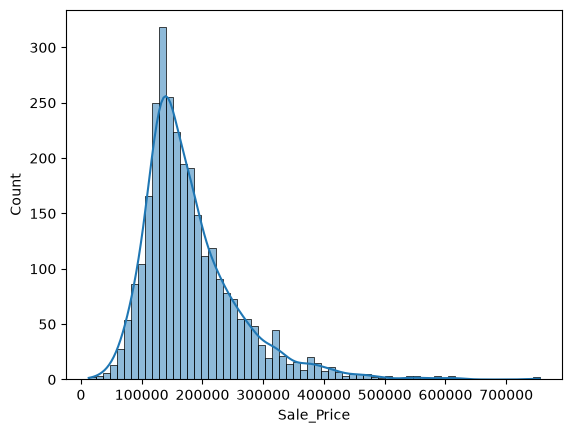

In [939]:
sns.histplot(df["Sale_Price"], kde=True)

# Target Variable Analysis: `Sale_Price`

The histogram below illustrates the distribution of the target variable, `Sale_Price`.

### 📊 Distribution Shape — Skewness

The distribution of `Sale_Price` is **positively skewed (right-skewed)**. Most observations are concentrated in the lower-to-middle price ranges, while a long tail extends toward higher property prices.

### 💰 Dominant Price Range

The majority of observations are concentrated approximately within the **$100,000–$250,000** range, indicating that this is the most common price range in the dataset.

### ⚠️ Extreme Values

The distribution contains several observations above approximately **$600,000–$700,000**. These values are far from the main concentration of the data and may represent **potential outliers or luxury properties**.

> Note: High-priced properties are not automatically considered outliers, as they may represent legitimate observations.

### 🤖 Modeling Implications

The strong right skewness of `Sale_Price` indicates that the target variable is not normally distributed. High-priced properties may also have a larger influence on error-based regression metrics.

At this stage, **no transformation is applied to the target variable**. The original `Sale_Price` values are retained for further analysis and modeling.

### 📝 Conclusion

> `Sale_Price` exhibits a strong positive skewness with a long right tail and several extreme high-price observations. These characteristics should be considered during model development, while the target variable is currently kept in its original form.


In [940]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Percentage", ascending=False)
)

missing_summary

,Missing_Count,Missing_Percentage


In [941]:
print(f"Quantity duplicate: {df.duplicated().sum()}")
print(f"Quantity isnull: {df.isnull().sum().sum()}")

Quantity duplicate: 0
Quantity isnull: 0


In [942]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(f"Number of numerical features: {len(numerical_features)}")
print(pd.Series(numerical_features))

Number of numerical features: 35
0           Lot_Frontage
1               Lot_Area
2             Year_Built
3         Year_Remod_Add
4           Mas_Vnr_Area
5           BsmtFin_SF_1
6           BsmtFin_SF_2
7            Bsmt_Unf_SF
8          Total_Bsmt_SF
9           First_Flr_SF
10         Second_Flr_SF
11       Low_Qual_Fin_SF
12           Gr_Liv_Area
13        Bsmt_Full_Bath
14        Bsmt_Half_Bath
15             Full_Bath
16             Half_Bath
17         Bedroom_AbvGr
18         Kitchen_AbvGr
19         TotRms_AbvGrd
20            Fireplaces
21           Garage_Cars
22           Garage_Area
23          Wood_Deck_SF
24         Open_Porch_SF
25        Enclosed_Porch
26    Three_season_porch
27          Screen_Porch
28             Pool_Area
29              Misc_Val
30               Mo_Sold
31             Year_Sold
32            Sale_Price
33             Longitude
34              Latitude
dtype: str


In [943]:
categorical_features = df.select_dtypes(
    include='category'
).columns.tolist()

print(f"Number of categorical features: {len(categorical_features)}")
print(pd.Series(categorical_features))

Number of categorical features: 46
0        MS_SubClass
1          MS_Zoning
2             Street
3              Alley
4          Lot_Shape
5       Land_Contour
6          Utilities
7         Lot_Config
8         Land_Slope
9       Neighborhood
10       Condition_1
11       Condition_2
12         Bldg_Type
13       House_Style
14      Overall_Qual
15      Overall_Cond
16        Roof_Style
17         Roof_Matl
18      Exterior_1st
19      Exterior_2nd
20      Mas_Vnr_Type
21        Exter_Qual
22        Exter_Cond
23        Foundation
24         Bsmt_Qual
25         Bsmt_Cond
26     Bsmt_Exposure
27    BsmtFin_Type_1
28    BsmtFin_Type_2
29           Heating
30        Heating_QC
31       Central_Air
32        Electrical
33      Kitchen_Qual
34        Functional
35      Fireplace_Qu
36       Garage_Type
37     Garage_Finish
38       Garage_Qual
39       Garage_Cond
40       Paved_Drive
41           Pool_QC
42             Fence
43      Misc_Feature
44         Sale_Type
45    Sale_Condition

In [944]:
feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": df.dtypes.astype(str),
    "Unique_Values": df.nunique(),
})

feature_summary

,Feature,Data_Type,Unique_Values
MS_SubClass,MS_SubClass,category,16
MS_Zoning,MS_Zoning,category,7
Lot_Frontage,Lot_Frontage,int64,129
Lot_Area,Lot_Area,int64,1960
Street,Street,category,2
...,...,...,...
Sale_Type,Sale_Type,category,10
Sale_Condition,Sale_Condition,category,6
Sale_Price,Sale_Price,int64,1032
Longitude,Longitude,float64,2776


In [945]:
feature_summary["Data_Type"].value_counts()

Data_Type
category    46
int64       33
float64      2
Name: count, dtype: int64

In [946]:
numerical_summery = df[numerical_features]
numerical_summery

,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude
0,141,31770,1960,1960,112,2,0,441,1080,1656,...,0,0,0,0,0,5,2010,215000,-93.619754,42.054035
1,80,11622,1961,1961,0,6,144,270,882,896,...,0,0,120,0,0,6,2010,105000,-93.619756,42.053014
2,81,14267,1958,1958,108,1,0,406,1329,1329,...,0,0,0,0,12500,6,2010,172000,-93.619387,42.052659
3,93,11160,1968,1968,0,1,0,1045,2110,2110,...,0,0,0,0,0,4,2010,244000,-93.617320,42.051245
4,74,13830,1997,1998,0,3,0,137,928,928,...,0,0,0,0,0,3,2010,189900,-93.638933,42.060899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37,7937,1984,1984,0,3,0,184,1003,1003,...,0,0,0,0,0,3,2006,142500,-93.604776,41.988964
2926,0,8885,1983,1983,0,2,324,239,864,902,...,0,0,0,0,0,6,2006,131000,-93.602680,41.988314
2927,62,10441,1992,1992,0,3,0,575,912,970,...,0,0,0,0,700,7,2006,132000,-93.606847,41.986510
2928,77,10010,1974,1975,0,1,123,195,1389,1389,...,0,0,0,0,0,4,2006,170000,-93.600190,41.990921


In [947]:
categorical_summery = df[categorical_features]
categorical_summery

,MS_SubClass,MS_Zoning,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,...,Garage_Type,Garage_Finish,Garage_Qual,Garage_Cond,Paved_Drive,Pool_QC,Fence,Misc_Feature,Sale_Type,Sale_Condition
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Fin,Typical,Typical,Partial_Pavement,No_Pool,No_Fence,None,WD,Normal
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,No_Fence,Gar2,WD,Normal
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Fin,Typical,Typical,Paved,No_Pool,No_Fence,None,WD,Normal
4,Two_Story_1946_and_Newer,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,...,Attchd,Fin,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Split_or_Multilevel,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,CulDSac,Gtl,Mitchell,...,Detchd,Unf,Typical,Typical,Paved,No_Pool,Good_Privacy,None,WD,Normal
2926,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Low,AllPub,Inside,Mod,Mitchell,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
2927,Split_Foyer,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,Mitchell,...,No_Garage,No_Garage,No_Garage,No_Garage,Paved,No_Pool,Minimum_Privacy,Shed,WD,Normal
2928,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Mod,Mitchell,...,Attchd,RFn,Typical,Typical,Paved,No_Pool,No_Fence,None,WD,Normal


## Feature Visualization

To better understand the most important features, selected numerical and categorical variables are visualized and analyzed based on their distributions and relationships with `Sale_Price`.

### Numerical Features

The following numerical features are visualized:

* `Gr_Liv_Area`
* `Year_Built`
* `Year_Remod_Add`
* `Total_Bsmt_SF`
* `First_Flr_SF`
* `Second_Flr_SF`
* `Garage_Cars`
* `Garage_Area`
* `TotRms_AbvGrd`
* `Fireplaces`
* `Lot_Area`
* `Mas_Vnr_Area`

The plots are used to examine their **distributions, potential skewness, and relationships with `Sale_Price`**.

### Categorical Features

The following categorical features are visualized:

* `Overall_Qual`
* `Neighborhood`
* `Kitchen_Qual`
* `Bsmt_Qual`
* `Garage_Finish`
* `Garage_Type`
* `Exter_Qual`
* `Heating_QC`

The plots are used to examine their **category distributions and differences in `Sale_Price` across categories**.

### Analysis Goal

The goal is to identify important patterns and relationships among the selected features before proceeding to **outlier analysis**.


## 📊 Categirical

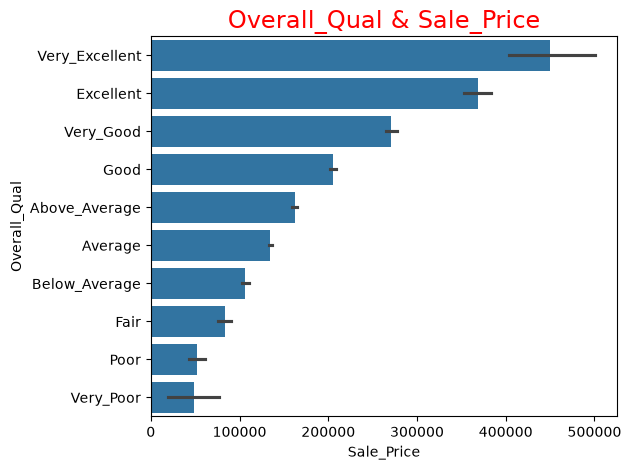

In [948]:
fig, ax = plt.subplots()

order_list = df.groupby('Overall_Qual')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    y='Overall_Qual',
    x='Sale_Price',
    order=order_list
)

ax.set_title('Overall_Qual & Sale_Price', size=17, color='red')
fig.tight_layout()
plt.show()


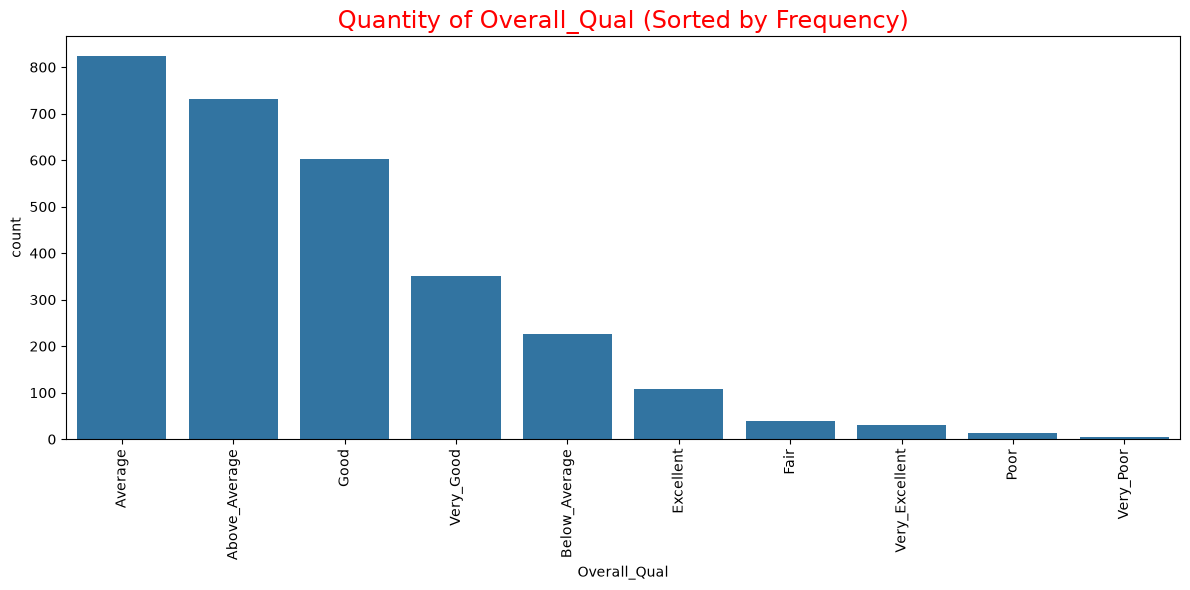

In [949]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Overall_Qual'].value_counts().index
sns.countplot(
    data=df,
    x='Overall_Qual',
    order=my_order
)

ax.set_title('Quantity of Overall_Qual (Sorted by Frequency)', size=17, color='red')
plt.xticks(rotation=90)
fig.tight_layout()
plt.show()


### Overall Quality Analysis

The `Overall_Qual` feature represents the overall quality of the houses, ranging from **Very Excellent** to **Very Poor**.

The count plot shows that the dataset is not evenly distributed across the quality categories, with **Average, Above Average, and Good** representing the most common categories.

The bar plot shows a clear difference in the average `Sale_Price` across quality levels. In general, houses with higher overall quality tend to have higher average sale prices, while lower-quality houses tend to have lower average sale prices.

Overall, `Overall_Qual` shows a strong relationship with `Sale_Price` and appears to be one of the most informative categorical features for the prediction task.


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'Northridge'),
  Text(1, 0, 'Stone_Brook'),
  Text(2, 0, 'Northridge_Heights'),
  Text(3, 0, 'Green_Hills'),
  Text(4, 0, 'Veenker'),
  Text(5, 0, 'Timberland'),
  Text(6, 0, 'Somerset'),
  Text(7, 0, 'Clear_Creek'),
  Text(8, 0, 'Crawford'),
  Text(9, 0, 'College_Creek'),
  Text(10, 0, 'Bloomington_Heights'),
  Text(11, 0, 'Greens'),
  Text(12, 0, 'Gilbert'),
  Text(13, 0, 'Northwest_Ames'),
  Text(14, 0, 'Sawyer_West'),
  Text(15, 0, 'Mitchell'),
  Text(16, 0, 'North_Ames'),
  Text(17, 0, 'Blueste'),
  Text(18, 0, 'Northpark_Villa'),
  Text(19, 0, 'Landmark'),
  Text(20, 0, 'Sawyer'),
  Text(21, 0, 'South_and_West_of_Iowa_State_University'),
  Text(22, 0, 'Edwards'),
  Text(23, 0, 'Brookside'),
  Text(24, 0, 'Old_Town'),
  Text(25, 0, 'Briardale'),
  Text(26, 0, 'Iowa_DOT_and_Rail_Road'),
  Text(27, 0, 'Meadow_Vill

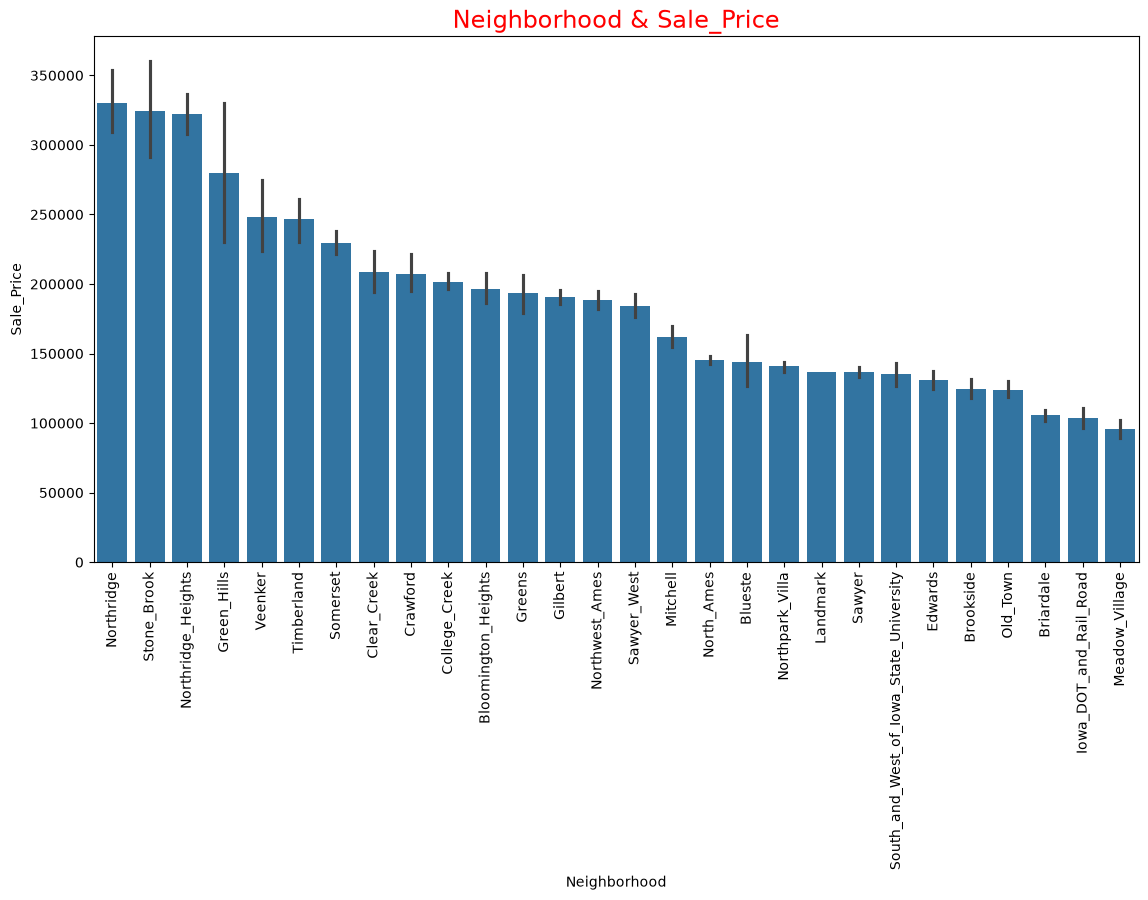

In [950]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Neighborhood')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Neighborhood',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Neighborhood & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'North_Ames'),
  Text(1, 0, 'College_Creek'),
  Text(2, 0, 'Old_Town'),
  Text(3, 0, 'Edwards'),
  Text(4, 0, 'Somerset'),
  Text(5, 0, 'Northridge_Heights'),
  Text(6, 0, 'Gilbert'),
  Text(7, 0, 'Sawyer'),
  Text(8, 0, 'Northwest_Ames'),
  Text(9, 0, 'Sawyer_West'),
  Text(10, 0, 'Mitchell'),
  Text(11, 0, 'Brookside'),
  Text(12, 0, 'Crawford'),
  Text(13, 0, 'Iowa_DOT_and_Rail_Road'),
  Text(14, 0, 'Timberland'),
  Text(15, 0, 'Northridge'),
  Text(16, 0, 'Stone_Brook'),
  Text(17, 0, 'South_and_West_of_Iowa_State_University'),
  Text(18, 0, 'Clear_Creek'),
  Text(19, 0, 'Meadow_Village'),
  Text(20, 0, 'Briardale'),
  Text(21, 0, 'Bloomington_Heights'),
  Text(22, 0, 'Veenker'),
  Text(23, 0, 'Northpark_Villa'),
  Text(24, 0, 'Blueste'),
  Text(25, 0, 'Greens'),
  Text(26, 0, 'Green_Hills'),
  Text(27, 0, 'Landm

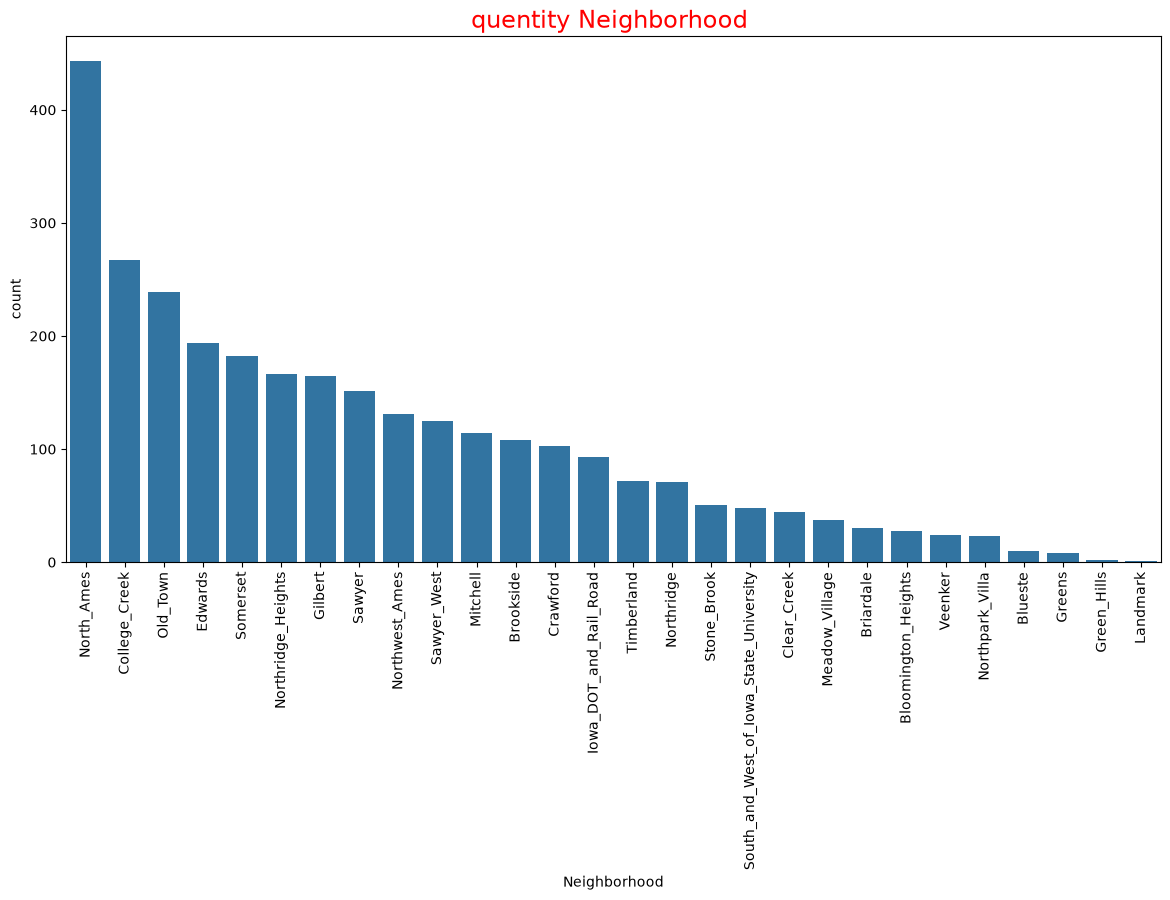

In [951]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Neighborhood'].value_counts().index

sns.countplot(
    data=df,
    x='Neighborhood',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Neighborhood ', size=17, color='red')
plt.xticks(rotation=90)


### Neighborhood Analysis

The `Neighborhood` feature shows substantial differences in average `Sale_Price` across different neighborhoods.

The bar plot ranks the neighborhoods according to their average sale price. **Northridge, Stone_Brook, Northridge_Heights, and Green_Hills** are among the neighborhoods with the highest average sale prices, while **Meadow_Village, Iowa_DOT_and_Rail_Road, Briardale, and Old_Town** are among the lower-priced neighborhoods.

The count plot also shows that the number of houses varies considerably across neighborhoods, indicating an uneven distribution of observations.

Overall, `Neighborhood` appears to be an important categorical feature because the average sale price differs substantially between neighborhoods.


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Typical'),
  Text(3, 0, 'Poor'),
  Text(4, 0, 'Fair')])

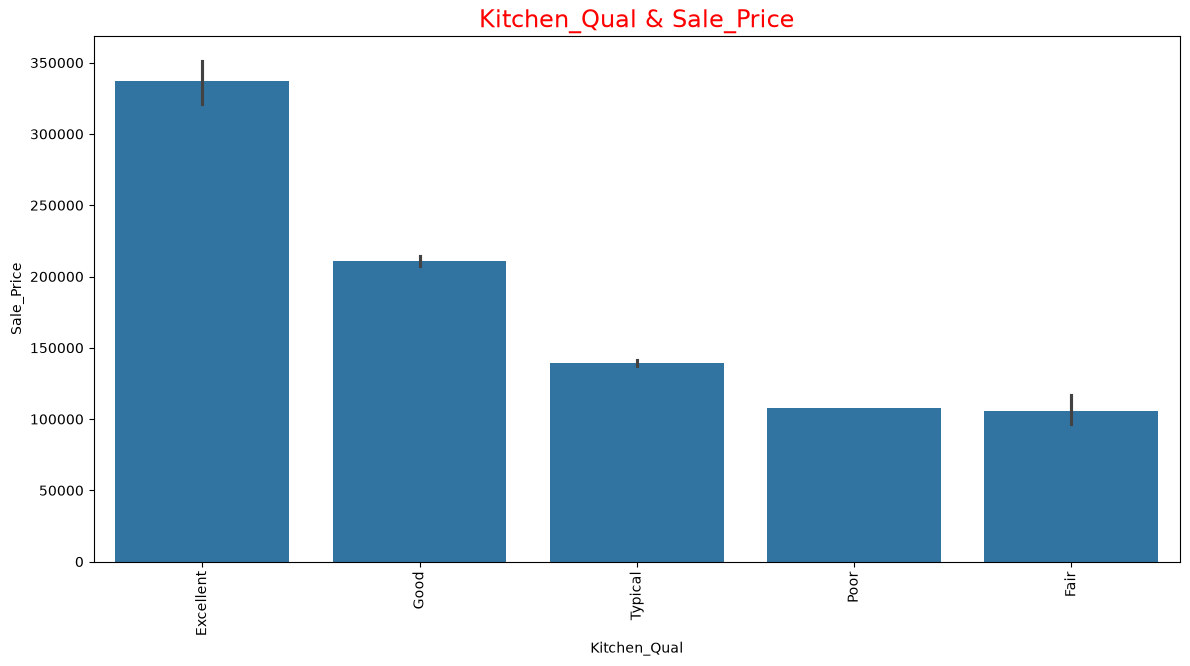

In [952]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Kitchen_Qual')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Kitchen_Qual',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Kitchen_Qual & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Typical'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Excellent'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'Poor')])

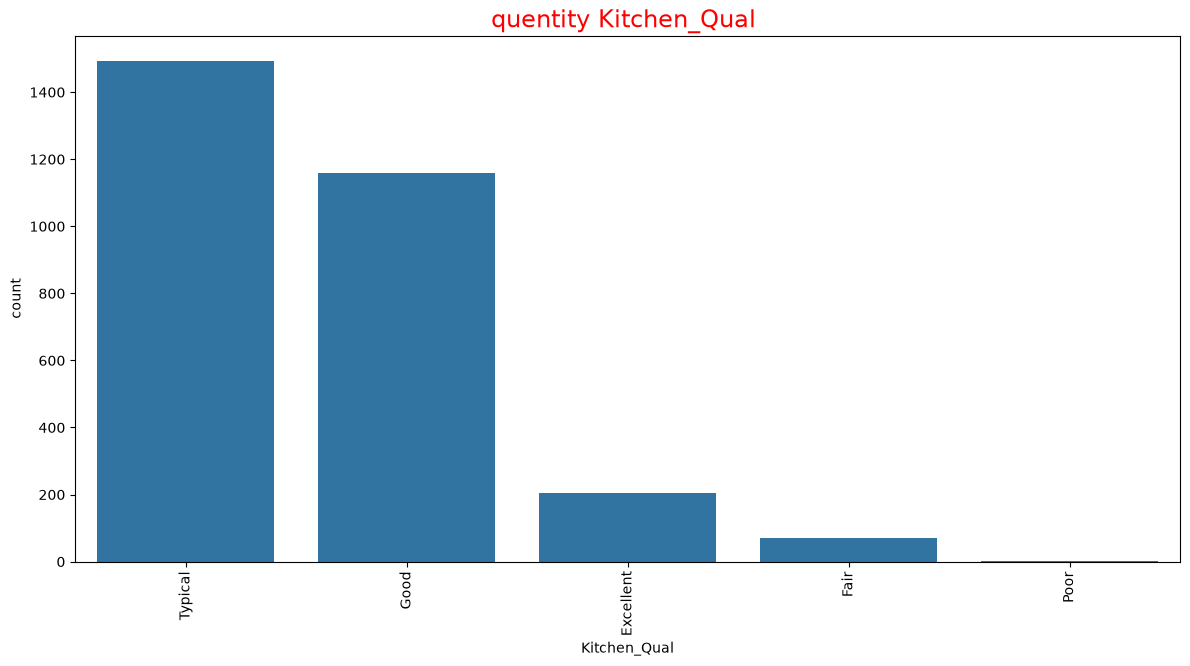

In [953]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Kitchen_Qual'].value_counts().index

sns.countplot(
    data=df,
    x='Kitchen_Qual',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Kitchen_Qual ', size=17, color='red')
plt.xticks(rotation=90)


### Kitchen Quality Analysis

The `Kitchen_Qual` feature represents the quality of the kitchen, ranging from **Excellent** to **Poor**.

The count plot shows that most houses are concentrated in the **Typical** and **Good** categories, while the other categories occur less frequently.

The bar plot shows differences in the average `Sale_Price` across kitchen quality levels. In general, higher kitchen quality is associated with higher average sale prices, while lower-quality kitchens tend to have lower average sale prices.

Overall, `Kitchen_Qual` appears to be an informative categorical feature for predicting `Sale_Price`.


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Typical'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'No_Basement'),
  Text(5, 0, 'Poor')])

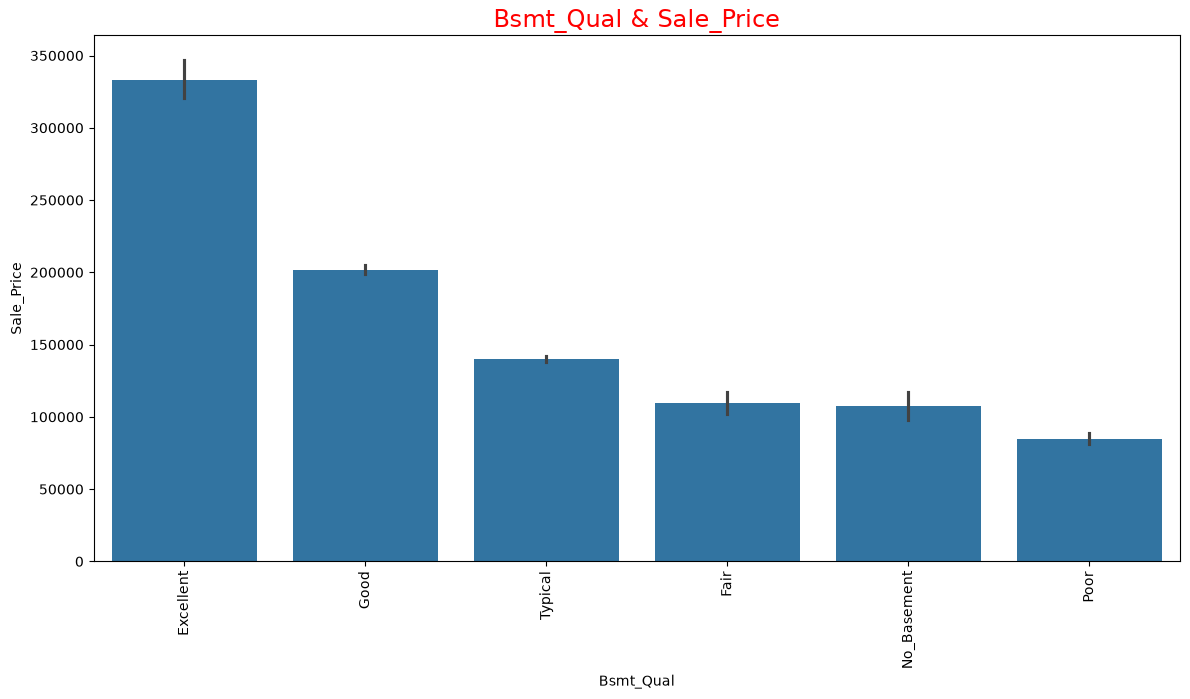

In [954]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Bsmt_Qual')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Bsmt_Qual',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Bsmt_Qual & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Typical'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Excellent'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'No_Basement'),
  Text(5, 0, 'Poor')])

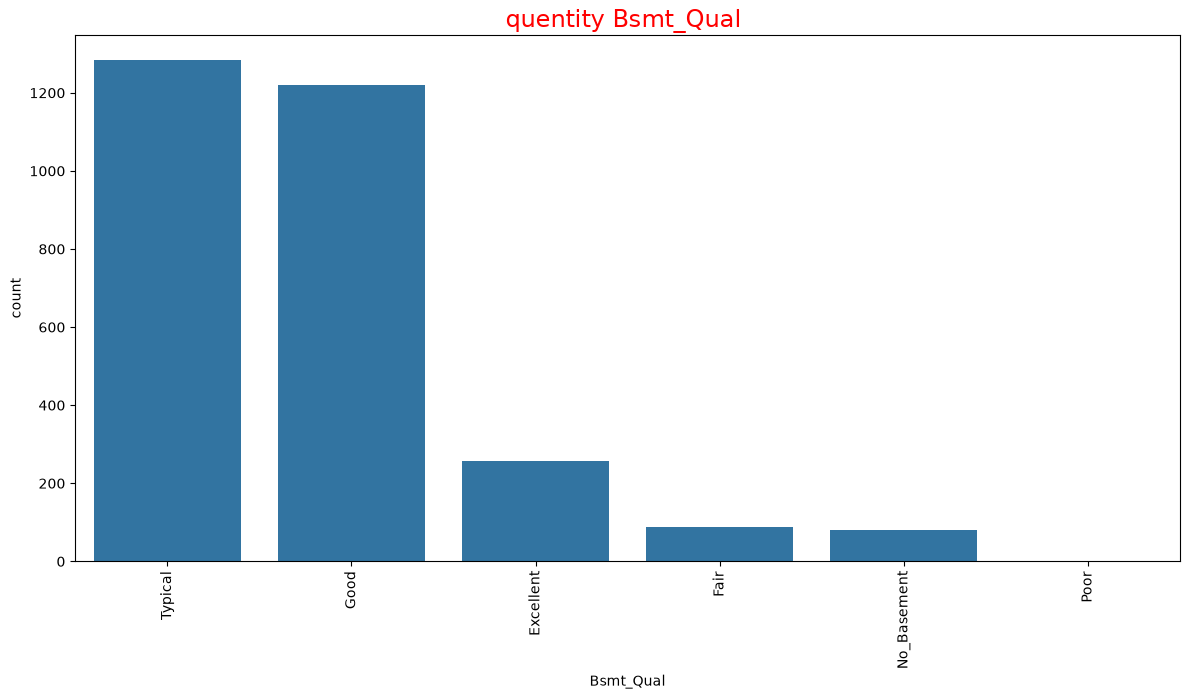

In [955]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Bsmt_Qual'].value_counts().index

sns.countplot(
    data=df,
    x='Bsmt_Qual',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Bsmt_Qual ', size=17, color='red')
plt.xticks(rotation=90)


### Basement Quality Analysis

The `Bsmt_Qual` feature represents the quality of the basement, ranging from **Excellent** to **Poor**, with a separate category for houses without a basement.

The count plot shows that the observations are unevenly distributed across the basement quality categories, with some categories occurring much more frequently than others.

The bar plot shows noticeable differences in average `Sale_Price` between the basement quality categories. Overall, higher basement quality is associated with higher average sale prices, while lower-quality basements and houses without a basement tend to have lower average sale prices.

These differences indicate that `Bsmt_Qual` provides useful information for predicting `Sale_Price`.


([0, 1, 2, 3],
 [Text(0, 0, 'Fin'),
  Text(1, 0, 'RFn'),
  Text(2, 0, 'Unf'),
  Text(3, 0, 'No_Garage')])

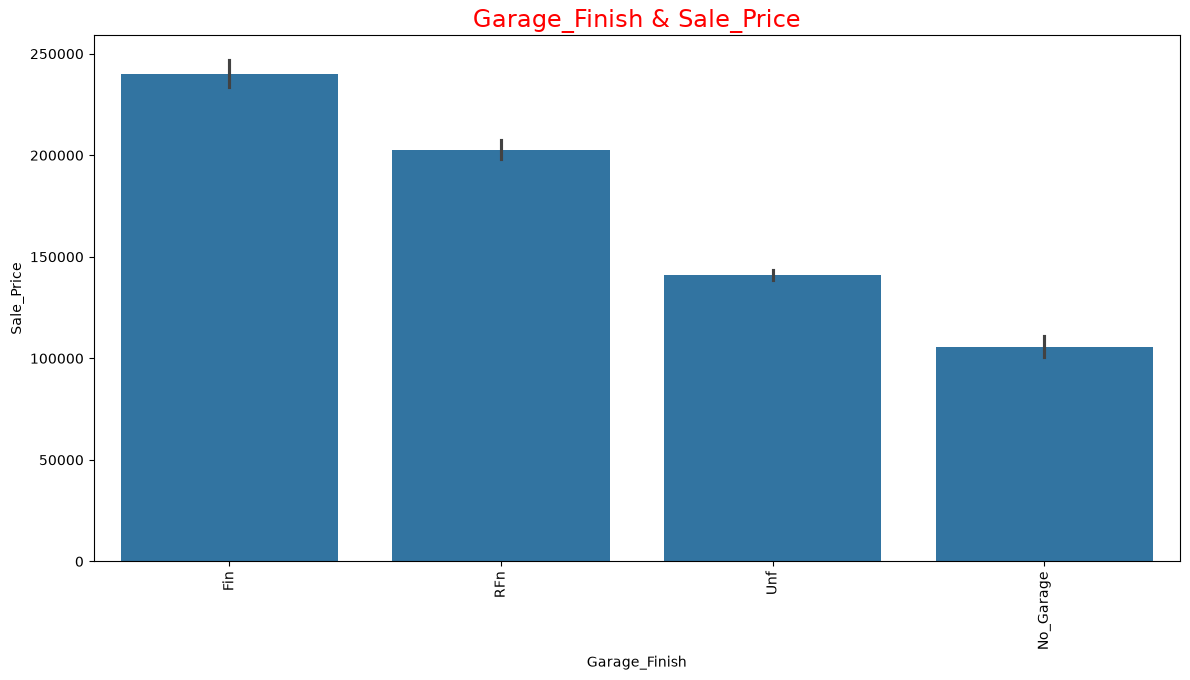

In [956]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Garage_Finish')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Garage_Finish',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Garage_Finish & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3],
 [Text(0, 0, 'Unf'),
  Text(1, 0, 'RFn'),
  Text(2, 0, 'Fin'),
  Text(3, 0, 'No_Garage')])

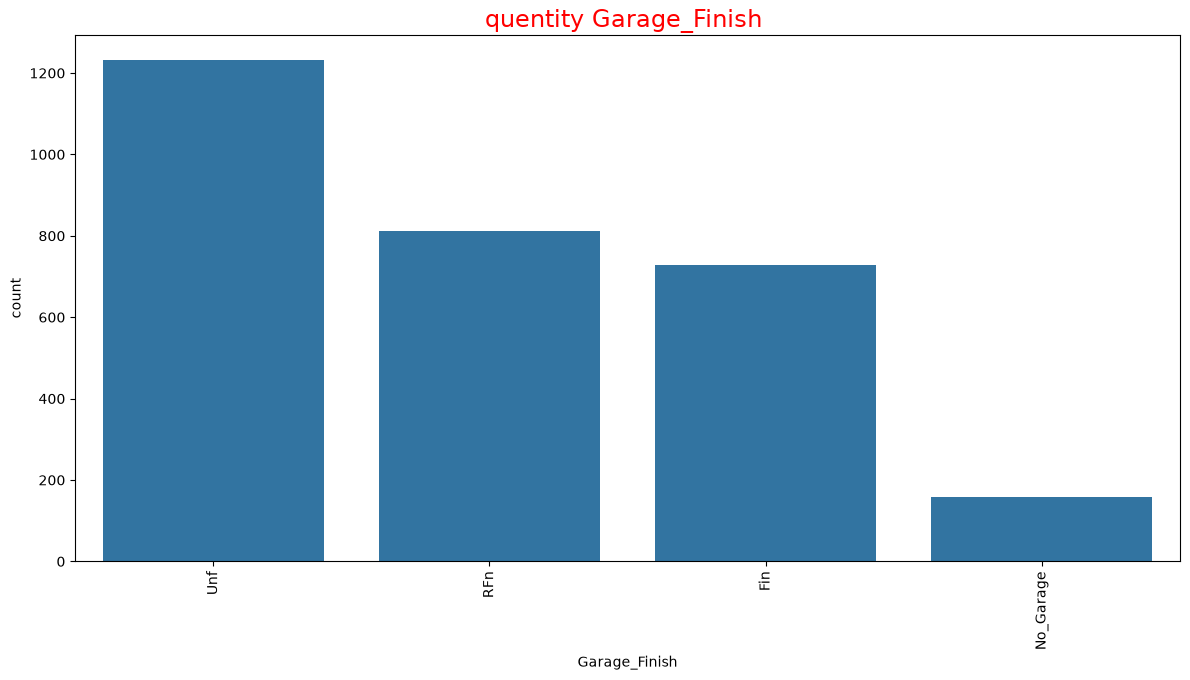

In [957]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Garage_Finish'].value_counts().index

sns.countplot(
    data=df,
    x='Garage_Finish',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Garage_Finish ', size=17, color='red')
plt.xticks(rotation=90)


### Garage Finish Analysis

The `Garage_Finish` feature represents the level of interior finish of the garage, including **Finished**, **Rough Finished**, and **Unfinished**, along with a category for houses without a garage.

The count plot shows that the garage finish categories are not evenly distributed, with some categories occurring more frequently than others.

The bar plot shows differences in average `Sale_Price` between the garage finish categories. Houses with more finished garages generally have higher average sale prices, while houses with unfinished or no garages tend to have lower average sale prices.

Overall, `Garage_Finish` appears to provide useful information for predicting `Sale_Price`.


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'BuiltIn'),
  Text(1, 0, 'Attchd'),
  Text(2, 0, 'More_Than_Two_Types'),
  Text(3, 0, 'Basment'),
  Text(4, 0, 'Detchd'),
  Text(5, 0, 'CarPort'),
  Text(6, 0, 'No_Garage')])

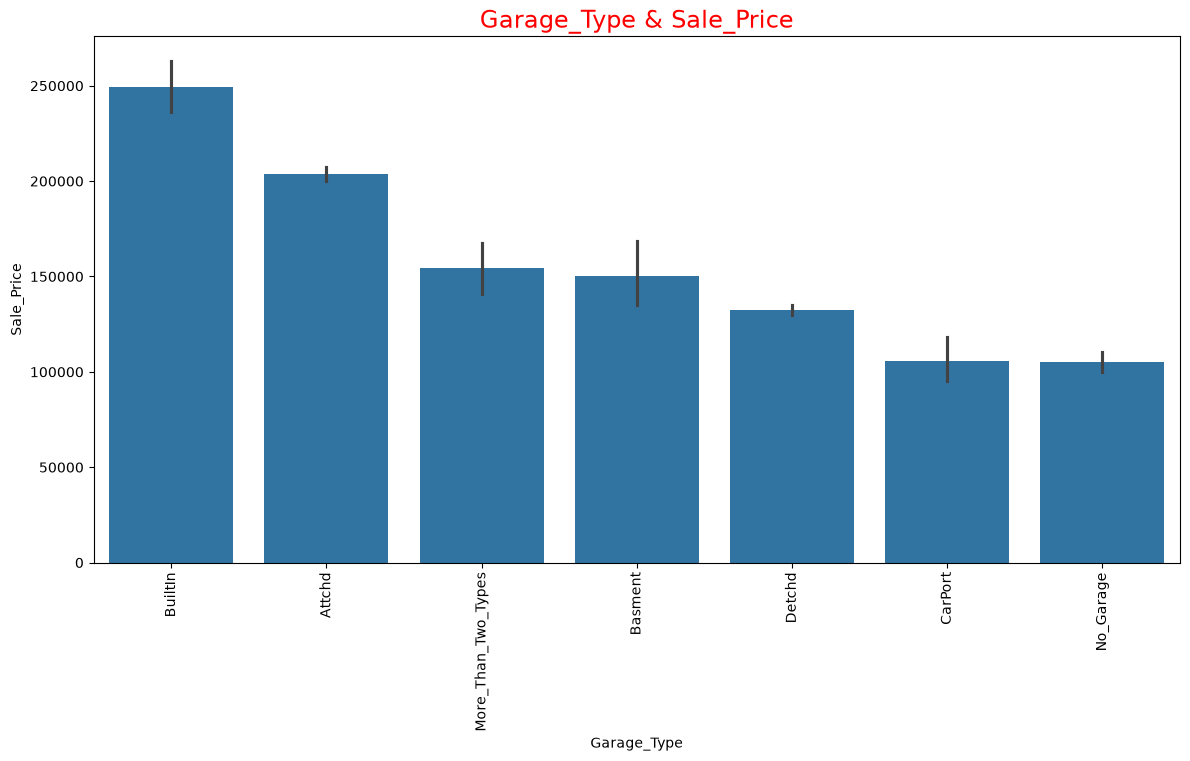

In [958]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Garage_Type')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Garage_Type',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Garage_Type & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Attchd'),
  Text(1, 0, 'Detchd'),
  Text(2, 0, 'BuiltIn'),
  Text(3, 0, 'No_Garage'),
  Text(4, 0, 'Basment'),
  Text(5, 0, 'More_Than_Two_Types'),
  Text(6, 0, 'CarPort')])

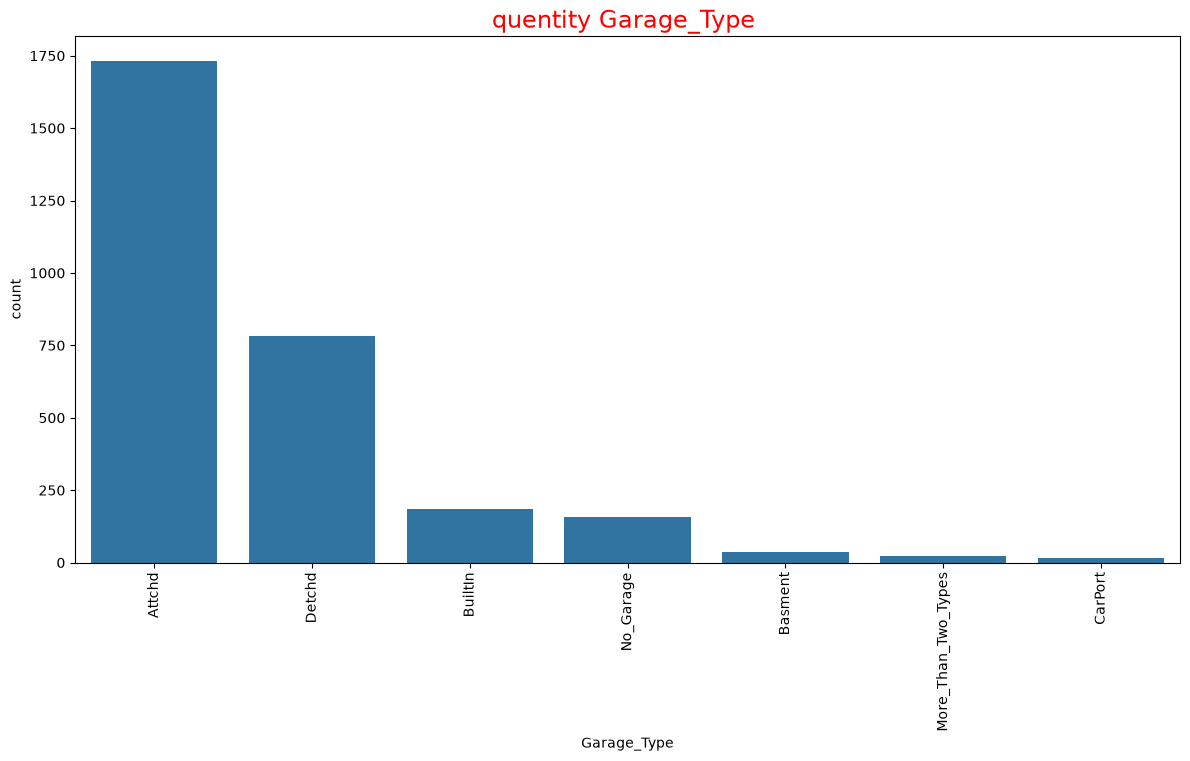

In [959]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Garage_Type'].value_counts().index

sns.countplot(
    data=df,
    x='Garage_Type',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Garage_Type ', size=17, color='red')
plt.xticks(rotation=90)


### Garage Type Analysis

The `Garage_Type` feature represents the type or location of the garage, including different garage configurations as well as houses without a garage.

The count plot shows that some garage types are much more common than others, resulting in an uneven distribution across categories.

The bar plot shows noticeable differences in average `Sale_Price` between garage types. This indicates that the type and presence of a garage are associated with differences in house sale prices.

Overall, `Garage_Type` appears to be a useful categorical feature for predicting `Sale_Price`.


([0, 1, 2, 3],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Typical'),
  Text(3, 0, 'Fair')])

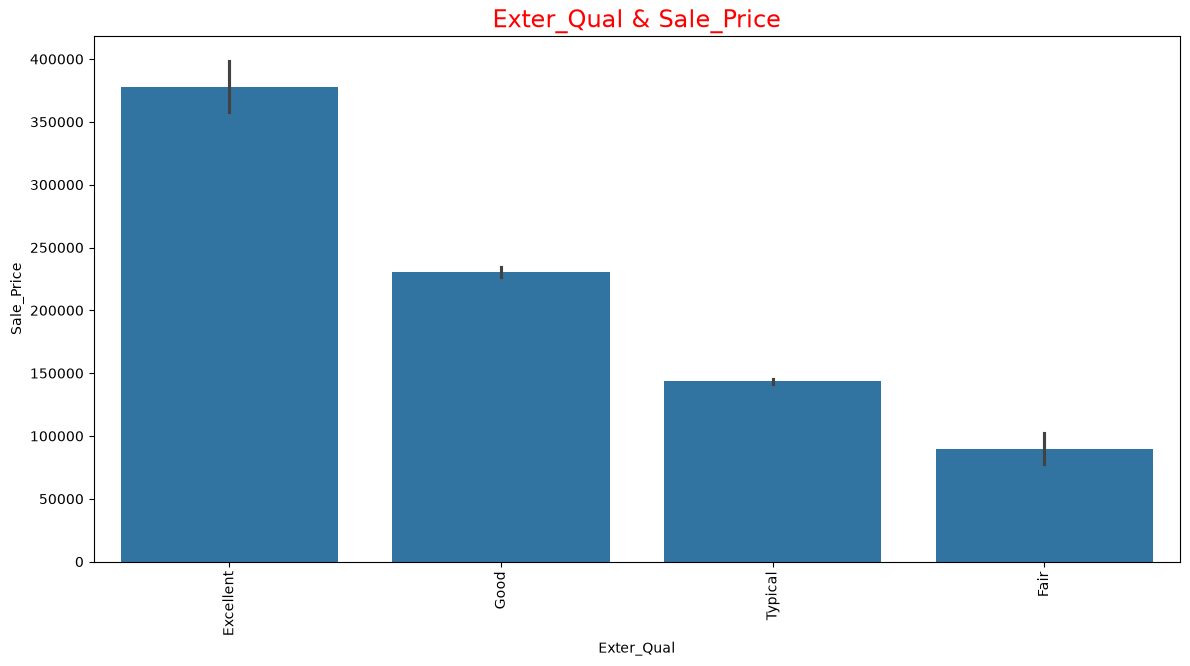

In [960]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Exter_Qual')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Exter_Qual',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Exter_Qual & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3],
 [Text(0, 0, 'Typical'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Excellent'),
  Text(3, 0, 'Fair')])

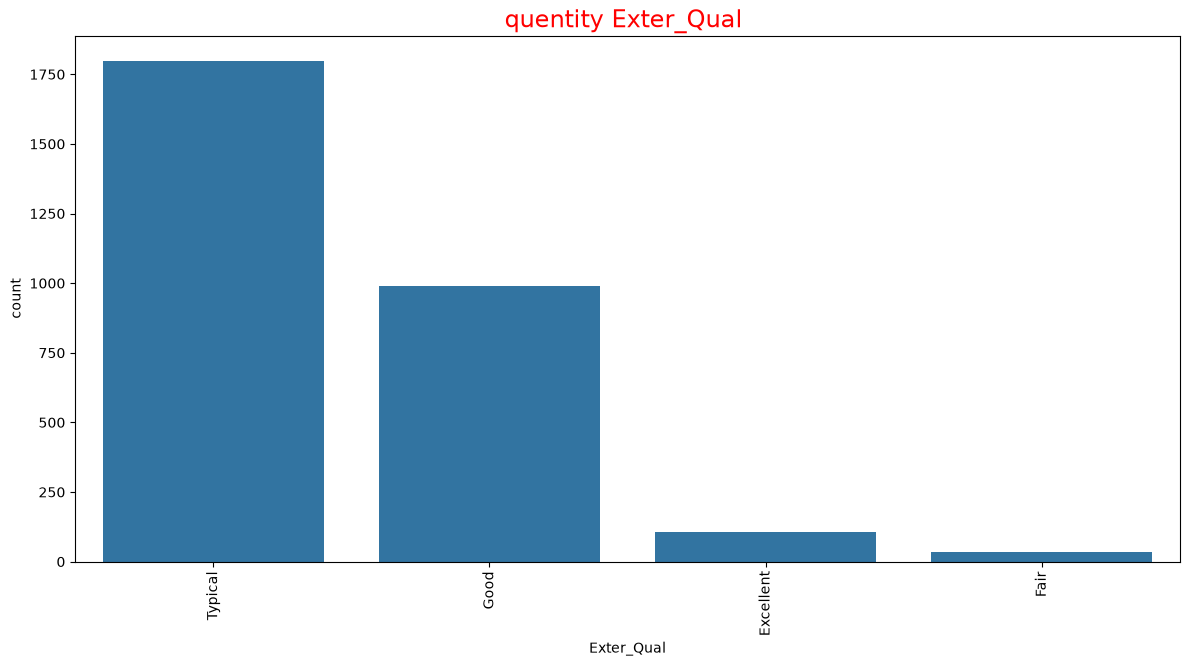

In [961]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Exter_Qual'].value_counts().index

sns.countplot(
    data=df,
    x='Exter_Qual',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Exter_Qual ', size=17, color='red')
plt.xticks(rotation=90)


### Exterior Quality Analysis

The `Exter_Qual` feature represents the quality of the house's exterior materials, ranging from **Excellent** to **Poor**.

The count plot shows that the observations are concentrated in some quality categories more than others, indicating an uneven distribution.

The bar plot shows clear differences in average `Sale_Price` across exterior quality levels. In general, houses with higher exterior quality tend to have higher average sale prices, while lower-quality houses tend to have lower average sale prices.

Overall, `Exter_Qual` appears to be an informative categorical feature for predicting `Sale_Price`.


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Typical'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'Poor')])

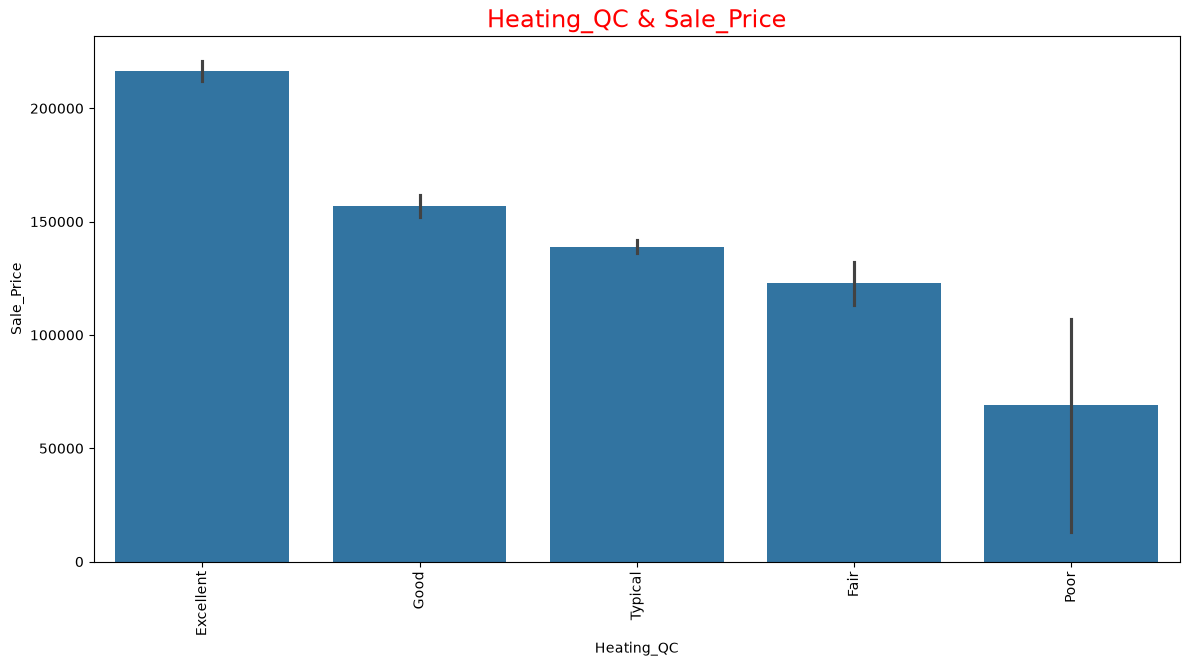

In [962]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Heating_QC')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Heating_QC',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Heating_QC & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Typical'),
  Text(2, 0, 'Good'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'Poor')])

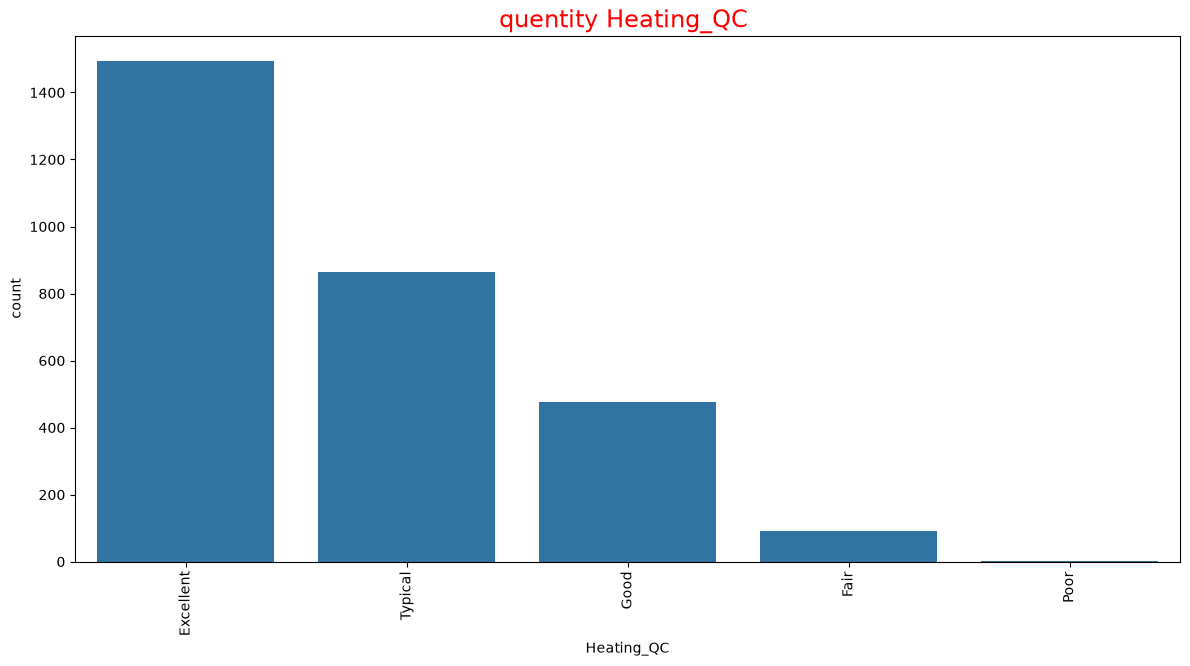

In [963]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Heating_QC'].value_counts().index

sns.countplot(
    data=df,
    x='Heating_QC',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Heating_QC ', size=17, color='red')
plt.xticks(rotation=90)


### Heating Quality Analysis

The `Heating_QC` feature represents the quality and condition of the house's heating system, ranging from **Excellent** to **Poor**.

The count plot shows that the observations are not evenly distributed across the heating quality categories, with some categories occurring more frequently than others.

The bar plot shows differences in average `Sale_Price` across heating quality levels. In general, houses with better heating quality tend to have higher average sale prices, while lower heating quality is associated with lower average sale prices.

Overall, `Heating_QC` provides useful information about differences in `Sale_Price` and can be considered an informative categorical feature for the prediction task.


## Categorical Features Analysis

The categorical feature analysis was performed using two complementary perspectives:

* **Count plots** were used to examine the distribution of observations across different categories.
* **Bar plots** were used to compare the average `Sale_Price` across categories.

The analysis shows that the categorical features are generally **not evenly distributed**. Some categories contain considerably more observations than others, which is particularly noticeable for features such as `Neighborhood`, `Kitchen_Qual`, `Garage_Type`, and `Heating_QC`.

The comparison of average `Sale_Price` across categories also reveals **substantial differences in house prices between several categorical groups**. Features related to house quality, such as `Overall_Qual`, `Kitchen_Qual`, `Bsmt_Qual`, and `Exter_Qual`, show noticeable differences in average sale prices across their quality levels. Similarly, `Neighborhood`, `Garage_Finish`, `Garage_Type`, and `Heating_QC` show variations in average `Sale_Price` between their respective categories.

Among the analyzed features, `Overall_Qual` shows one of the clearest relationships with `Sale_Price`, while `Neighborhood` also shows considerable variation in average house prices across different locations.

Overall, the categorical analysis indicates that these features contain **valuable information for explaining differences in house sale prices**. Therefore, categorical variables should be carefully considered during the preprocessing and modeling stages rather than being treated as insignificant features.

These findings provide a basis for the next stage of the analysis, where **potential outliers and unusual observations** will be investigated before building the regression models.


## 📊 Numerical

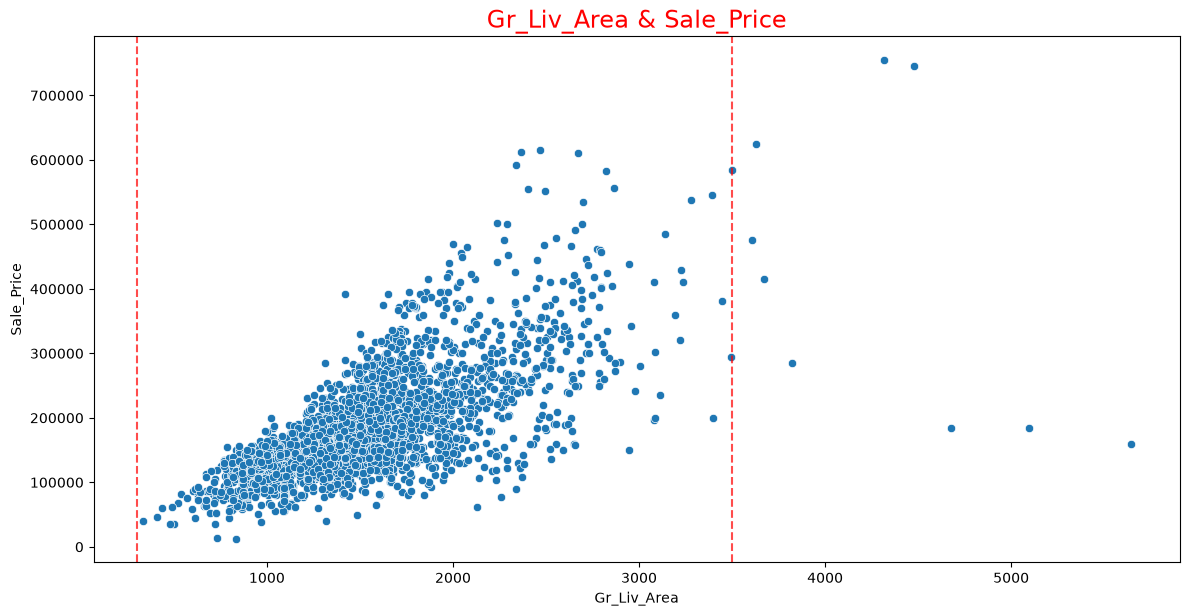

In [964]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Gr_Liv_Area', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Gr_Liv_Area & Sale_Price', size=17, color='red')

ax.axvline(x=300, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=3500, color='red', linestyle='--', alpha=0.7)

### Above Ground Living Area Analysis

The scatter plot shows a clear positive relationship between `Gr_Liv_Area` and `Sale_Price`. In general, houses with larger above-ground living areas tend to have higher sale prices.

Most observations are concentrated within a relatively common range of living areas, while a smaller number of houses have extremely small or very large living areas.

The plot also highlights observations outside the main range, particularly below approximately **300 square feet** and above approximately **3,500 square feet**. These observations should be examined further during the outlier analysis.

Overall, `Gr_Liv_Area` appears to be one of the most informative numerical features for predicting `Sale_Price`.


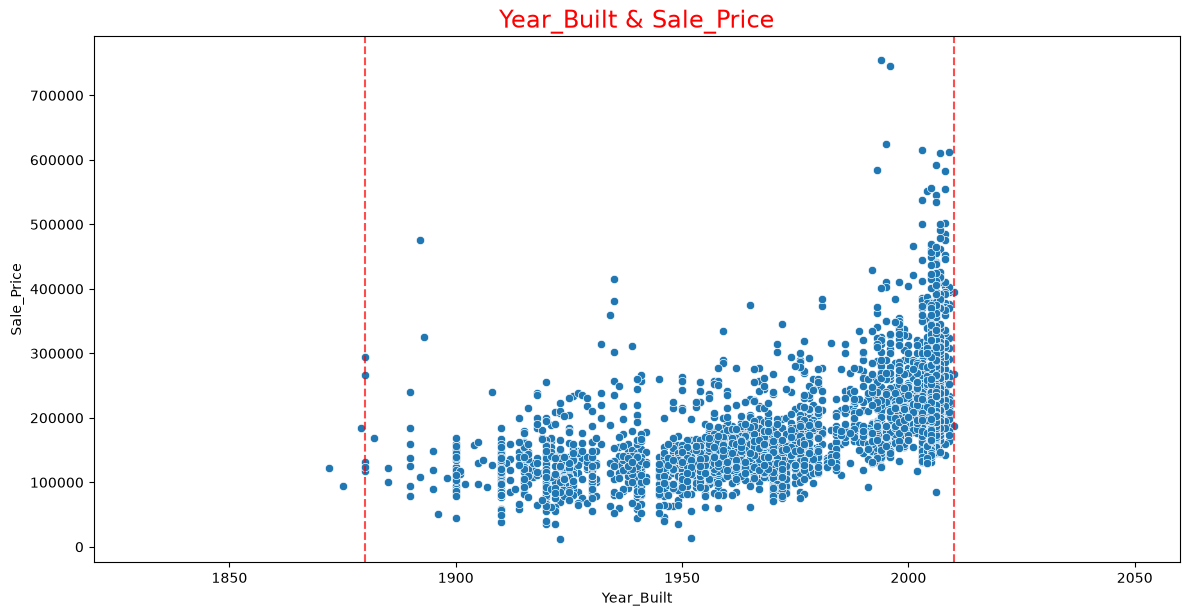

In [965]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Year_Built', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Year_Built & Sale_Price', size=17, color='red')
ax.set_xlim(1820, 2060)

ax.axvline(x=1880, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=2010, color='red', linestyle='--', alpha=0.7)

### Year Built Analysis

The scatter plot shows a general positive relationship between `Year_Built` and `Sale_Price`. Houses built more recently tend to have higher sale prices compared with many older houses.

The observations are distributed across a wide range of construction years, although most houses are concentrated within the more recent portion of the dataset.

The plot also identifies observations near the lower and upper boundaries of the observed construction years. These extreme values should be considered when investigating potential outliers and unusual observations.

Overall, `Year_Built` provides useful information about differences in `Sale_Price`, although the relationship is not perfectly linear.


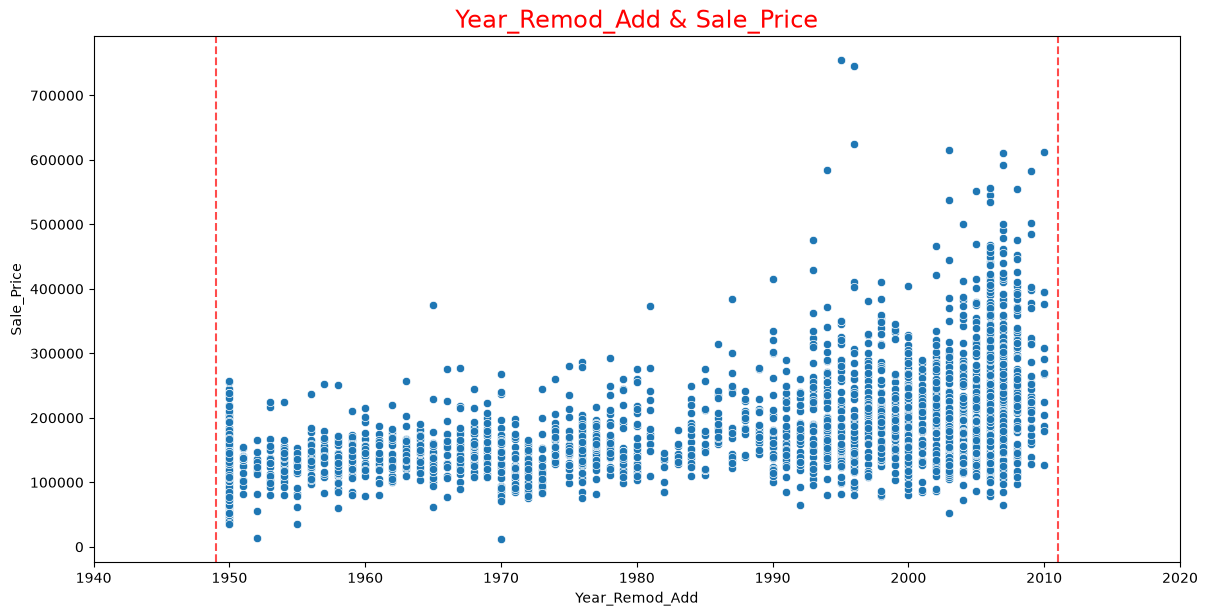

In [966]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Year_Remod_Add', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Year_Remod_Add & Sale_Price', size=17, color='red')
ax.set_xlim(1940, 2020)

ax.axvline(x=1949, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=2011, color='red', linestyle='--', alpha=0.7)

### Remodeling Year Analysis

The scatter plot shows a positive relationship between `Year_Remod_Add` and `Sale_Price`. Houses that were remodeled more recently generally tend to have higher sale prices.

The observations cover a broad range of remodeling years, with a greater concentration in the more recent years.

The relationship is not perfectly linear, indicating that the remodeling year alone does not fully explain differences in sale prices.

Overall, `Year_Remod_Add` appears to be a useful numerical feature, providing information about the recency of a property's remodeling.


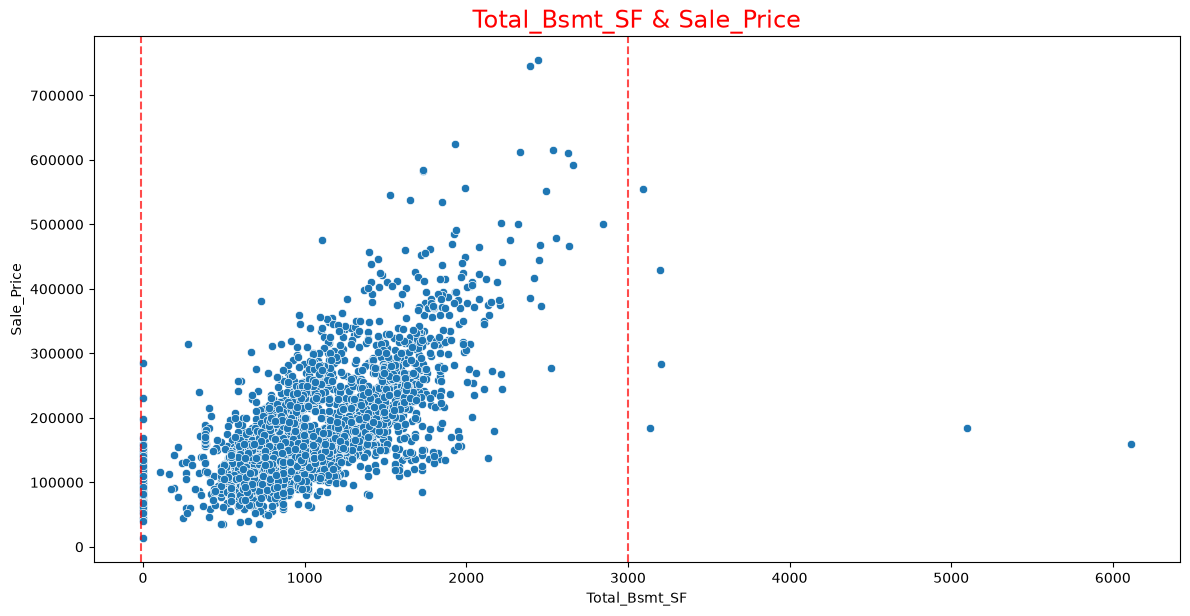

In [967]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Total_Bsmt_SF', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Total_Bsmt_SF & Sale_Price', size=17, color='red')

ax.axvline(x=-10, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=3000, color='red', linestyle='--', alpha=0.7)

### Total Basement Area Analysis

The scatter plot shows a generally positive relationship between `Total_Bsmt_SF` and `Sale_Price`. Houses with larger total basement areas tend to have higher sale prices.

A considerable number of observations are concentrated within the lower and middle ranges of basement area, while larger basement areas are less common.

The plot also highlights observations beyond the main range, particularly values approaching or exceeding **3,000 square feet**, which may require further investigation during outlier analysis.

Overall, `Total_Bsmt_SF` appears to provide useful information for predicting `Sale_Price`.


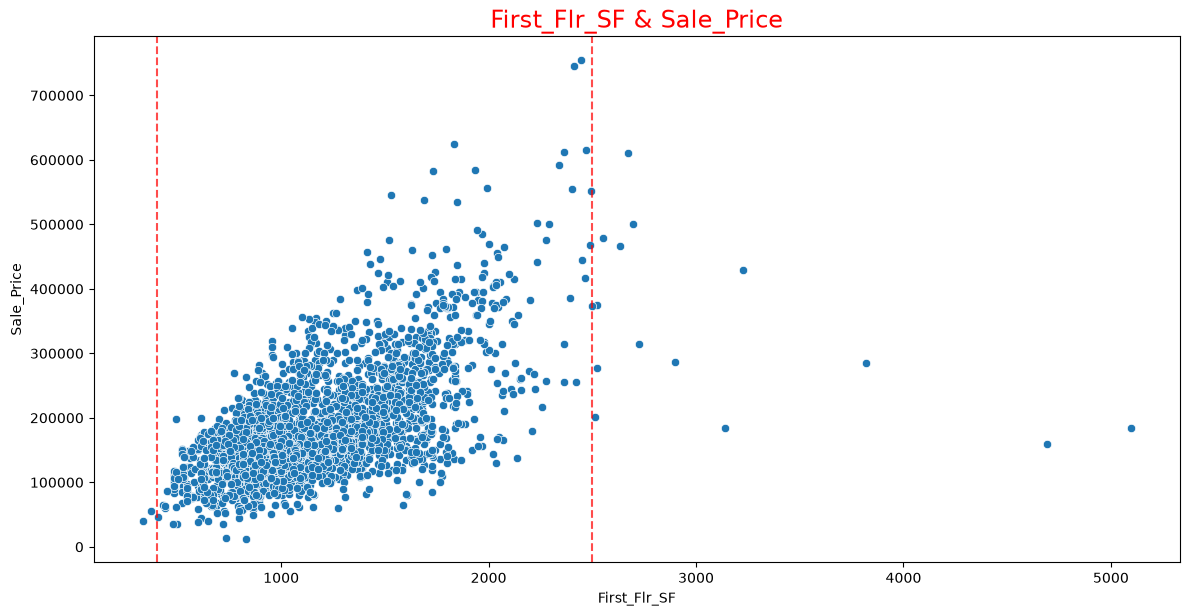

In [968]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='First_Flr_SF', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('First_Flr_SF & Sale_Price', size=17, color='red')

ax.axvline(x=400, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=2500, color='red', linestyle='--', alpha=0.7)

### First Floor Area Analysis

The scatter plot shows a positive relationship between `First_Flr_SF` and `Sale_Price`. Houses with larger first-floor areas generally tend to have higher sale prices.

Most observations are concentrated within the central range of first-floor area, while very small and very large values occur less frequently.

The values below approximately **400 square feet** and above approximately **2,500 square feet** represent observations outside the main range and should be examined further as potential unusual observations.

Overall, `First_Flr_SF` appears to be an informative numerical feature for predicting `Sale_Price`.


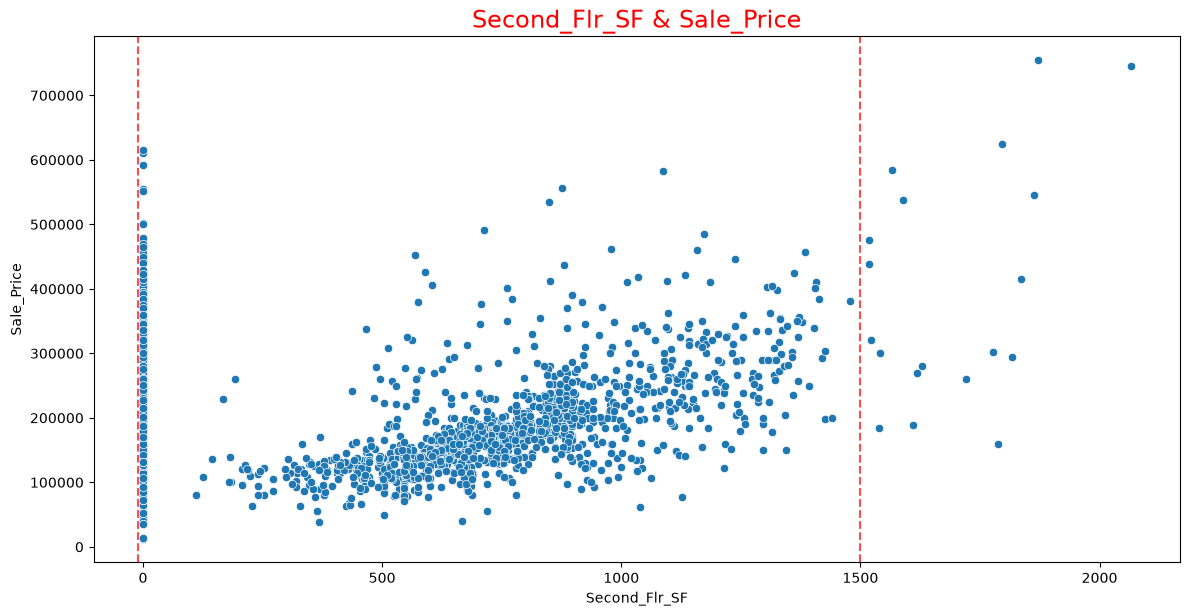

In [969]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Second_Flr_SF', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Second_Flr_SF & Sale_Price', size=17, color='red')

ax.axvline(x=-10, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=1500, color='red', linestyle='--', alpha=0.7)

### Second Floor Area Analysis

The scatter plot shows a positive relationship between `Second_Flr_SF` and `Sale_Price`, although the relationship is more variable than for some other area-related features.

A large number of observations have little or no second-floor area, while houses with larger second-floor areas generally tend to have higher sale prices.

The spread of sale prices becomes wider as the second-floor area increases, indicating that this feature alone does not completely explain differences in house prices.

Overall, `Second_Flr_SF` provides useful information for the regression model, but its relationship with `Sale_Price` appears less consistent than some of the other living-area features.


Text(0.5, 1.0, 'Garage_Cars & Sale_Price')

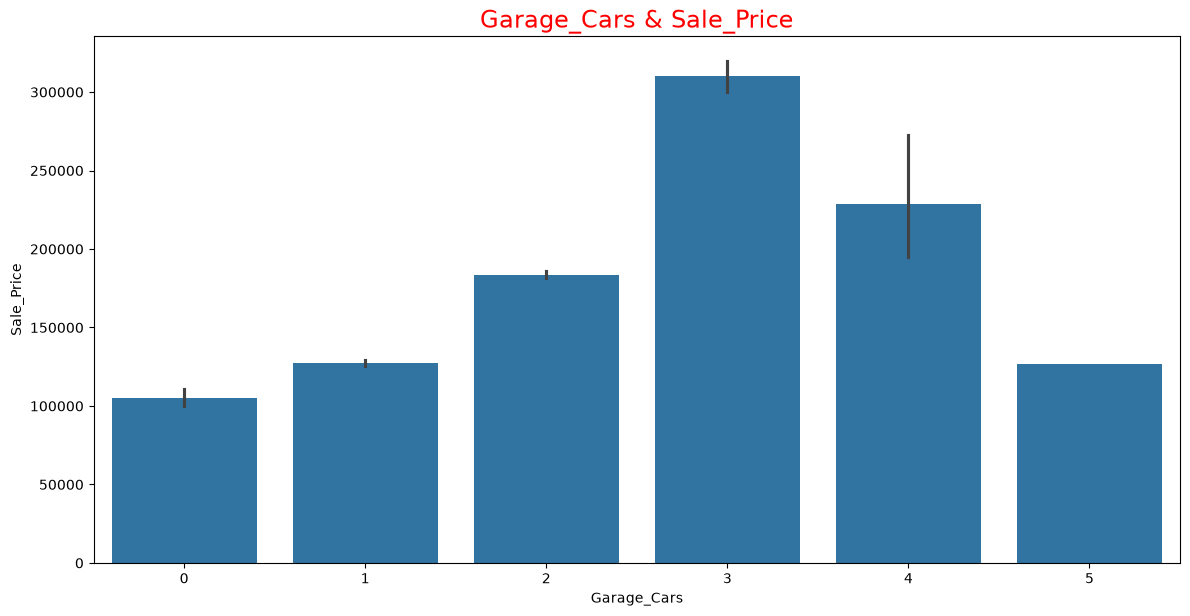

In [970]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='Garage_Cars', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Garage_Cars & Sale_Price', size=17, color='red')

### Garage Capacity Analysis

The bar plot compares the average `Sale_Price` across different values of `Garage_Cars`, representing the number of cars that can be accommodated in the garage.

The average sale price generally increases as garage capacity increases, indicating a noticeable difference in house prices across garage capacities.

However, the categories do not necessarily contain the same number of observations, so the average price of less frequent categories should be interpreted with caution.

Overall, `Garage_Cars` appears to be an informative feature for predicting `Sale_Price`, as garage capacity is associated with differences in average house prices.


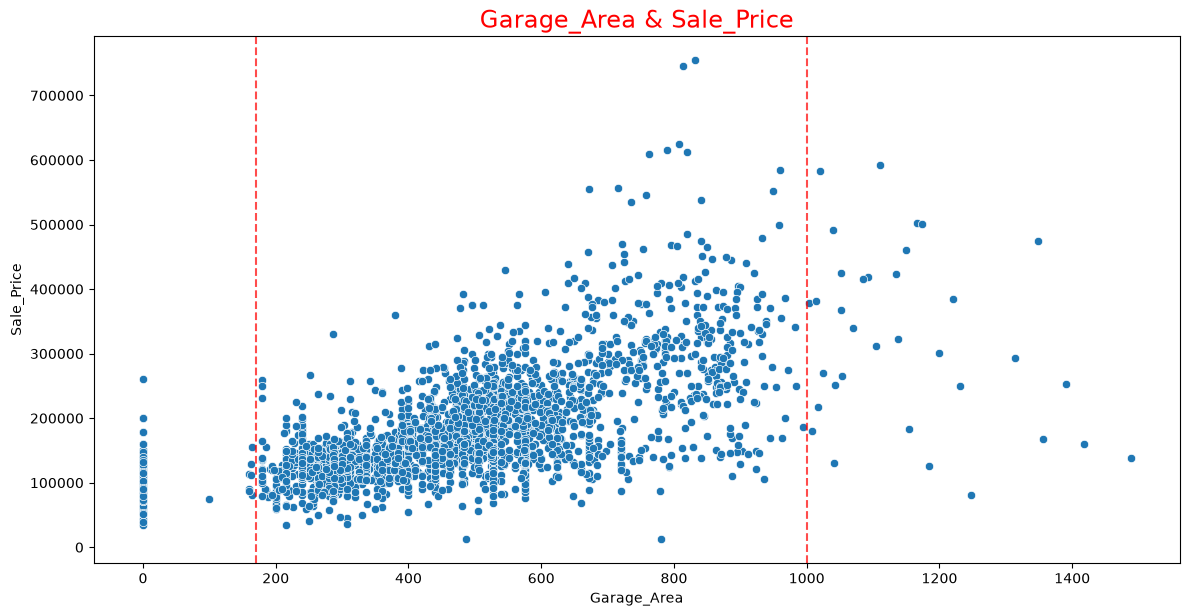

In [971]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Garage_Area', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Garage_Area & Sale_Price', size=17, color='red')
# ax.set_xlim(1940, 2020)

ax.axvline(x=170, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=1000, color='red', linestyle='--', alpha=0.7)

### Garage Area Analysis

The scatter plot shows a generally positive relationship between `Garage_Area` and `Sale_Price`. Houses with larger garage areas tend to have higher sale prices.

Many observations are concentrated within a relatively common range of garage areas, while very small and very large garage areas are less frequent.

The plot highlights values below approximately **170 square feet** and above approximately **1,000 square feet** as observations that may require additional investigation during outlier analysis.

Overall, `Garage_Area` provides useful information about differences in `Sale_Price`.


In [972]:
df['TotRms_AbvGrd'].value_counts()

TotRms_AbvGrd
6     844
7     649
5     586
8     347
4     203
9     143
10     80
11     32
3      26
12     16
13      1
2       1
15      1
14      1
Name: count, dtype: int64

Text(0.5, 1.0, 'TotRms_AbvGrd & Sale_Price')

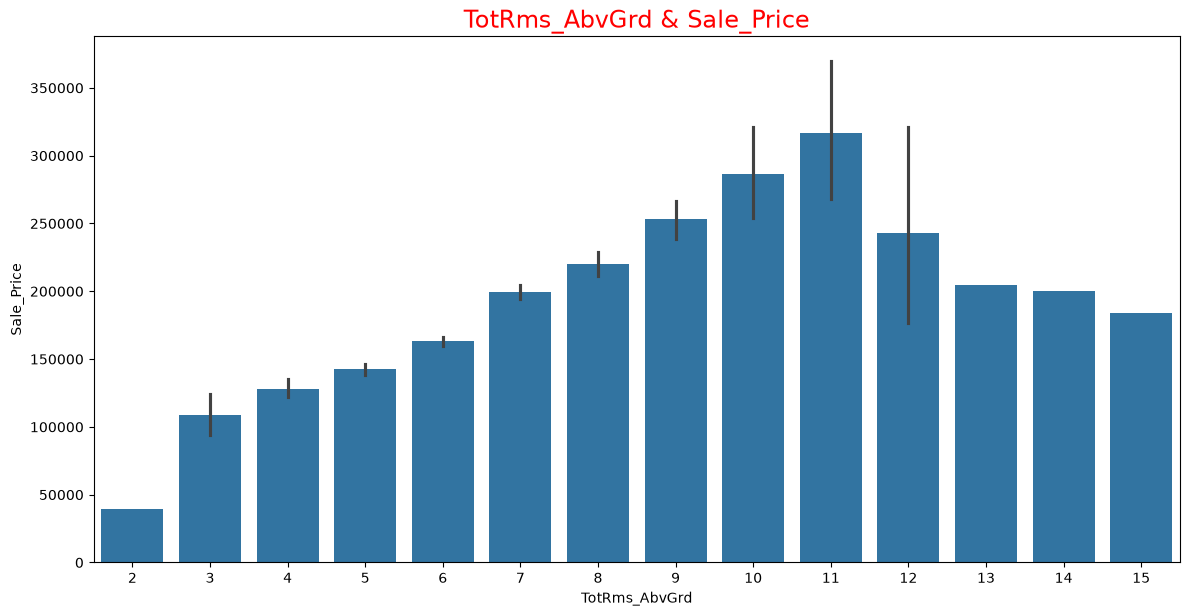

In [973]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='TotRms_AbvGrd', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('TotRms_AbvGrd & Sale_Price', size=17, color='red')

### Garage Area Analysis

The scatter plot shows a generally positive relationship between `Garage_Area` and `Sale_Price`. Houses with larger garage areas tend to have higher sale prices.

Many observations are concentrated within a relatively common range of garage areas, while very small and very large garage areas are less frequent.

The plot highlights values below approximately **170 square feet** and above approximately **1,000 square feet** as observations that may require additional investigation during outlier analysis.

Overall, `Garage_Area` provides useful information about differences in `Sale_Price`.


Text(0.5, 1.0, 'Fireplaces & Sale_Price')

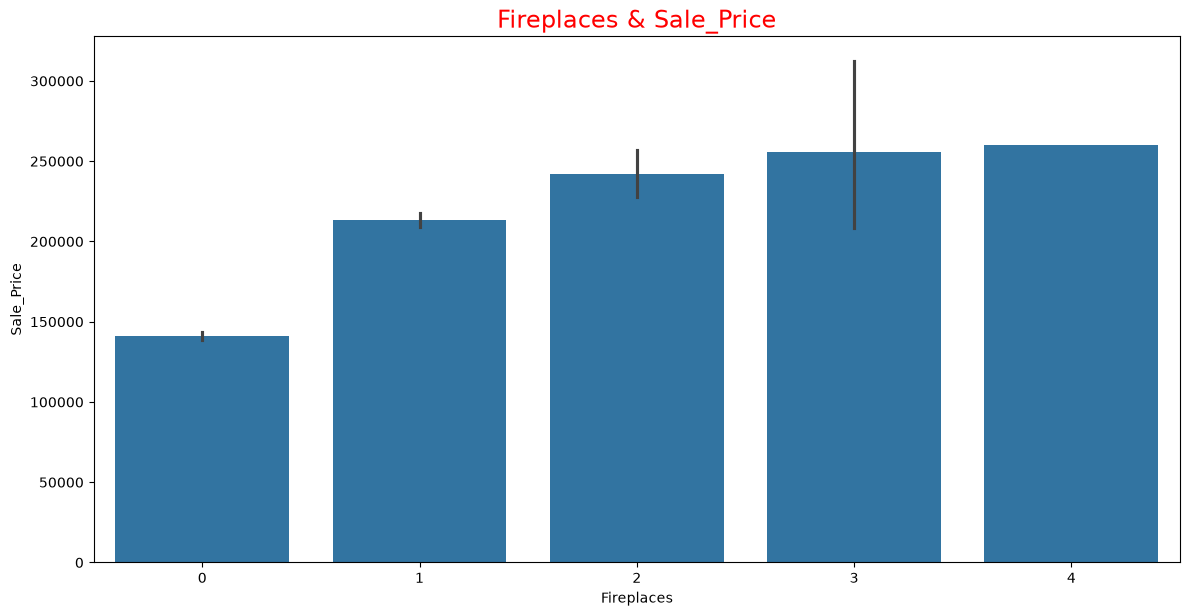

In [974]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='Fireplaces', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Fireplaces & Sale_Price', size=17, color='red')

### Fireplaces Analysis

The bar plot compares the average `Sale_Price` across different numbers of fireplaces.

The average sale price generally increases as the number of fireplaces increases, although the number of observations becomes smaller for higher fireplace counts.

This means that the averages for categories with very few observations should be interpreted carefully.

Overall, `Fireplaces` shows a noticeable relationship with `Sale_Price` and may provide useful information for the regression model.


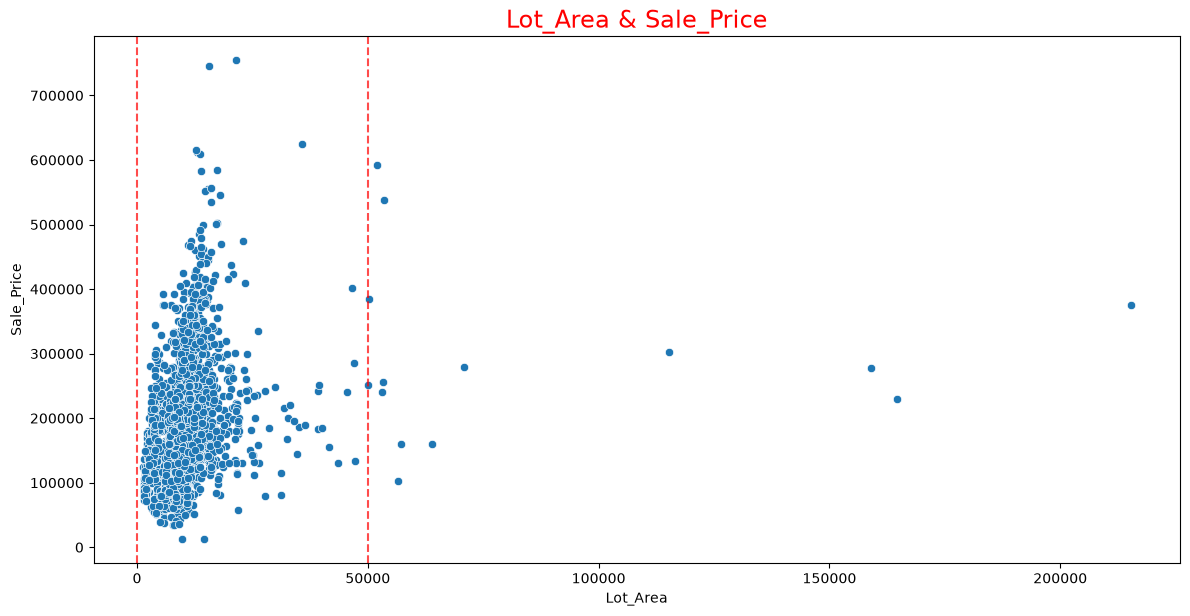

In [975]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Lot_Area', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Lot_Area & Sale_Price', size=17, color='red')

ax.axvline(x=-10, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=50000, color='red', linestyle='--', alpha=0.7)

### Lot Area Analysis

The scatter plot shows a positive relationship between `Lot_Area` and `Sale_Price`, although the relationship is weaker and more dispersed than for some of the main living-area features.

Most houses are concentrated within a relatively smaller range of lot sizes, while a limited number of properties have substantially larger lots.

The wider spread of sale prices suggests that lot size alone does not fully explain house prices. Other characteristics of the property also contribute to the observed price differences.

Overall, `Lot_Area` provides useful information for the regression task, while its relatively dispersed relationship should be considered during modeling.


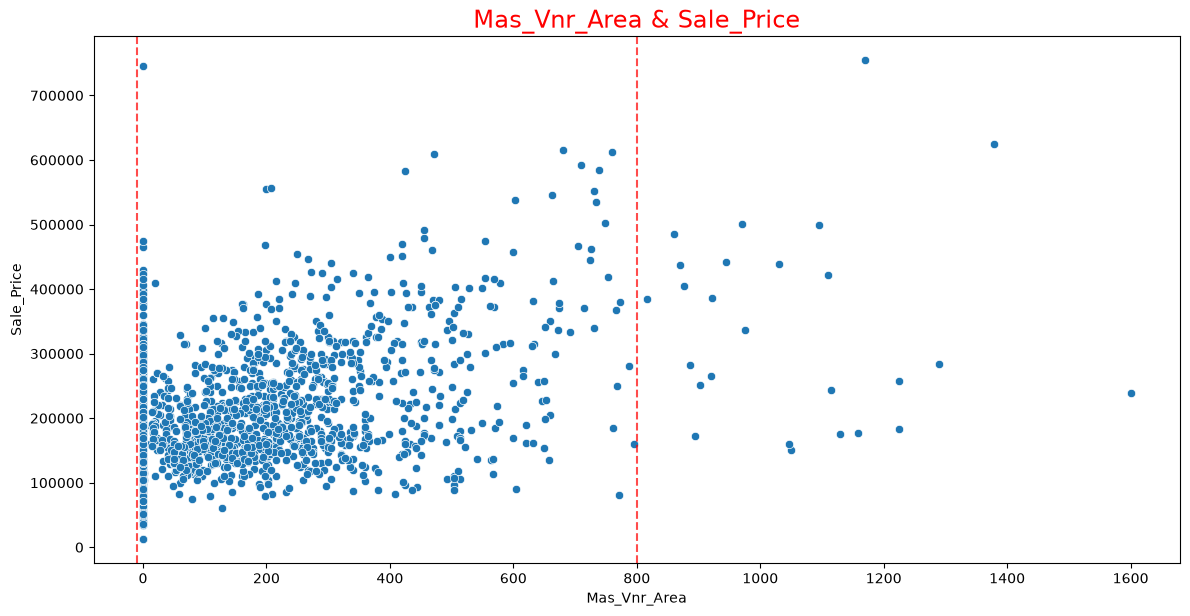

In [976]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Mas_Vnr_Area', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Mas_Vnr_Area & Sale_Price', size=17, color='red')

ax.axvline(x=-10, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=800, color='red', linestyle='--', alpha=0.7)

### Masonry Veneer Area Analysis

The scatter plot shows a generally positive relationship between `Mas_Vnr_Area` and `Sale_Price`, although the observations are relatively dispersed.

A considerable number of houses have little or no masonry veneer area, while a smaller number of houses have larger veneer areas.

The wider spread of sale prices at similar masonry veneer areas indicates that this feature alone does not strongly determine house price.

Overall, `Mas_Vnr_Area` may provide useful additional information for predicting `Sale_Price`, but its relationship appears weaker and more variable than features such as `Gr_Liv_Area` or `Total_Bsmt_SF`.


## Numerical Features Analysis

The numerical features were visualized to investigate their distributions and relationships with `Sale_Price`.

The scatter plots reveal that several property-size features, including `Gr_Liv_Area`, `Total_Bsmt_SF`, `First_Flr_SF`, and `Garage_Area`, generally show a positive relationship with `Sale_Price`. In other words, houses with larger areas tend to have higher sale prices, although the strength of these relationships varies across features.

The time-related features, `Year_Built` and `Year_Remod_Add`, also show a general tendency toward higher sale prices for newer properties and more recently remodeled houses. However, the observations are dispersed, indicating that these features alone cannot fully explain house prices.

The bar plots for `Garage_Cars`, `TotRms_AbvGrd`, and `Fireplaces` show differences in average `Sale_Price` across their respective values. These differences suggest that house capacity, layout, and additional features can provide useful information for predicting sale prices.

Some numerical features also contain observations that are considerably different from the main concentration of the data. These observations are especially noticeable in features such as `Gr_Liv_Area`, `Total_Bsmt_SF`, `First_Flr_SF`, `Garage_Area`, and `Lot_Area`. At this stage, these values are treated as potential outliers rather than errors and will be investigated separately.

Overall, the numerical feature analysis indicates that **property size, construction and remodeling year, and additional house characteristics contain valuable information about `Sale_Price`**. The observed relationships and potential extreme values provide a strong basis for the next stage of the analysis: **Outlier Analysis**.


In [977]:
def detect_outliers_iqr(df, columns):
    outlier_summary = []

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ]

        outlier_summary.append({
            'Feature': col,
            'Outlier_Count': len(outliers),
            'Outlier_Percentage': len(outliers) / len(df) * 100,
            'Mean': df[col].mean(),
            'Variance': df[col].var(),
            'Std': df[col].std(),
            'IQR': IQR,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })

    return pd.DataFrame(outlier_summary)

In [978]:
outlier_summary = detect_outliers_iqr(
    df,
    numerical_features
)

outlier_summary.sort_values(
    'Outlier_Count',
    ascending=False
)

,Feature,Outlier_Count,Outlier_Percentage,Mean,Variance,Std,IQR,Lower_Bound,Upper_Bound
25,Enclosed_Porch,459,15.665529,23.011604,4.113819e+03,64.139059,0.000000,0.000000,0.000000
6,BsmtFin_SF_2,351,11.979522,49.705461,2.860905e+04,169.142089,0.000000,0.000000,0.000000
27,Screen_Porch,256,8.737201,16.002048,3.145793e+03,56.087370,0.000000,0.000000,0.000000
4,Mas_Vnr_Area,203,6.928328,101.096928,3.191030e+04,178.634545,162.750000,-244.125000,406.875000
14,Bsmt_Half_Bath,175,5.972696,0.061092,6.011079e-02,0.245175,0.000000,0.000000,0.000000
24,Open_Porch_SF,159,5.426621,47.533447,4.554009e+03,67.483400,70.000000,-105.000000,175.000000
32,Sale_Price,137,4.675768,180796.060068,6.381884e+09,79886.692357,84000.000000,3500.000000,339500.000000
18,Kitchen_AbvGr,134,4.573379,1.044369,4.582864e-02,0.214076,0.000000,1.000000,1.000000
1,Lot_Area,127,4.334471,10147.921843,6.209468e+07,7880.017759,4115.000000,1267.750000,17727.750000
8,Total_Bsmt_SF,124,4.232082,1051.255631,1.944528e+05,440.968018,508.500000,30.250000,2064.250000


In [979]:
df['Enclosed_Porch'].value_counts().sort_index()

Enclosed_Porch
0       2471
16         1
18         1
19         1
20         2
        ... 
429        1
432        1
552        1
584        1
1012       1
Name: count, Length: 183, dtype: int64

In [980]:
enclosed_porch_outliers = df[
    df['Enclosed_Porch'] > 0
][['Enclosed_Porch', 'Sale_Price']].sort_values(
    'Enclosed_Porch',
    ascending=False
)

enclosed_porch_outliers

,Enclosed_Porch,Sale_Price
2089,1012,228500
2223,584,201000
2570,552,235000
660,432,142900
2858,429,195000
...,...,...
1976,20,89500
1318,20,122000
2216,19,220000
186,18,76500


In [981]:
def identify_real_outliers(df, columns, threshold=1.5):
    results = []

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Ignore features with zero IQR
        if IQR == 0:
            continue

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ]

        if len(outliers) > 0:
            results.append({
                'Feature': col,
                'Outlier_Count': len(outliers),
                'Outlier_Percentage': len(outliers) / len(df) * 100,
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound,
                'Min_Outlier': outliers[col].min(),
                'Max_Outlier': outliers[col].max()
            })

    return pd.DataFrame(results).sort_values(
        'Outlier_Count',
        ascending=False
    )

In [982]:
numerical_features = df.select_dtypes(
    include='number'
).columns.drop('Sale_Price')

real_outliers = identify_real_outliers(
    df,
    numerical_features
)

real_outliers

,Feature,Outlier_Count,Outlier_Percentage,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Min_Outlier,Max_Outlier
3,Mas_Vnr_Area,203,6.928328,0.00,162.75,162.75,-244.125,406.875,408,1600
17,Open_Porch_SF,159,5.426621,0.00,70.00,70.00,-105.000,175.000,176,742
1,Lot_Area,127,4.334471,7440.25,11555.25,4115.00,1267.750,17727.750,17755,215245
5,Total_Bsmt_SF,124,4.232082,793.00,1301.50,508.50,30.250,2064.250,0,6110
11,Bedroom_AbvGr,78,2.662116,2.00,3.00,1.00,0.500,4.500,0,8
8,Gr_Liv_Area,75,2.559727,1126.00,1742.75,616.75,200.875,2667.875,2668,5642
16,Wood_Deck_SF,67,2.286689,0.00,168.00,168.00,-252.000,420.000,421,1424
4,Bsmt_Unf_SF,56,1.911263,219.00,801.75,582.75,-655.125,1675.875,1678,2336
12,TotRms_AbvGrd,51,1.740614,5.00,7.00,2.00,2.000,10.000,11,15
6,First_Flr_SF,43,1.467577,876.25,1384.00,507.75,114.625,2145.625,2151,5095


In [983]:
outlier_bounds = {
    'Mas_Vnr_Area': (-244.125, 406.875),
    'Open_Porch_SF': (-105, 175),
    'Lot_Area': (1267.75, 17727.75),
    'Total_Bsmt_SF': (30.25, 2064.25),
    'Bedroom_AbvGr': (0.5, 4.5),
    'Gr_Liv_Area': (200.875, 2667.875),
    'Wood_Deck_SF': (-252, 420),
    'Bsmt_Unf_SF': (-655.125, 1675.875),
    'TotRms_AbvGrd': (2, 10),
    'First_Flr_SF': (114.625, 2145.625),
    'Garage_Area': (-64, 960),
    'Lot_Frontage': (-9.5, 130.5),
    'Garage_Cars': (-0.5, 3.5),
    'Fireplaces': (-1.5, 2.5),
    'Year_Built': (1883.5, 2071.5),
    'Second_Flr_SF': (-1055.625, 1759.375),
    'Full_Bath': (-0.5, 3.5),
    'Bsmt_Full_Bath': (-1.5, 2.5)
}

for feature, (lower, upper) in outlier_bounds.items():
    df = df[
        (df[feature] >= lower) &
        (df[feature] <= upper)
    ].copy()

print(f"Remaining rows: {len(df)}")
print(f"Rows removed: {2930 - len(df)}")

Remaining rows: 2222
Rows removed: 708


In [984]:
numerical_features = df.select_dtypes(
    include='number'
).columns.drop('Sale_Price')

real_outliers = identify_real_outliers(
    df,
    numerical_features
)

real_outliers

,Feature,Outlier_Count,Outlier_Percentage,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Min_Outlier,Max_Outlier
2,Mas_Vnr_Area,142,6.390639,0.00,108.75,108.75,-163.125,271.875,272,406
1,Lot_Area,81,3.645365,7200.00,10711.50,3511.50,1932.750,15978.750,1300,17600
9,Open_Porch_SF,74,3.330333,0.00,56.00,56.00,-84.000,140.000,141,175
4,Total_Bsmt_SF,22,0.990099,785.00,1199.75,414.75,162.875,1821.875,105,2006
8,Wood_Deck_SF,16,0.720072,0.00,158.00,158.00,-237.000,395.000,400,418
3,Bsmt_Unf_SF,16,0.720072,230.25,783.75,553.50,-600.000,1614.000,1615,1670
6,Gr_Liv_Area,16,0.720072,1082.00,1637.50,555.50,248.750,2470.750,2473,2654
5,First_Flr_SF,15,0.675068,855.00,1277.75,422.75,220.875,1911.875,1922,2117
0,Lot_Frontage,10,0.450045,43.00,75.00,32.00,-5.000,123.000,124,130
7,Garage_Area,10,0.450045,308.00,553.50,245.50,-60.250,921.750,923,947


In [985]:
df.shape

(2222, 81)

In [986]:
important_features = [
    'Lot_Area',
    'Total_Bsmt_SF',
    'Gr_Liv_Area',
    'First_Flr_SF',
    'Garage_Area',
    'Mas_Vnr_Area'
]

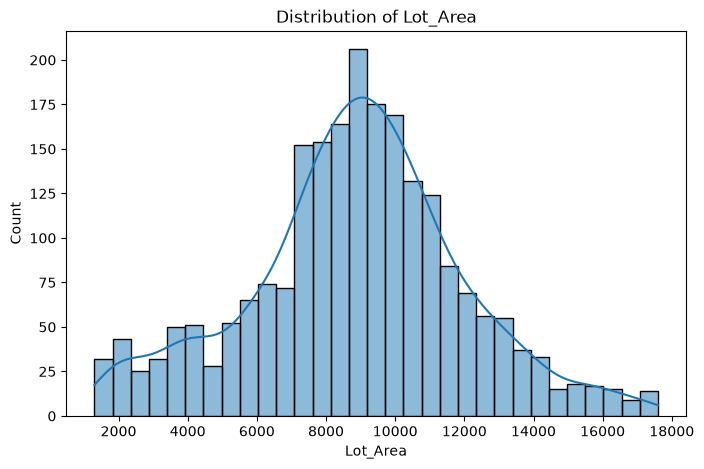

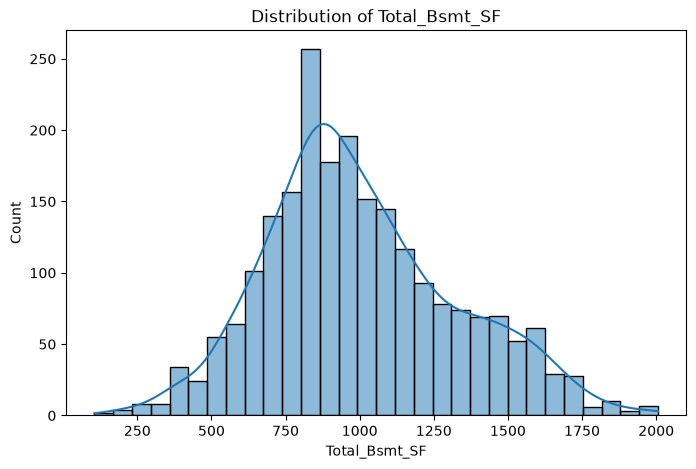

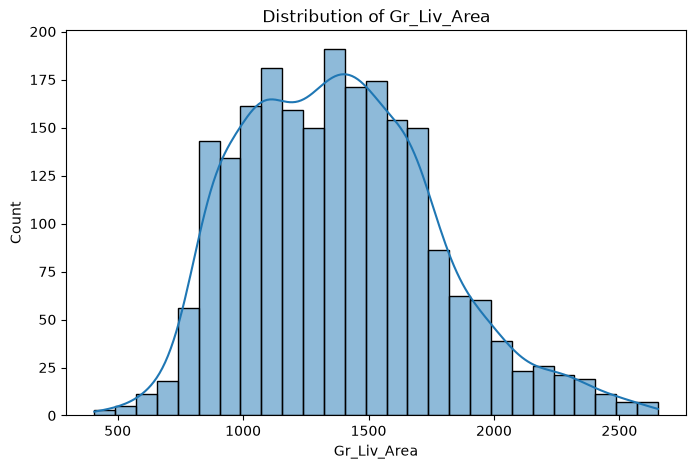

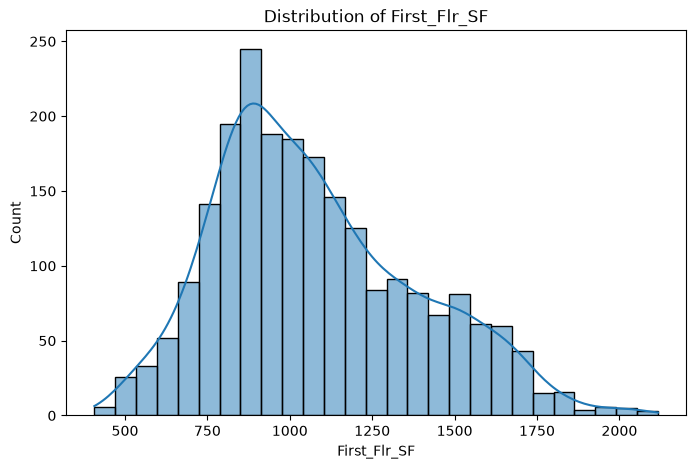

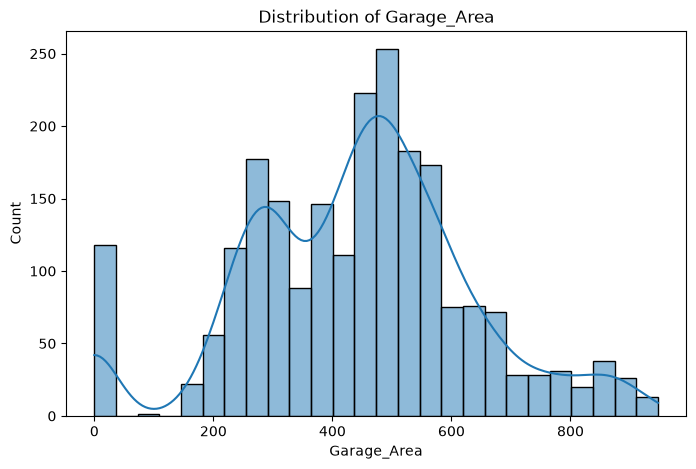

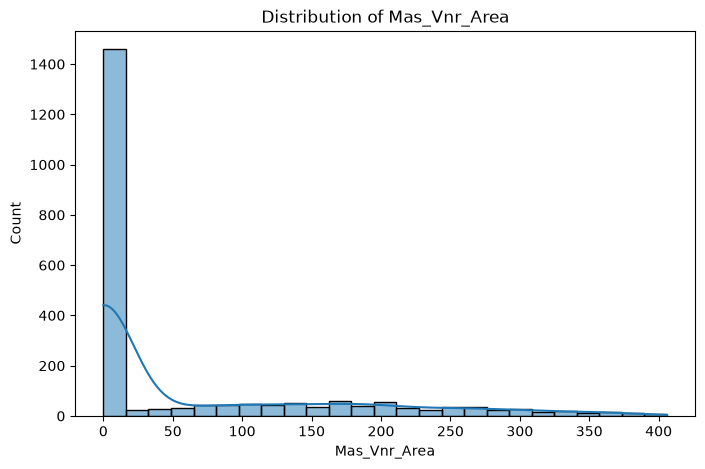

In [987]:
for feature in important_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )
    
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

In [988]:
df.dtypes.value_counts()

int64       33
category     3
category     2
category     2
category     2
float64      2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

In [989]:
df.select_dtypes(include='category').columns

Index(['MS_SubClass', 'MS_Zoning', 'Street', 'Alley', 'Lot_Shape',
       'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood',
       'Condition_1', 'Condition_2', 'Bldg_Type', 'House_Style',
       'Overall_Qual', 'Overall_Cond', 'Roof_Style', 'Roof_Matl',
       'Exterior_1st', 'Exterior_2nd', 'Mas_Vnr_Type', 'Exter_Qual',
       'Exter_Cond', 'Foundation', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure',
       'BsmtFin_Type_1', 'BsmtFin_Type_2', 'Heating', 'Heating_QC',
       'Central_Air', 'Electrical', 'Kitchen_Qual', 'Functional',
       'Fireplace_Qu', 'Garage_Type', 'Garage_Finish', 'Garage_Qual',
       'Garage_Cond', 'Paved_Drive', 'Pool_QC', 'Fence', 'Misc_Feature',
       'Sale_Type', 'Sale_Condition'],
      dtype='str')

In [990]:
new_feature = df[categorical_features].nunique().sort_values(ascending=False)
new_feature

Neighborhood      28
MS_SubClass       16
Exterior_2nd      16
Exterior_1st      15
Sale_Type         10
Overall_Qual      10
Condition_1        9
Overall_Cond       9
House_Style        8
Garage_Type        7
BsmtFin_Type_2     6
Roof_Style         6
Condition_2        6
Fireplace_Qu       6
Electrical         6
Garage_Qual        6
Sale_Condition     6
Garage_Cond        6
BsmtFin_Type_1     6
Functional         6
Fence              5
Lot_Config         5
MS_Zoning          5
Heating_QC         5
Kitchen_Qual       5
Bsmt_Cond          5
Foundation         5
Bsmt_Exposure      5
Bldg_Type          5
Exter_Cond         5
Bsmt_Qual          5
Roof_Matl          4
Heating            4
Garage_Finish      4
Land_Contour       4
Lot_Shape          4
Mas_Vnr_Type       4
Exter_Qual         4
Misc_Feature       4
Pool_QC            4
Alley              3
Land_Slope         3
Paved_Drive        3
Street             2
Central_Air        2
Utilities          1
dtype: int64

In [991]:
df['Utilities'].value_counts()

Utilities
AllPub    2222
NoSeWa       0
NoSewr       0
Name: count, dtype: int64

In [992]:
df2 = data.frame
df2['Utilities'].value_counts()

Utilities
AllPub    2927
NoSewr       2
NoSeWa       1
Name: count, dtype: int64

In [993]:
categorical_features2 = df2.select_dtypes(include='category').columns
categorical_features2

Index(['MS_SubClass', 'MS_Zoning', 'Street', 'Alley', 'Lot_Shape',
       'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood',
       'Condition_1', 'Condition_2', 'Bldg_Type', 'House_Style',
       'Overall_Qual', 'Overall_Cond', 'Roof_Style', 'Roof_Matl',
       'Exterior_1st', 'Exterior_2nd', 'Mas_Vnr_Type', 'Exter_Qual',
       'Exter_Cond', 'Foundation', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure',
       'BsmtFin_Type_1', 'BsmtFin_Type_2', 'Heating', 'Heating_QC',
       'Central_Air', 'Electrical', 'Kitchen_Qual', 'Functional',
       'Fireplace_Qu', 'Garage_Type', 'Garage_Finish', 'Garage_Qual',
       'Garage_Cond', 'Paved_Drive', 'Pool_QC', 'Fence', 'Misc_Feature',
       'Sale_Type', 'Sale_Condition'],
      dtype='str')

In [994]:
outlier_feaure = df2[categorical_features2].nunique().sort_values(ascending=False)
outlier_feaure

Neighborhood      28
Exterior_2nd      17
Exterior_1st      16
MS_SubClass       16
Sale_Type         10
Overall_Qual      10
Condition_1        9
Overall_Cond       9
Roof_Matl          8
Functional         8
House_Style        8
Condition_2        8
BsmtFin_Type_2     7
MS_Zoning          7
BsmtFin_Type_1     7
Garage_Type        7
Garage_Qual        6
Fireplace_Qu       6
Garage_Cond        6
Bsmt_Cond          6
Foundation         6
Roof_Style         6
Sale_Condition     6
Misc_Feature       6
Heating            6
Bsmt_Qual          6
Electrical         6
Bsmt_Exposure      5
Bldg_Type          5
Lot_Config         5
Fence              5
Pool_QC            5
Kitchen_Qual       5
Heating_QC         5
Mas_Vnr_Type       5
Exter_Cond         5
Land_Contour       4
Lot_Shape          4
Exter_Qual         4
Garage_Finish      4
Alley              3
Land_Slope         3
Paved_Drive        3
Utilities          3
Street             2
Central_Air        2
dtype: int64

In [995]:
diffrence_cat =pd.DataFrame([
    (pd.Series(outlier_feaure, name='outlier_feaure')),
    (pd.Series(new_feature, name='new_feature')),
]).T
diffrence_cat['diffrence'] = (outlier_feaure - new_feature)
diffrence_cat.sort_values('new_feature', ascending=False)

,outlier_feaure,new_feature,diffrence
Neighborhood,28,28,0
Exterior_2nd,17,16,1
MS_SubClass,16,16,0
Exterior_1st,16,15,1
Sale_Type,10,10,0
Overall_Qual,10,10,0
Condition_1,9,9,0
Overall_Cond,9,9,0
House_Style,8,8,0
Garage_Type,7,7,0


In [996]:
df.shape

(2222, 81)

In [997]:
print(f"Roof_Matl_df2: {df2['Roof_Matl'].value_counts()}\n")
print(f"Roof_Matl_df: {df['Roof_Matl'].value_counts()}")

Roof_Matl_df2: Roof_Matl
CompShg    2887
Tar&Grv      23
WdShake       9
WdShngl       7
ClyTile       1
Membran       1
Metal         1
Roll          1
Name: count, dtype: int64

Roof_Matl_df: Roof_Matl
CompShg    2209
Tar&Grv      10
WdShake       2
WdShngl       1
ClyTile       0
Membran       0
Metal         0
Roll          0
Name: count, dtype: int64


In [998]:
df['Central_Air'].unique()

['Y', 'N']
Categories (2, str): ['N', 'Y']

In [999]:
df['Street'].unique()

['Pave', 'Grvl']
Categories (2, str): ['Grvl', 'Pave']

In [1000]:
def show_categories(features):
    for feature in features:
        values = df[feature].unique()

        print(f"{feature:<20} | {len(values):>2} categories | {', '.join(map(str, values))}")

show_categories(new_feature.index)

Neighborhood         | 28 categories | North_Ames, Gilbert, Stone_Brook, Northwest_Ames, Somerset, Briardale, Northpark_Villa, Northridge_Heights, Bloomington_Heights, Northridge, Sawyer_West, Sawyer, Greens, Brookside, Old_Town, Iowa_DOT_and_Rail_Road, Clear_Creek, South_and_West_of_Iowa_State_University, Edwards, College_Creek, Crawford, Blueste, Mitchell, Timberland, Meadow_Village, Veenker, Green_Hills, Landmark
MS_SubClass          | 16 categories | One_Story_1946_and_Newer_All_Styles, Two_Story_1946_and_Newer, One_Story_PUD_1946_and_Newer, Split_Foyer, Two_Story_PUD_1946_and_Newer, Split_or_Multilevel, One_Story_1945_and_Older, One_and_Half_Story_Finished_All_Ages, Duplex_All_Styles_and_Ages, Two_Family_conversion_All_Styles_and_Ages, One_and_Half_Story_Unfinished_All_Ages, Two_Story_1945_and_Older, Two_and_Half_Story_All_Ages, PUD_Multilevel_Split_Level_Foyer, One_Story_with_Finished_Attic_All_Ages, One_and_Half_Story_PUD_All_Ages
Exterior_2nd         | 16 categories | VinylSd, 

In [1001]:
ordinal_features = [
    'Overall_Qual',
    'Overall_Cond',
    'Exter_Qual',
    'Exter_Cond',
    'Bsmt_Qual',
    'Bsmt_Cond',
    'Bsmt_Exposure',
    'BsmtFin_Type_1',
    'BsmtFin_Type_2',
    'Heating_QC',
    'Kitchen_Qual',
    'Garage_Qual',
    'Garage_Cond',
    'Garage_Finish',
    'Fireplace_Qu',
    'Functional'
]

In [1002]:
nominal_features = [
    'Neighborhood',
    'MS_SubClass',
    'Exterior_1st',
    'Exterior_2nd',
    'Sale_Type',
    'Condition_1',
    'Condition_2',
    'House_Style',
    'Garage_Type',
    'Roof_Style',
    'Electrical',
    'Sale_Condition',
    'Fence',
    'Lot_Config',
    'MS_Zoning',
    'Street',
    'Alley',
    'Land_Slope',
    'Paved_Drive',
    'Roof_Matl',
    'Heating',
    'Land_Contour',
    'Lot_Shape',
    'Mas_Vnr_Type',
    'Misc_Feature',
    'Pool_QC',
    'Foundation',
    'Bldg_Type'
]
len(nominal_features)

28

In [1003]:
binary_features = ['Central_Air']

In [1004]:
df = df.drop(columns=['Utilities'])

## Categorical Feature Preparation

The categorical features were analyzed based on their **cardinality** and the presence of an inherent ordering between categories.

### Feature Encoding Strategy

Categorical features were divided into three groups:

* **Ordinal Features:** Features with a meaningful order between categories.
* **Nominal Features:** Features where categories have no inherent order.
* **Binary Features:** Features containing only two categories.

For the encoding stage:

* **Ordinal features** will be encoded while preserving their natural order.
* **Nominal features** will be encoded using **One-Hot Encoding**.
* `Central_Air` will be treated as a binary feature.
* `Utilities` was removed because only one category remained after outlier removal, making it a constant feature with no predictive information.

This separation ensures that the categorical encoding strategy is appropriate for the underlying structure of each feature and avoids introducing artificial relationships between nominal categories.


## **Central_Air**

In [1005]:
df['Central_Air'].cat.categories

Index(['N', 'Y'], dtype='str')

In [1006]:
df['Central_Air'] = df['Central_Air'].cat.codes

## **Overall_Qual**

In [1007]:
df['Overall_Qual'].cat.categories

Index(['Above_Average', 'Average', 'Below_Average', 'Excellent', 'Fair',
       'Good', 'Poor', 'Very_Excellent', 'Very_Good', 'Very_Poor'],
      dtype='str')

In [1008]:
overall_qual_order = [
    'Very_Poor',
    'Poor',
    'Fair',
    'Below_Average',
    'Average',
    'Above_Average',
    'Good',
    'Very_Good',
    'Excellent',
    'Very_Excellent'
]
df['Overall_Qual'] = pd.Categorical(
    df['Overall_Qual'],
    categories=overall_qual_order,
    ordered=True
)

In [1009]:
df['Overall_Qual'].cat.categories

Index(['Very_Poor', 'Poor', 'Fair', 'Below_Average', 'Average',
       'Above_Average', 'Good', 'Very_Good', 'Excellent', 'Very_Excellent'],
      dtype='str')

In [1010]:
df['Overall_Qual'] = df['Overall_Qual'].cat.codes

## **Overall_Cond**

In [1011]:
df['Overall_Cond'].cat.categories

Index(['Above_Average', 'Average', 'Below_Average', 'Excellent', 'Fair',
       'Good', 'Poor', 'Very_Good', 'Very_Poor'],
      dtype='str')

In [1012]:
overall_cond_order = [
    'Very_Poor',
    'Poor',
    'Fair',
    'Below_Average',
    'Average',
    'Above_Average',
    'Good',
    'Very_Good',
    'Excellent'
]

df['Overall_Cond'] = pd.Categorical(
    df['Overall_Cond'],
    categories=overall_cond_order,
    ordered=True
)

In [1013]:
df['Overall_Cond'].cat.categories

Index(['Very_Poor', 'Poor', 'Fair', 'Below_Average', 'Average',
       'Above_Average', 'Good', 'Very_Good', 'Excellent'],
      dtype='str')

In [1014]:
df['Overall_Cond'] = df['Overall_Cond'].cat.codes

## **Exter_Qual**

In [1015]:
df['Exter_Qual'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'Typical'], dtype='str')

In [1016]:
exter_qual_order = [
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Exter_Qual'],
    categories=exter_qual_order,
    ordered=True
)


['Typical', 'Typical', 'Typical', 'Typical', 'Good', ..., 'Typical', 'Typical', 'Typical', 'Typical', 'Typical']
Length: 2222
Categories (4, str): ['Fair' < 'Typical' < 'Good' < 'Excellent']

In [1017]:
df['Exter_Qual']= df['Exter_Qual'].cat.codes

## **Exter_Cond**

In [1018]:
df['Exter_Cond'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'Poor', 'Typical'], dtype='str')

In [1019]:
exter_cond_order = [
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

df['Exter_Cond'] =pd.Categorical(
    df['Exter_Cond'],
    categories=exter_cond_order,
    ordered=True
)

In [1020]:
df['Exter_Cond'] = df['Exter_Cond'].cat.codes

## **Bsmt_Qual**

In [1021]:
df['Bsmt_Qual'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Basement', 'Poor', 'Typical'], dtype='str')

In [1022]:
bsmt_qual_order = [
    'No_Basement',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Bsmt_Qual'],
    categories=bsmt_qual_order,
    ordered=True
)

['Typical', 'Typical', 'Good', 'Typical', 'Good', ..., 'Typical', 'Good', 'Good', 'Good', 'Good']
Length: 2222
Categories (6, str): ['No_Basement' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [1023]:
df['Bsmt_Qual'] = df['Bsmt_Qual'].cat.codes

## **Bsmt_Cond**

In [1024]:
df['Bsmt_Cond'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Basement', 'Poor', 'Typical'], dtype='str')

In [1025]:
bsmt_cond_order = [
    'No_Basement',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Bsmt_Cond'],
    categories=bsmt_cond_order,
    ordered=True
)

['Typical', 'Typical', 'Typical', 'Typical', 'Typical', ..., 'Typical', 'Typical', 'Typical', 'Typical', 'Typical']
Length: 2222
Categories (6, str): ['No_Basement' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [1026]:
df['Bsmt_Cond'] = df['Bsmt_Cond'].cat.codes

## **Bsmt_Exposure**

In [1027]:
df['Bsmt_Exposure'].cat.categories

Index(['Av', 'Gd', 'Mn', 'No', 'No_Basement'], dtype='str')

In [1028]:
bsmt_exposure_order = [
    'No_Basement',
    'No',
    'Mn',
    'Av',
    'Gd'
]

pd.Categorical(
    df['Bsmt_Exposure'],
    categories=bsmt_exposure_order,
    ordered=True
)

['No', 'No', 'No', 'No', 'Mn', ..., 'Av', 'Av', 'Av', 'Av', 'Av']
Length: 2222
Categories (5, str): ['No_Basement' < 'No' < 'Mn' < 'Av' < 'Gd']

In [1029]:
df['Bsmt_Exposure'] = df['Bsmt_Exposure'].cat.codes

## **BsmtFin_Type_1**

In [1030]:
df['BsmtFin_Type_1'].cat.categories

Index(['ALQ', 'BLQ', 'GLQ', 'LwQ', 'No_Basement', 'Rec', 'Unf'], dtype='str')

In [1031]:
bsmtfin_type_1_order = [
    'No_Basement',
    'Unf',
    'LwQ',
    'Rec',
    'BLQ',
    'ALQ',
    'GLQ'
]

pd.Categorical(
    df['BsmtFin_Type_1'],
    categories=bsmtfin_type_1_order,
    ordered=True
)

['Rec', 'ALQ', 'GLQ', 'GLQ', 'GLQ', ..., 'GLQ', 'BLQ', 'GLQ', 'ALQ', 'LwQ']
Length: 2222
Categories (7, str): ['No_Basement' < 'Unf' < 'LwQ' < 'Rec' < 'BLQ' < 'ALQ' < 'GLQ']

In [1032]:
df['BsmtFin_Type_1'] = df['BsmtFin_Type_1'].cat.codes

## **BsmtFin_Type_2**

In [1033]:
df['BsmtFin_Type_2'].cat.categories

Index(['ALQ', 'BLQ', 'GLQ', 'LwQ', 'No_Basement', 'Rec', 'Unf'], dtype='str')

In [1034]:
bsmtfin_type_2_order = [
    'No_Basement',
    'Unf',
    'LwQ',
    'Rec',
    'BLQ',
    'ALQ',
    'GLQ'
]

pd.Categorical(
    df['BsmtFin_Type_2'],
    categories=bsmtfin_type_2_order,
    ordered=True
)


['LwQ', 'Unf', 'Unf', 'Unf', 'Unf', ..., 'Unf', 'ALQ', 'Unf', 'LwQ', 'Unf']
Length: 2222
Categories (7, str): ['No_Basement' < 'Unf' < 'LwQ' < 'Rec' < 'BLQ' < 'ALQ' < 'GLQ']

In [1035]:
df['BsmtFin_Type_2'] = df['BsmtFin_Type_2'].cat.codes

## **Heating_QC**

In [1036]:
df['Heating_QC'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'Poor', 'Typical'], dtype='str')

In [1037]:
heating_qc_order = [
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]
pd.Categorical(
    df['Heating_QC'],
    categories=heating_qc_order,
    ordered=True
)


['Typical', 'Typical', 'Good', 'Excellent', 'Excellent', ..., 'Typical', 'Typical', 'Typical', 'Good', 'Excellent']
Length: 2222
Categories (5, str): ['Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [1038]:
df['Heating_QC'] = df['Heating_QC'].cat.codes

## **Kitchen_Qual**

In [1039]:
df['Kitchen_Qual'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'Poor', 'Typical'], dtype='str')

In [1040]:
kitchen_qual_order = [
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Kitchen_Qual'],
    categories=kitchen_qual_order,
    ordered=True
)


['Typical', 'Good', 'Typical', 'Good', 'Good', ..., 'Typical', 'Typical', 'Typical', 'Typical', 'Typical']
Length: 2222
Categories (5, str): ['Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [1041]:
df['Kitchen_Qual'] = df['Kitchen_Qual'].cat.codes

## **Garage_Qual**

In [1042]:
df['Garage_Qual'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Garage', 'Poor', 'Typical'], dtype='str')

In [1043]:
garage_qual_order = [
    'No_Garage',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Garage_Qual'],
    categories=garage_qual_order,
    ordered=True
)

['Typical', 'Typical', 'Typical', 'Typical', 'Typical', ..., 'Typical', 'Typical', 'No_Garage', 'Typical', 'Typical']
Length: 2222
Categories (6, str): ['No_Garage' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [1044]:
df['Garage_Qual'] = df['Garage_Qual'].cat.codes

## **Garage_Cond**

In [1045]:
df['Garage_Cond'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Garage', 'Poor', 'Typical'], dtype='str')

In [1046]:
garage_cond_order = [
    'No_Garage',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Garage_Cond'],
    categories=garage_cond_order,
    ordered=True
)

['Typical', 'Typical', 'Typical', 'Typical', 'Typical', ..., 'Typical', 'Typical', 'No_Garage', 'Typical', 'Typical']
Length: 2222
Categories (6, str): ['No_Garage' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [1047]:
df['Garage_Cond'] = df['Garage_Cond'].cat.codes

## **Garage_Finish**

In [1048]:
df['Garage_Finish'].cat.categories

Index(['Fin', 'No_Garage', 'RFn', 'Unf'], dtype='str')

In [1049]:
garage_finish_order = [
    'No_Garage',
    'Unf',
    'RFn',
    'Fin'
]
pd.Categorical(
    df['Garage_Finish'],
    categories=garage_finish_order,
    ordered=True
)


['Unf', 'Unf', 'Fin', 'Fin', 'Fin', ..., 'Unf', 'Unf', 'No_Garage', 'RFn', 'Fin']
Length: 2222
Categories (4, str): ['No_Garage' < 'Unf' < 'RFn' < 'Fin']

In [1050]:
df['Garage_Finish'] = df['Garage_Finish'].cat.codes

## **Fireplace_Qu**

In [1051]:
df['Fireplace_Qu'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Fireplace', 'Poor', 'Typical'], dtype='str')

In [1052]:
fireplace_qu_order = [
    'No_Fireplace',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Fireplace_Qu'],
    categories=fireplace_qu_order,
    ordered=True
)


['No_Fireplace', 'No_Fireplace', 'Typical', 'Good', 'No_Fireplace', ..., 'No_Fireplace', 'No_Fireplace', 'No_Fireplace', 'Typical', 'Typical']
Length: 2222
Categories (6, str): ['No_Fireplace' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [1053]:
df['Fireplace_Qu'] = df['Fireplace_Qu'].cat.codes

## **Functional**

In [1054]:
df['Functional'].cat.categories

Index(['Maj1', 'Maj2', 'Min1', 'Min2', 'Mod', 'Sal', 'Sev', 'Typ'], dtype='str')

In [1055]:
functional_order = [
    'Sal',
    'Sev',
    'Maj2',
    'Maj1',
    'Mod',
    'Min2',
    'Min1',
    'Typ'
]

pd.Categorical(
    df['Functional'],
    categories=functional_order,
    ordered=True
)


['Typ', 'Typ', 'Typ', 'Typ', 'Typ', ..., 'Typ', 'Typ', 'Typ', 'Typ', 'Typ']
Length: 2222
Categories (8, str): ['Sal' < 'Sev' < 'Maj2' < 'Maj1' < 'Mod' < 'Min2' < 'Min1' < 'Typ']

In [1056]:
df['Functional'] = df['Functional'].cat.codes

In [1057]:
ordinal_features

['Overall_Qual',
 'Overall_Cond',
 'Exter_Qual',
 'Exter_Cond',
 'Bsmt_Qual',
 'Bsmt_Cond',
 'Bsmt_Exposure',
 'BsmtFin_Type_1',
 'BsmtFin_Type_2',
 'Heating_QC',
 'Kitchen_Qual',
 'Garage_Qual',
 'Garage_Cond',
 'Garage_Finish',
 'Fireplace_Qu',
 'Functional']

In [1058]:
df[ordinal_features]

,Overall_Qual,Overall_Cond,Exter_Qual,Exter_Cond,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_Type_2,Heating_QC,Kitchen_Qual,Garage_Qual,Garage_Cond,Garage_Finish,Fireplace_Qu,Functional
1,4,5,3,2,5,5,3,5,3,4,4,5,5,3,3,7
2,5,5,3,2,5,5,3,0,6,4,2,5,5,3,3,7
4,4,4,3,2,2,5,3,2,6,2,4,5,5,0,5,7
5,5,5,3,2,5,5,3,2,6,0,2,5,5,0,2,7
6,7,4,2,2,2,5,2,2,6,0,2,5,5,0,3,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,5,5,3,2,5,5,0,2,6,4,4,5,5,3,3,7
2926,4,4,3,2,2,5,0,1,0,4,4,5,5,3,3,7
2927,4,4,3,2,2,5,0,2,6,4,4,3,3,1,3,7
2928,4,4,3,2,2,5,0,0,3,2,4,5,5,2,5,7


## Ordinal and Binary Encoding

The categorical features were first divided based on their underlying structure.

### Ordinal Encoding

Ordinal features were encoded according to their natural order. The category order was explicitly defined before encoding to preserve the meaningful relationship between the categories.

This approach was applied to quality, condition, and other categorical features where the categories have a meaningful progression.

### Binary Encoding

Binary categorical features containing only two categories were converted into numerical values (`0` and `1`).

This allows binary features to be directly used by machine learning models without introducing unnecessary additional features.

At this stage, **ordinal and binary categorical features have been encoded**. Nominal features will be handled separately using **One-Hot Encoding**.


In [1059]:
df = pd.get_dummies(
    df,
    columns=nominal_features,
    dtype=int
)
df.head()

,Lot_Frontage,Lot_Area,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Bsmt_Qual,...,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Bldg_Type_Duplex,Bldg_Type_OneFam,Bldg_Type_Twnhs,Bldg_Type_TwnhsE,Bldg_Type_TwoFmCon
1,80,11622,4,5,1961,1961,0,3,2,5,...,1,0,0,0,0,0,1,0,0,0
2,81,14267,5,5,1958,1958,108,3,2,5,...,1,0,0,0,0,0,1,0,0,0
4,74,13830,4,4,1997,1998,0,3,2,2,...,0,1,0,0,0,0,1,0,0,0
5,78,9978,5,5,1998,1998,20,3,2,5,...,0,1,0,0,0,0,1,0,0,0
6,41,4920,7,4,2001,2001,0,2,2,2,...,0,1,0,0,0,0,0,0,1,0


In [1060]:
print(df.shape)
print(df.dtypes.value_counts())

(2222, 266)
int64      247
int8        17
float64      2
Name: count, dtype: int64


## Categorical Encoding

The categorical features were encoded according to their underlying structure.

### Ordinal Encoding

Ordinal features were encoded according to their natural order. The category order was explicitly defined before encoding to preserve the meaningful relationship between categories.

### Binary Encoding

Binary categorical features containing only two categories were converted into numerical values (`0` and `1`).

### One-Hot Encoding

Nominal categorical features do not have an inherent order. Therefore, **One-Hot Encoding** was applied using `pandas.get_dummies()`.

Each category was converted into a separate binary feature, allowing the model to use nominal information without introducing an artificial numerical relationship between categories.

### Result

After encoding, all categorical features were converted into numerical representations suitable for machine learning models.

The dataset now contains **2222 observations and 266 features** after the encoding process.


In [1061]:
corr = abs(df.corr())

high_corr = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack()

high_corr_pairs = high_corr[high_corr > 0.90].sort_values(ascending=False)
high_corr_pairs

BsmtFin_Type_1                                         BsmtFin_SF_1                    1.000000
MS_SubClass_Duplex_All_Styles_and_Ages                 Bldg_Type_Duplex                1.000000
Exterior_1st_CBlock                                    Exterior_2nd_CBlock             1.000000
Street_Grvl                                            Street_Pave                     1.000000
Exterior_1st_CemntBd                                   Exterior_2nd_CmentBd            0.988295
Sale_Type_New                                          Sale_Condition_Partial          0.983060
Land_Slope_Gtl                                         Land_Slope_Mod                  0.981714
Exterior_1st_VinylSd                                   Exterior_2nd_VinylSd            0.979398
MS_SubClass_Two_Family_conversion_All_Styles_and_Ages  Bldg_Type_TwoFmCon              0.977318
Pool_Area                                              Pool_QC_No_Pool                 0.975846
Exterior_1st_MetalSd                    

In [1062]:
df = df.drop(columns=[
    'BsmtFin_SF_1',
    'Bldg_Type_Duplex',
    'Exterior_2nd_CBlock',
    'Street_Pave',
    'Exterior_2nd_CmentBd',
    'Sale_Condition_Partial',
    'Land_Slope_Mod',
    'Exterior_2nd_VinylSd',
    'Bldg_Type_TwoFmCon',
    'Pool_QC_No_Pool',
    'Exterior_2nd_MetalSd',
    'Misc_Feature_Shed',
    'House_Style_SLvl',
    'Lot_Shape_Slightly_Irregular',
    'Roof_Style_Hip',
    'House_Style_One_and_Half_Fin'
])

In [1063]:
df.shape

(2222, 250)

## Correlation-Based Feature Reduction

After categorical encoding, the dataset contained **266 features**. To reduce redundant information, pairwise correlations between features were examined.

A correlation threshold of **0.90** was used to identify highly correlated feature pairs. From each highly correlated pair, one feature was removed to reduce redundancy while retaining the remaining feature for further analysis.

This step removed **16 features**, reducing the dataset from:

**266 → 250 features**

The reduced feature set will be used in the next stage of feature selection based on **Decision Tree Feature Importance**.


----------------------------------------------------------------------------------------------------------------------------------------------------------

## Model Training Setup

The required regression models, feature scaling methods, evaluation metrics, and cross-validation tools were imported for the **model training and evaluation** stage.

The models will be compared using **MAE, RMSE, and R²**.

**Linear Regression** will be used as the baseline model.


In [1064]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

## **feature important**

In [1065]:
df_corr = abs(df.corr()['Sale_Price']).sort_values(ascending=False).drop('Sale_Price')
df_corr

Overall_Qual           0.807995
Gr_Liv_Area            0.694040
Garage_Cars            0.652224
Year_Built             0.628310
Garage_Area            0.622539
                         ...   
Mas_Vnr_Type_CBlock         NaN
Misc_Feature_Elev           NaN
Misc_Feature_TenC           NaN
Pool_QC_Excellent           NaN
Foundation_Slab             NaN
Name: Sale_Price, Length: 249, dtype: float64

In [1066]:
X = df.drop(columns='Sale_Price')
y = df['Sale_Price']

In [1067]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

#### ****without scale****

## decisiontree

In [1068]:
tree1 = DecisionTreeRegressor(max_depth=3, min_samples_split=2, min_samples_leaf=20)

tree1.fit(X_train, y_train)

important_tree1 = tree1.feature_importances_
important_tree1

array([0.        , 0.        , 0.66574734, 0.        , 0.01860658,
       0.        , 0.        , 0.        , 0.        , 0.16517929,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.07023905, 0.        , 0.        ,
       0.08022773, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

## randomforest

In [1069]:
rf1 = RandomForestRegressor(max_depth=3, min_samples_split=2, min_samples_leaf=20)

rf1.fit(X_train, y_train)

important_rf1 = rf1.feature_importances_

In [1070]:
print(df_corr.shape)
print(important_tree1.shape)
print(important_rf1.shape)

(249,)
(249,)
(249,)


In [1071]:
df_important = pd.DataFrame({
    'Correlation': df_corr,
    'Random_Forest': important_rf1,
    'Decision_Tree': important_tree1
})
df_important.sort_values('Correlation', ascending=False)

,Correlation,Random_Forest,Decision_Tree
Overall_Qual,0.807995,0.000000,0.000000
Gr_Liv_Area,0.694040,0.000000,0.000000
Garage_Cars,0.652224,0.651301,0.665747
Year_Built,0.628310,0.000000,0.000000
Garage_Area,0.622539,0.066258,0.018607
...,...,...,...
Mas_Vnr_Type_CBlock,NaN,0.000000,0.000000
Misc_Feature_Elev,NaN,0.000000,0.000000
Misc_Feature_TenC,NaN,0.000000,0.000000
Pool_QC_Excellent,NaN,0.000000,0.000000


In [1072]:
mask = (
        (df_important['Correlation'].isna()) &
        (df_important['Random_Forest'] == 0) &
        (df_important['Decision_Tree'] == 0)
    )
df_important.index[mask].tolist()


['Exterior_1st_PreCast',
 'Exterior_2nd_PreCast',
 'Condition_2_RRAe',
 'Condition_2_RRAn',
 'MS_Zoning_A_agr',
 'MS_Zoning_I_all',
 'Roof_Matl_ClyTile',
 'Roof_Matl_Membran',
 'Roof_Matl_Metal',
 'Roof_Matl_Roll',
 'Heating_Floor',
 'Heating_Wall',
 'Mas_Vnr_Type_CBlock',
 'Misc_Feature_Elev',
 'Misc_Feature_TenC',
 'Pool_QC_Excellent',
 'Foundation_Slab']

In [1073]:
print("NaN Correlation:", df_important['Correlation'].isna().sum())
print("Zero Correlation:", (df_important['Correlation'] == 0).sum())
print("Zero RF:", (df_important['Random_Forest'] == 0).sum())
print("Zero Tree:", (df_important['Decision_Tree'] == 0).sum())

NaN Correlation: 17
Zero Correlation: 0
Zero RF: 226
Zero Tree: 244


#### ****with scale****

## decision tree

In [1074]:
tree2 = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=20
)

tree2.fit(X_train_scaled, y_train)

important_tree2 = tree2.feature_importances_

## randomforest

In [1075]:
rf2 = RandomForestRegressor(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=20
)

rf2.fit(X_train_scaled, y_train)

important_rf2 = rf2.feature_importances_

In [1076]:
df_important2 = pd.DataFrame({
    'Correlation': df_corr,
    'Random_Forest': important_rf2,
    'Decision_Tree': important_tree2
})
df_important2.sort_values('Correlation', ascending=False)

,Correlation,Random_Forest,Decision_Tree
Overall_Qual,0.807995,0.000469,0.000000
Gr_Liv_Area,0.694040,0.000807,0.000000
Garage_Cars,0.652224,0.650164,0.665747
Year_Built,0.628310,0.000000,0.000000
Garage_Area,0.622539,0.062044,0.018607
...,...,...,...
Mas_Vnr_Type_CBlock,NaN,0.000000,0.000000
Misc_Feature_Elev,NaN,0.000000,0.000000
Misc_Feature_TenC,NaN,0.000000,0.000000
Pool_QC_Excellent,NaN,0.000000,0.000000


In [1077]:
mask2 = (
        (df_important['Correlation'].isna()) &
        (df_important['Random_Forest'] == 0) &
        (df_important['Decision_Tree'] == 0)
    )
df_important2.index[mask2].tolist()

['Exterior_1st_PreCast',
 'Exterior_2nd_PreCast',
 'Condition_2_RRAe',
 'Condition_2_RRAn',
 'MS_Zoning_A_agr',
 'MS_Zoning_I_all',
 'Roof_Matl_ClyTile',
 'Roof_Matl_Membran',
 'Roof_Matl_Metal',
 'Roof_Matl_Roll',
 'Heating_Floor',
 'Heating_Wall',
 'Mas_Vnr_Type_CBlock',
 'Misc_Feature_Elev',
 'Misc_Feature_TenC',
 'Pool_QC_Excellent',
 'Foundation_Slab']

In [1078]:
print("NaN Correlation:", df_important2['Correlation'].isna().sum())
print("Zero Correlation:", (df_important2['Correlation'] == 0).sum())
print("Zero RF:", (df_important2['Random_Forest'] == 0).sum())
print("Zero Tree:", (df_important2['Decision_Tree'] == 0).sum())

NaN Correlation: 17
Zero Correlation: 0
Zero RF: 227
Zero Tree: 244


In [1079]:
df = df.drop(
    columns=[
    'Exterior_1st_PreCast',
    'Exterior_2nd_PreCast',
    'Condition_2_RRAe',
    'Condition_2_RRAn',
    'MS_Zoning_A_agr',
    'MS_Zoning_I_all',
    'Roof_Matl_ClyTile',
    'Roof_Matl_Membran',
    'Heating_Wall',
    'Mas_Vnr_Type_CBlock',
    'Misc_Feature_Elev',
    'Foundation_Slab'
])

In [1080]:
df.head()

,Lot_Frontage,Lot_Area,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Bsmt_Qual,...,Pool_QC_Good,Pool_QC_Typical,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Stone,Foundation_Wood,Bldg_Type_OneFam,Bldg_Type_Twnhs,Bldg_Type_TwnhsE
1,80,11622,4,5,1961,1961,0,3,2,5,...,0,0,0,1,0,0,0,1,0,0
2,81,14267,5,5,1958,1958,108,3,2,5,...,0,0,0,1,0,0,0,1,0,0
4,74,13830,4,4,1997,1998,0,3,2,2,...,0,0,0,0,1,0,0,1,0,0
5,78,9978,5,5,1998,1998,20,3,2,5,...,0,0,0,0,1,0,0,1,0,0
6,41,4920,7,4,2001,2001,0,2,2,2,...,0,0,0,0,1,0,0,0,0,1


## Feature Selection

After categorical encoding, the dataset contained **266 columns**, including the target variable `Sale_Price`.

### Correlation-Based Feature Reduction

Highly correlated feature pairs were identified using a correlation threshold of **0.90**. From each highly correlated pair, one feature was removed to reduce redundant information.

This reduced the dataset from:

**266 → 250 columns**

including the target variable.

### Feature Importance

Feature importance was then evaluated using both:

* `RandomForestRegressor`
* `DecisionTreeRegressor`

Features with `NaN` correlation with the target and zero feature importance in both tree-based models were considered low-information features.

A total of **12 features** met all three conditions and were removed:

* `Exterior_1st_PreCast`
* `Exterior_2nd_PreCast`
* `Condition_2_RRAe`
* `Condition_2_RRAn`
* `MS_Zoning_A_agr`
* `MS_Zoning_I_all`
* `Roof_Matl_ClyTile`
* `Roof_Matl_Membran`
* `Heating_Wall`
* `Mas_Vnr_Type_CBlock`
* `Misc_Feature_Elev`
* `Foundation_Slab`

### Result

The feature selection process reduced the dataset from:

**250 → 238 columns**

including the target variable.

Therefore, the final dataset contains:

* **237 features**
* **1 target variable (`Sale_Price`)**

The selected features will be used in the **model training and evaluation stage**.


----------------------------------------------------------------------------------------------------------------------------------

## Modeling Without PCA

Regression models will be trained using the selected features **without applying PCA**.

The model performances will be compared using **MAE, RMSE, and R²**.


In [1081]:
from utils import plot_actual_vs_predicted, plot_residuals_qq, evaluate_model

In [1082]:
X = df.drop(columns='Sale_Price')
y = df['Sale_Price']

In [1083]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [1084]:
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

# **LinearRegression**

In [1085]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1086]:
y_pred_lr = lr.predict(X_test_scaled)

In [1087]:
results_linear = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test)
results_linear

Train Metrics
MAE:  11,005.55
MSE:  228,222,469.92
RMSE: 15,107.03
R²:   0.9351

Test Metrics
MAE:  12,409.07
MSE:  287,407,820.06
RMSE: 16,953.11
R²:   0.9076


{'Train': {'MAE': 11005.554857496763,
  'MSE': 228222469.9162768,
  'RMSE': np.float64(15107.03378947293),
  'R²': 0.935073561421965},
 'Test': {'MAE': 12409.07466982397,
  'MSE': 287407820.0618472,
  'RMSE': np.float64(16953.106501813974),
  'R²': 0.90758852403334}}

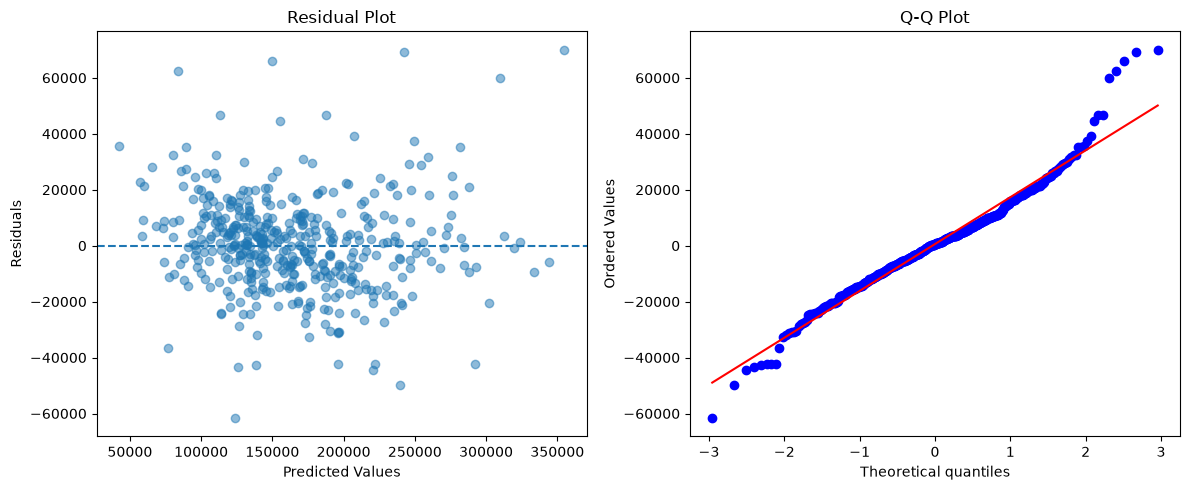

In [1088]:
plot_residuals_qq(lr, X_test_scaled, y_test)

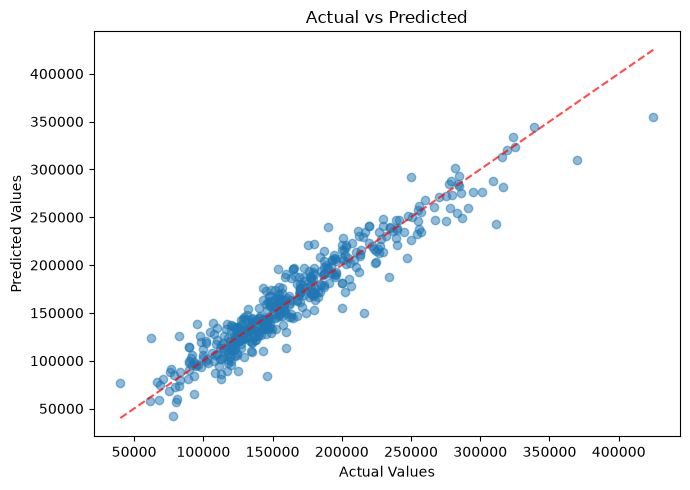

In [1089]:
plot_actual_vs_predicted(lr, X_test_scaled, y_test)

## Linear Regression Results

| Metric |          Train |           Test |
| ------ | -------------: | -------------: |
| MAE    |      11,005.55 |      12,409.07 |
| MSE    | 228,222,469.92 | 287,407,820.06 |
| RMSE   |      15,107.03 |      16,953.11 |
| R²     |         0.9351 |         0.9076 |

The model performs well on both training and test data, with a relatively small gap between the two sets, indicating **no significant overfitting**.


------------------------------------

# **Ridge**

In [1090]:
rd = Ridge(alpha=1)

rd.fit(X_train_scaled, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [1091]:
y_pred_rd = rd.predict(X_test_scaled)

In [1092]:
results_ridge = evaluate_model(rd, X_train_scaled, X_test_scaled, y_train, y_test)
results_ridge

Train Metrics
MAE:  11,005.37
MSE:  228,228,623.63
RMSE: 15,107.24
R²:   0.9351

Test Metrics
MAE:  12,402.65
MSE:  287,213,681.03
RMSE: 16,947.38
R²:   0.9077


{'Train': {'MAE': 11005.367044476956,
  'MSE': 228228623.6330819,
  'RMSE': np.float64(15107.23745868456),
  'R²': 0.9350718107664913},
 'Test': {'MAE': 12402.646093519254,
  'MSE': 287213681.0287363,
  'RMSE': np.float64(16947.379768823743),
  'R²': 0.9076509463939726}}

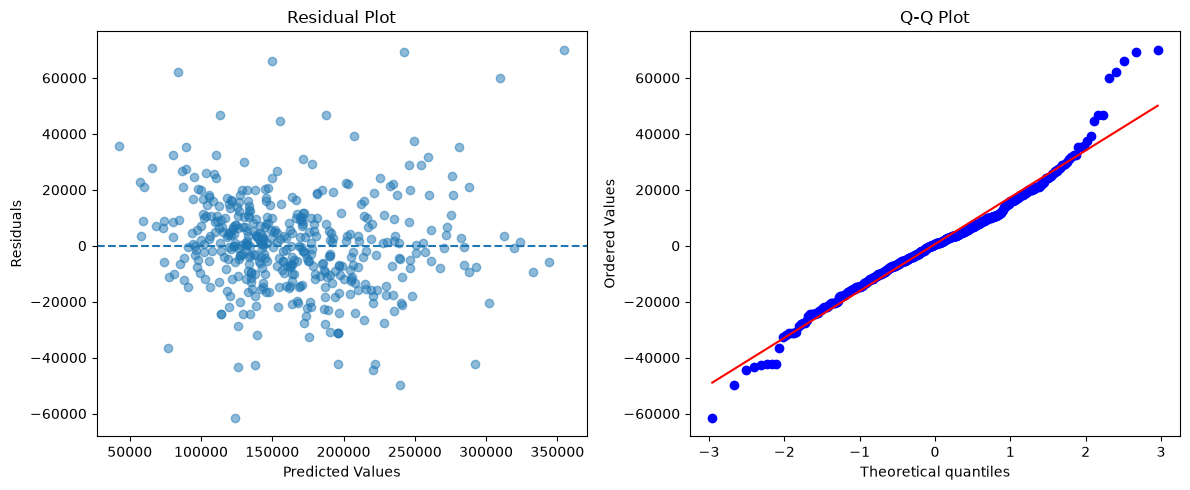

In [1093]:
plot_residuals_qq(rd, X_test_scaled, y_test)

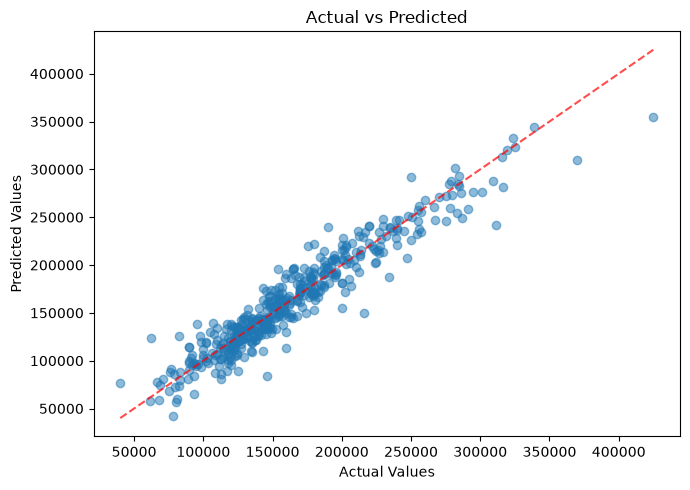

In [1094]:
plot_actual_vs_predicted(rd, X_test_scaled, y_test)

## Ridge Regression Results

| Metric |          Train |           Test |
| ------ | -------------: | -------------: |
| MAE    |      11,005.37 |      12,402.65 |
| MSE    | 228,228,623.63 | 287,213,681.03 |
| RMSE   |      15,107.24 |      16,947.38 |
| R²     |         0.9351 |         0.9077 |

Ridge Regression achieved similar performance to Linear Regression, with a slightly lower test RMSE and a slightly higher test R².


---------------------------------

# **Lasso**

In [1095]:
ls = Lasso(alpha=1)

ls.fit(X_train_scaled, y_train)

C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.482e+09, tolerance: 6.246e+08
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [1096]:
y_pred_ls = ls.predict(X_test_scaled)

In [1097]:
results_lasso = evaluate_model(ls, X_train_scaled, X_test_scaled, y_train, y_test)
results_lasso

Train Metrics
MAE:  11,005.39
MSE:  228,225,247.72
RMSE: 15,107.13
R²:   0.9351

Test Metrics
MAE:  12,399.33
MSE:  287,107,402.79
RMSE: 16,944.24
R²:   0.9077


C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.482e+09, tolerance: 6.246e+08
  model = cd_fast.enet_coordinate_descent(


{'Train': {'MAE': 11005.392980314336,
  'MSE': 228225247.72086304,
  'RMSE': np.float64(15107.125726651746),
  'R²': 0.9350727711712989},
 'Test': {'MAE': 12399.331507681101,
  'MSE': 287107402.78552496,
  'RMSE': np.float64(16944.243942576046),
  'R²': 0.9076851184958875}}

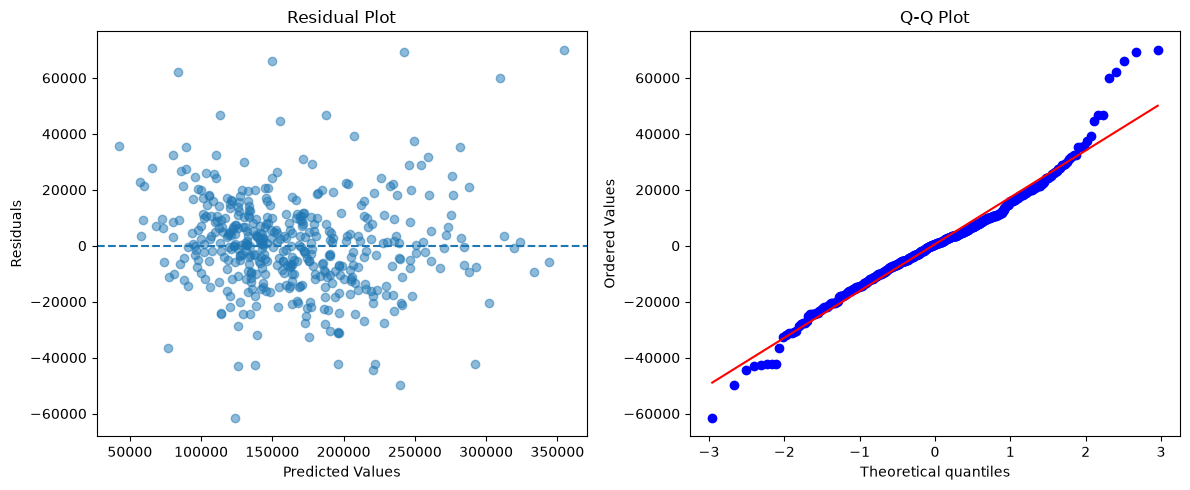

In [1098]:
plot_residuals_qq(ls, X_test_scaled, y_test)

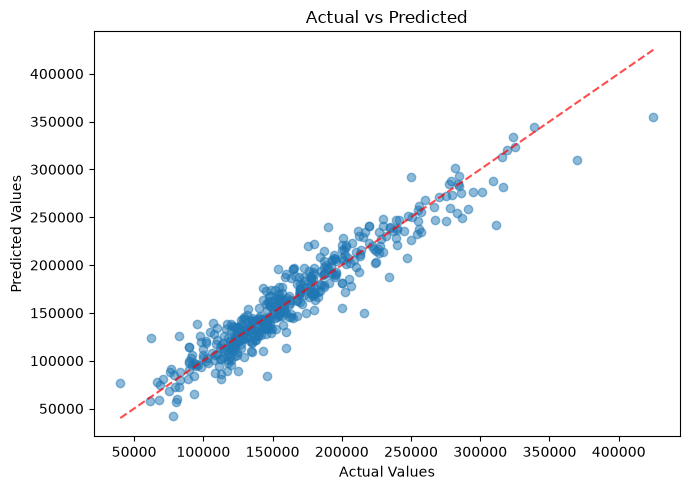

In [1099]:
plot_actual_vs_predicted(ls, X_test_scaled, y_test)

## Lasso Regression Results

| Metric |          Train |           Test |
| ------ | -------------: | -------------: |
| MAE    |      11,005.39 |      12,399.33 |
| MSE    | 228,225,247.72 | 287,107,402.79 |
| RMSE   |      15,107.13 |      16,944.24 |
| R²     |         0.9351 |         0.9077 |

Lasso Regression achieved slightly better test performance than Ridge and Linear Regression.


----------------------------------

# **ElasticNet**

In [1100]:
en = ElasticNet(alpha=1, l1_ratio=0.5)

en.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [1101]:
y_pred_en = en.predict(X_test_scaled)

In [1102]:
results_elasticnet = evaluate_model(en, X_train_scaled, X_test_scaled, y_train, y_test)
results_elasticnet

Train Metrics
MAE:  12,107.84
MSE:  292,529,651.85
RMSE: 17,103.50
R²:   0.9168

Test Metrics
MAE:  12,845.88
MSE:  327,737,548.93
RMSE: 18,103.52
R²:   0.8946


{'Train': {'MAE': 12107.842072016638,
  'MSE': 292529651.8480183,
  'RMSE': np.float64(17103.498234221508),
  'R²': 0.9167789723775583},
 'Test': {'MAE': 12845.876762299002,
  'MSE': 327737548.9295952,
  'RMSE': np.float64(18103.52310821281),
  'R²': 0.8946211323694604}}

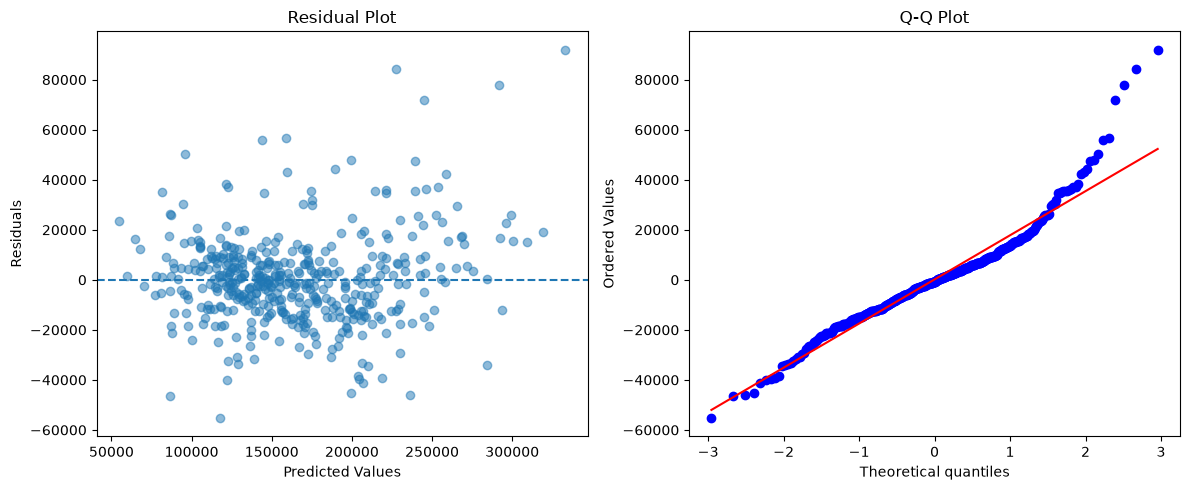

In [1103]:
plot_residuals_qq(en, X_test_scaled, y_test)

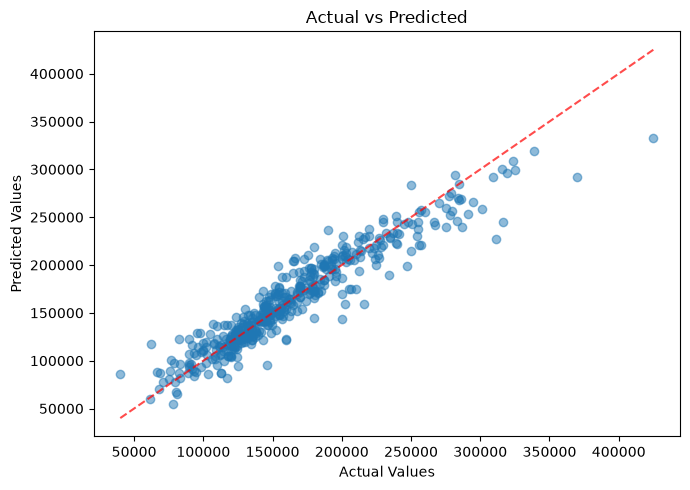

In [1104]:
plot_actual_vs_predicted(en, X_test_scaled, y_test)

## ElasticNet Regression Results

| Metric |          Train |           Test |
| ------ | -------------: | -------------: |
| MAE    |      12,107.84 |      12,845.88 |
| MSE    | 292,529,651.85 | 327,737,548.93 |
| RMSE   |      17,103.50 |      18,103.52 |
| R²     |         0.9168 |         0.8946 |

ElasticNet performed worse than Linear Regression, Ridge Regression, and Lasso Regression on the test set.


---------------------------------------------

# **tree**

In [1105]:
tree = DecisionTreeRegressor(max_depth=7, min_samples_split=2)

tree.fit(X_train_scaled, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [1106]:
y_pred_tree = tree.predict(X_test_scaled)

In [1107]:
results_tree = evaluate_model(tree, X_train_scaled, X_test_scaled, y_train, y_test)
results_tree

Train Metrics
MAE:  12,195.74
MSE:  268,389,953.92
RMSE: 16,382.61
R²:   0.9236

Test Metrics
MAE:  18,362.01
MSE:  620,835,839.00
RMSE: 24,916.58
R²:   0.8004


{'Train': {'MAE': 12195.739134235695,
  'MSE': 268389953.9214329,
  'RMSE': np.float64(16382.611327912071),
  'R²': 0.9236464145505299},
 'Test': {'MAE': 18362.014102391284,
  'MSE': 620835838.9960811,
  'RMSE': np.float64(24916.57759396505),
  'R²': 0.8003799750393653}}

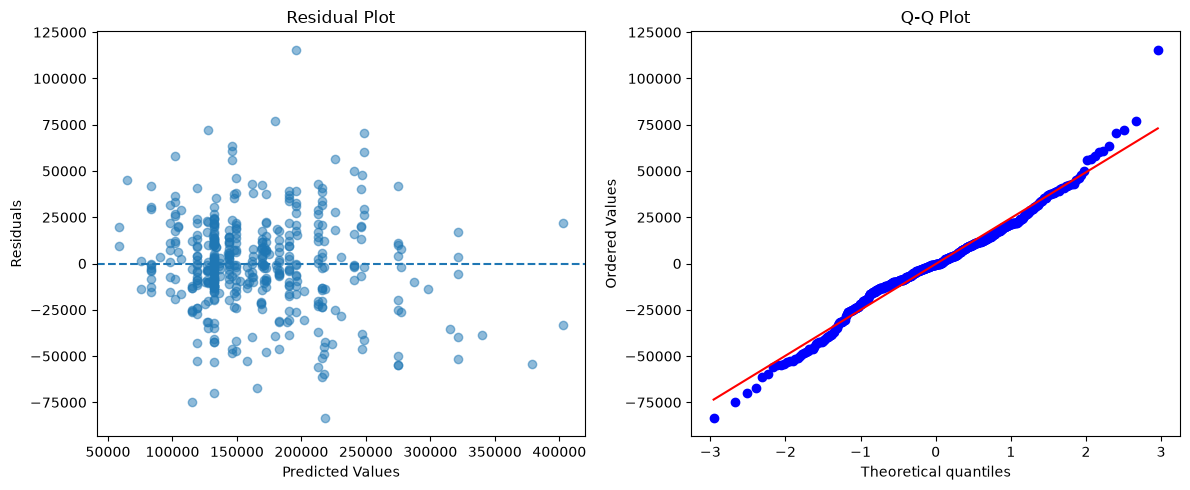

In [1108]:
plot_residuals_qq(tree, X_test_scaled, y_test)

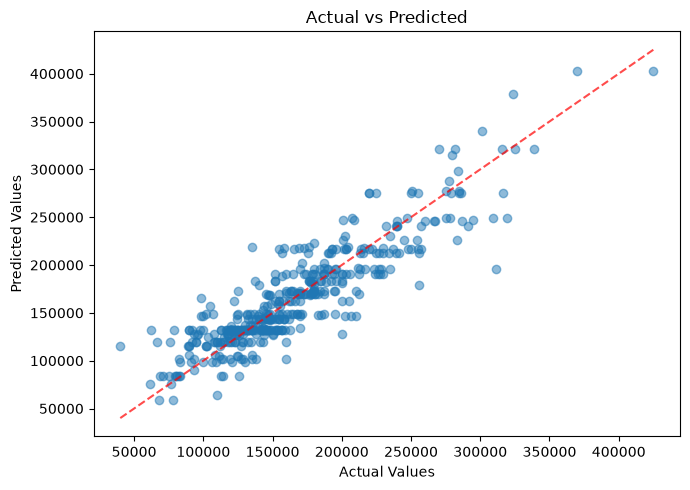

In [1109]:
plot_actual_vs_predicted(tree, X_test_scaled, y_test)

## Decision Tree Regression Results

| Metric |          Train |           Test |
| ------ | -------------: | -------------: |
| MAE    |      12,195.74 |      18,676.72 |
| MSE    | 268,389,953.92 | 656,557,287.23 |
| RMSE   |      16,382.61 |      25,623.37 |
| R²     |         0.9236 |         0.7889 |

The Decision Tree shows a noticeable performance gap between the training and test sets, indicating **overfitting**.


------------------------------------

# **Random Forest**

In [1110]:
rf = RandomForestRegressor(n_estimators=1000, max_depth=7, min_samples_leaf=20, n_jobs=-1)

rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [1111]:
y_pred_rf = rf.predict(X_test_scaled)

In [1112]:
results_rf = evaluate_model(rf, X_train_scaled, X_test_scaled, y_train, y_test)
results_rf

Train Metrics
MAE:  12,921.25
MSE:  360,653,975.88
RMSE: 18,990.89
R²:   0.8974

Test Metrics
MAE:  15,613.04
MSE:  477,094,808.40
RMSE: 21,842.50
R²:   0.8466


{'Train': {'MAE': 12921.249183489777,
  'MSE': 360653975.88051176,
  'RMSE': np.float64(18990.89191903613),
  'R²': 0.897398454142047},
 'Test': {'MAE': 15613.041963107451,
  'MSE': 477094808.39707243,
  'RMSE': np.float64(21842.500049148963),
  'R²': 0.8465976485590517}}

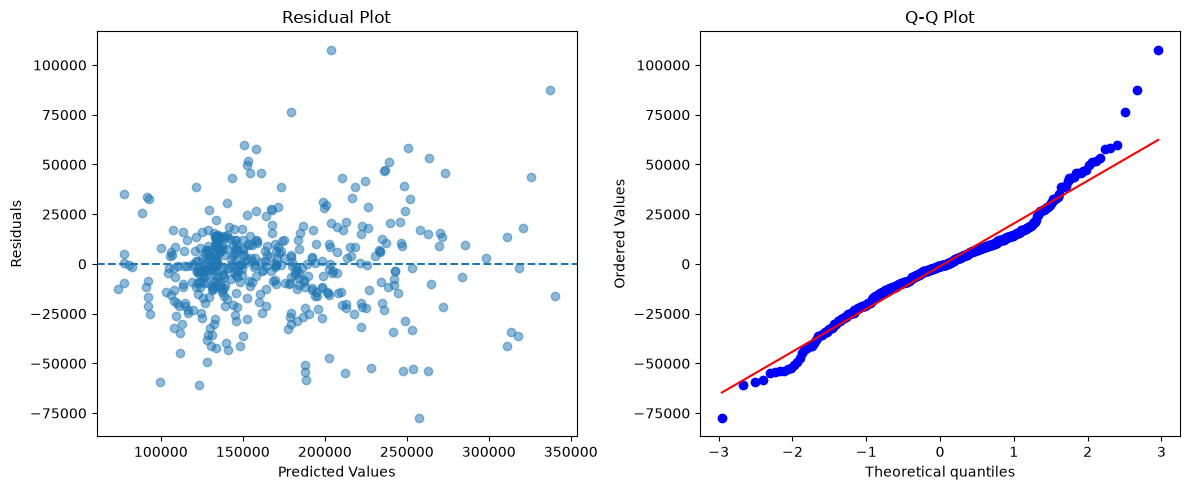

In [1113]:
plot_residuals_qq(rf, X_test_scaled, y_test)

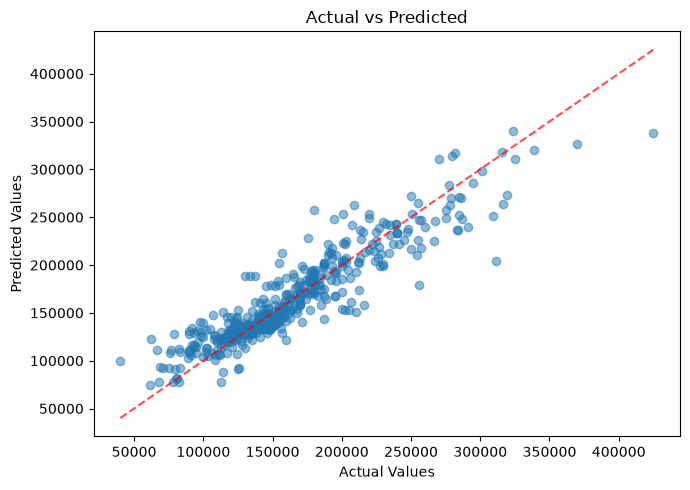

In [1114]:
plot_actual_vs_predicted(rf, X_test_scaled, y_test)

## Random Forest Regression Results

| Metric |          Train |           Test |
| ------ | -------------: | -------------: |
| MAE    |      12,963.37 |      15,665.40 |
| MSE    | 362,366,800.51 | 480,184,601.81 |
| RMSE   |      19,035.93 |      21,913.11 |
| R²     |         0.8969 |         0.8456 |

Random Forest shows better generalization than the Decision Tree, with a smaller Train-Test performance gap.


---------------------------------

# **Gradient Boosting**

In [1115]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [1116]:
y_pred_gb = gb.predict(X_test_scaled)

In [1117]:
results_gb = evaluate_model(gb, X_train_scaled, X_test_scaled, y_train, y_test)
results_gb

Train Metrics
MAE:  8,734.99
MSE:  137,223,655.42
RMSE: 11,714.25
R²:   0.9610

Test Metrics
MAE:  11,539.38
MSE:  260,193,595.17
RMSE: 16,130.52
R²:   0.9163


{'Train': {'MAE': 8734.992589797042,
  'MSE': 137223655.42188612,
  'RMSE': np.float64(11714.25010070581),
  'R²': 0.9609615861292231},
 'Test': {'MAE': 11539.384364122647,
  'MSE': 260193595.17492586,
  'RMSE': np.float64(16130.51751106969),
  'R²': 0.9163388311354496}}

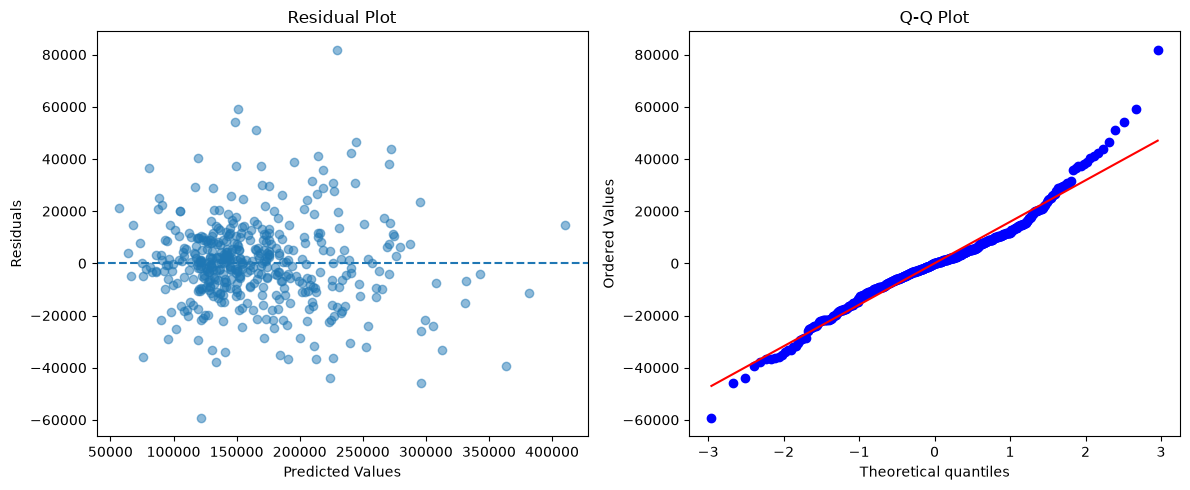

In [1118]:
plot_residuals_qq(gb, X_test_scaled, y_test)

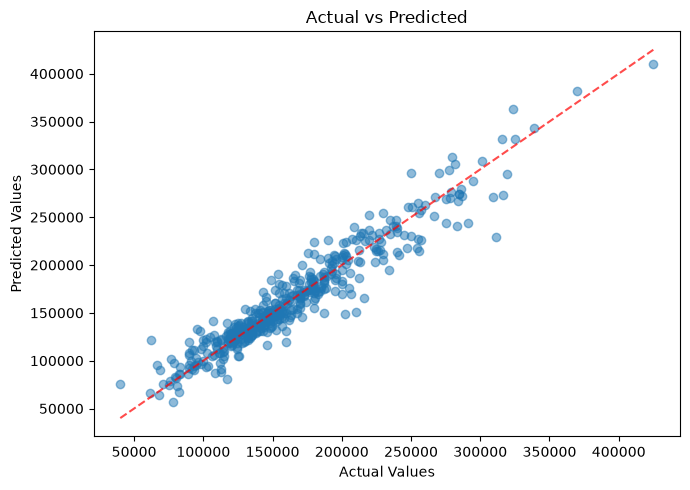

In [1119]:
plot_actual_vs_predicted(gb, X_test_scaled, y_test)

## Gradient Boosting Regression Results

| Metric |          Train |           Test |
| ------ | -------------: | -------------: |
| MAE    |       8,734.99 |      11,539.38 |
| MSE    | 137,223,655.42 | 260,193,595.17 |
| RMSE   |      11,714.25 |      16,130.52 |
| R²     |         0.9610 |         0.9163 |

Gradient Boosting achieved the best test performance so far, with an **R² of 0.9163** and an **RMSE of 16,130.52**.


------------------------------------------------

# **AdaBoostRegressor**

In [1120]:
ada = AdaBoostRegressor(
    n_estimators=500,
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train_scaled, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",500
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [1121]:
y_pred_ada = ada.predict(X_test_scaled)

In [1122]:
results_ada = evaluate_model(ada, X_train_scaled, X_test_scaled, y_train, y_test)
results_ada

Train Metrics
MAE:  15,864.95
MSE:  407,105,712.49
RMSE: 20,176.86
R²:   0.8842

Test Metrics
MAE:  17,324.35
MSE:  503,581,273.44
RMSE: 22,440.62
R²:   0.8381


{'Train': {'MAE': 15864.945318485055,
  'MSE': 407105712.49216455,
  'RMSE': np.float64(20176.860818575435),
  'R²': 0.8841835159939061},
 'Test': {'MAE': 17324.34592136705,
  'MSE': 503581273.4394061,
  'RMSE': np.float64(22440.616601141024),
  'R²': 0.838081341218581}}

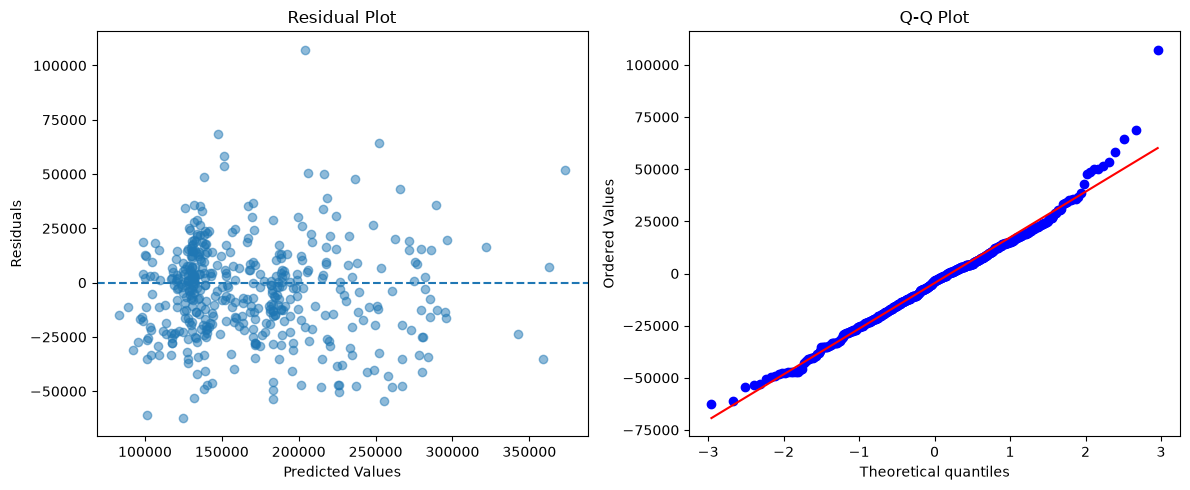

In [1123]:
plot_residuals_qq(ada, X_test_scaled, y_test)

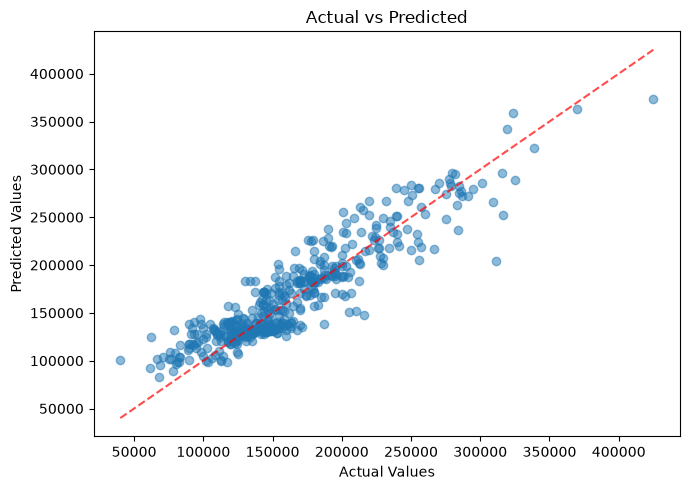

In [1124]:

plot_actual_vs_predicted(ada, X_test_scaled, y_test)

## AdaBoost Regression Results

| Metric |          Train |           Test |
| ------ | -------------: | -------------: |
| MAE    |      15,864.95 |      17,324.35 |
| MSE    | 407,105,712.49 | 503,581,273.44 |
| RMSE   |      20,176.86 |      22,440.62 |
| R²     |         0.8842 |         0.8381 |

AdaBoost achieved lower test performance compared with the previously evaluated models. The model obtained an **R² of 0.8381** and an **RMSE of 22,440.62** on the test set.

Although the difference between training and test performance is relatively moderate, the overall predictive performance is weaker than **Gradient Boosting**, which currently provides the best results among the evaluated models.


------------------------------------------

# **HistGradientBoostingRegressor**

In [1125]:
hgb = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

hgb.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 

In [1126]:
y_pred_hgb = hgb.predict(X_test_scaled)

In [1127]:
results_hgb = evaluate_model(hgb, X_train_scaled, X_test_scaled, y_train, y_test)
results_hgb

Train Metrics
MAE:  4,419.95
MSE:  40,746,750.05
RMSE: 6,383.32
R²:   0.9884

Test Metrics
MAE:  11,310.53
MSE:  243,471,634.90
RMSE: 15,603.58
R²:   0.9217


{'Train': {'MAE': 4419.951434359834,
  'MSE': 40746750.05423907,
  'RMSE': np.float64(6383.318106928329),
  'R²': 0.988408059181808},
 'Test': {'MAE': 11310.526270518038,
  'MSE': 243471634.89613634,
  'RMSE': np.float64(15603.577631304186),
  'R²': 0.9217155151452523}}

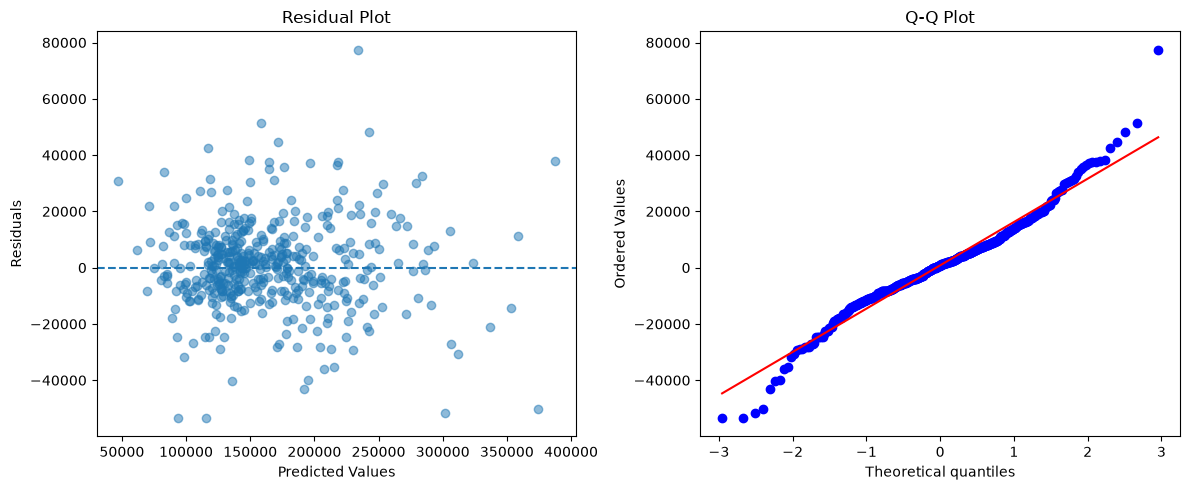

In [1128]:
plot_residuals_qq(hgb, X_test_scaled, y_test)

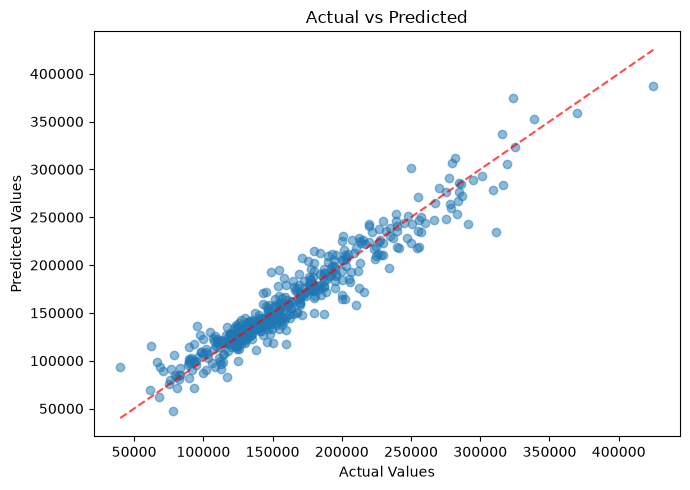

In [1129]:
plot_actual_vs_predicted(hgb, X_test_scaled, y_test)

## HistGradientBoosting Regression Results

| Metric |         Train |           Test |
| ------ | ------------: | -------------: |
| MAE    |      4,419.95 |      11,310.53 |
| MSE    | 40,746,750.05 | 243,471,634.90 |
| RMSE   |      6,383.32 |      15,603.58 |
| R²     |        0.9884 |         0.9217 |

HistGradientBoosting achieved the **best test performance so far**, with an **R² of 0.9217** and an **RMSE of 15,603.58**.

The model performs substantially better on the training set than on the test set, indicating a noticeable degree of **overfitting**. However, its test performance is still stronger than the previously evaluated models.


-----------------------------

# **knn**

In [1130]:
knn = KNeighborsRegressor(
    n_neighbors=5,
    weights='distance',
    p=2
)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [1131]:
t_pred_knn = knn.predict(X_test_scaled)

In [1132]:
results_knn = evaluate_model(knn, X_train_scaled, X_test_scaled, y_train, y_test)
results_knn

Train Metrics
MAE:  0.00
MSE:  0.00
RMSE: 0.00
R²:   1.0000

Test Metrics
MAE:  19,128.47
MSE:  752,560,372.26
RMSE: 27,432.83
R²:   0.7580


{'Train': {'MAE': 0.0012097534074316336,
  'MSE': 9.102213743929538e-06,
  'RMSE': np.float64(0.0030169875279704985),
  'R²': 0.9999999999999974},
 'Test': {'MAE': 19128.47225231248,
  'MSE': 752560372.2619619,
  'RMSE': np.float64(27432.833835788126),
  'R²': 0.7580260177340283}}

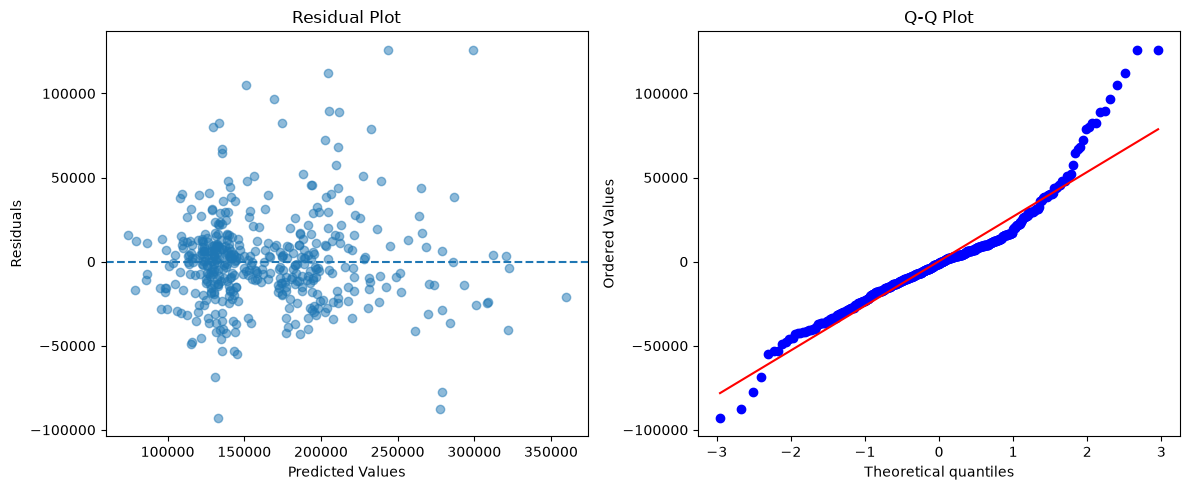

In [1133]:
plot_residuals_qq(knn, X_test_scaled, y_test)

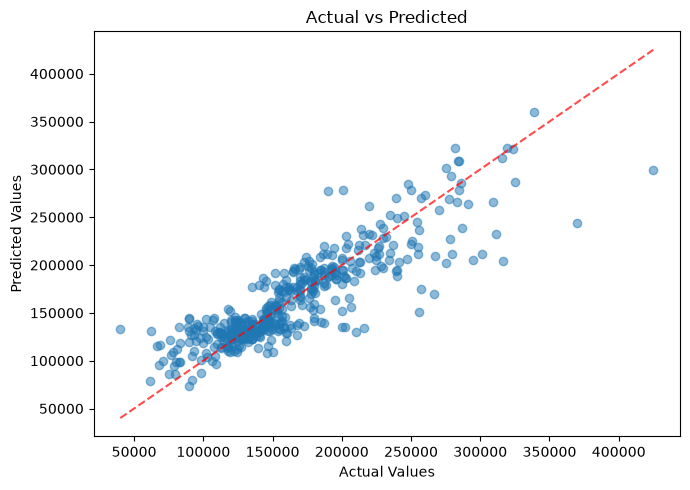

In [1134]:
plot_actual_vs_predicted(knn, X_test_scaled, y_test)

## KNN Regression Results

| Metric |  Train |           Test |
| ------ | -----: | -------------: |
| MAE    | 0.0012 |      19,128.47 |
| MSE    |   9.10 | 752,560,372.26 |
| RMSE   | 0.0030 |      27,432.83 |
| R²     | 1.0000 |         0.7580 |

KNN achieved an almost perfect performance on the training set, with an **R² of 1.0000**. However, its performance dropped significantly on the test set, where the **R² decreased to 0.7580** and the **RMSE increased to 27,432.83**.

This large gap between training and test performance indicates **severe overfitting**. Therefore, KNN does not generalize well to the current dataset and is not considered a strong candidate for the final model.


---------------------------------

In [1135]:
results = {
    'Linear Regression': results_linear,
    'Ridge': results_ridge,
    'Lasso': results_lasso,
    'ElasticNet': results_elasticnet,
    'Decision Tree': results_tree,
    'Random Forest': results_rf,
    'Gradient Boosting': results_gb,
    'HistGradientBoosting': results_hgb,
    'AdaBoost': results_ada,
    'KNN': results_knn
}

In [1136]:
comparison = []

for model_name, result in results.items():

    train = result['Train']
    test = result['Test']

    comparison.append({
        'Model': model_name,

        'Train MAE': train['MAE'],
        'Test MAE': test['MAE'],
        'MAE Gap': abs(train['MAE'] - test['MAE']),

        'Train RMSE': train['RMSE'],
        'Test RMSE': test['RMSE'],
        'RMSE Gap': abs(train['RMSE'] - test['RMSE']),

        'Train R²': train['R²'],
        'Test R²': test['R²'],
        'R² Gap': abs(train['R²'] - test['R²'])
    })

comparison_df = pd.DataFrame(comparison)

comparison_df.sort_values(
    by='Test R²',
    ascending=False
)

,Model,Train MAE,Test MAE,MAE Gap,Train RMSE,Test RMSE,RMSE Gap,Train R²,Test R²,R² Gap
7,HistGradientBoosting,4419.951434,11310.526271,6890.574836,6383.318107,15603.577631,9220.259524,0.988408,0.921716,0.066693
6,Gradient Boosting,8734.992590,11539.384364,2804.391774,11714.250101,16130.517511,4416.267410,0.960962,0.916339,0.044623
2,Lasso,11005.392980,12399.331508,1393.938527,15107.125727,16944.243943,1837.118216,0.935073,0.907685,0.027388
1,Ridge,11005.367044,12402.646094,1397.279049,15107.237459,16947.379769,1840.142310,0.935072,0.907651,0.027421
0,Linear Regression,11005.554857,12409.074670,1403.519812,15107.033789,16953.106502,1846.072712,0.935074,0.907589,0.027485
3,ElasticNet,12107.842072,12845.876762,738.034690,17103.498234,18103.523108,1000.024874,0.916779,0.894621,0.022158
5,Random Forest,12921.249183,15613.041963,2691.792780,18990.891919,21842.500049,2851.608130,0.897398,0.846598,0.050801
8,AdaBoost,15864.945318,17324.345921,1459.400603,20176.860819,22440.616601,2263.755783,0.884184,0.838081,0.046102
4,Decision Tree,12195.739134,18362.014102,6166.274968,16382.611328,24916.577594,8533.966266,0.923646,0.800380,0.123266
9,KNN,0.001210,19128.472252,19128.471043,0.003017,27432.833836,27432.830819,1.000000,0.758026,0.241974


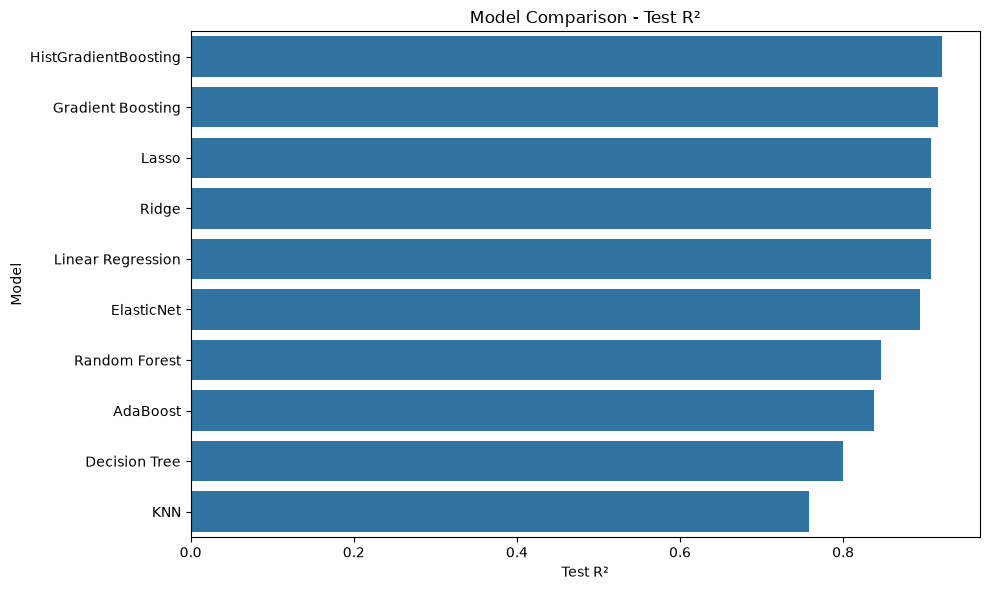

In [1137]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_df.sort_values('Test R²', ascending=False),
    x='Test R²',
    y='Model'
)

plt.title('Model Comparison - Test R²')
plt.xlabel('Test R²')
plt.ylabel('Model')

plt.tight_layout()
plt.show()

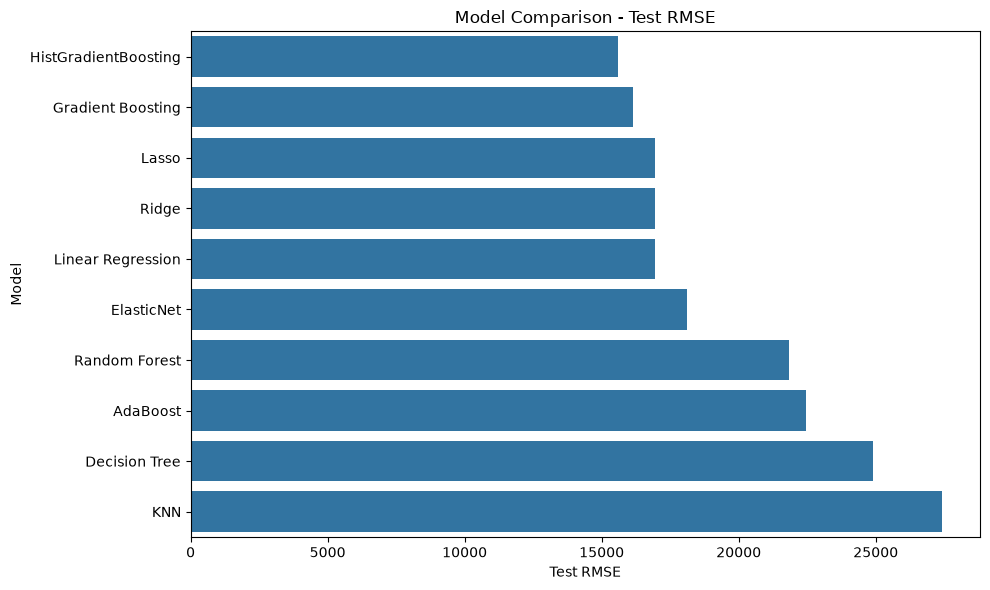

In [1138]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_df.sort_values('Test RMSE'),
    x='Test RMSE',
    y='Model'
)

plt.title('Model Comparison - Test RMSE')
plt.xlabel('Test RMSE')
plt.ylabel('Model')

plt.tight_layout()
plt.show()

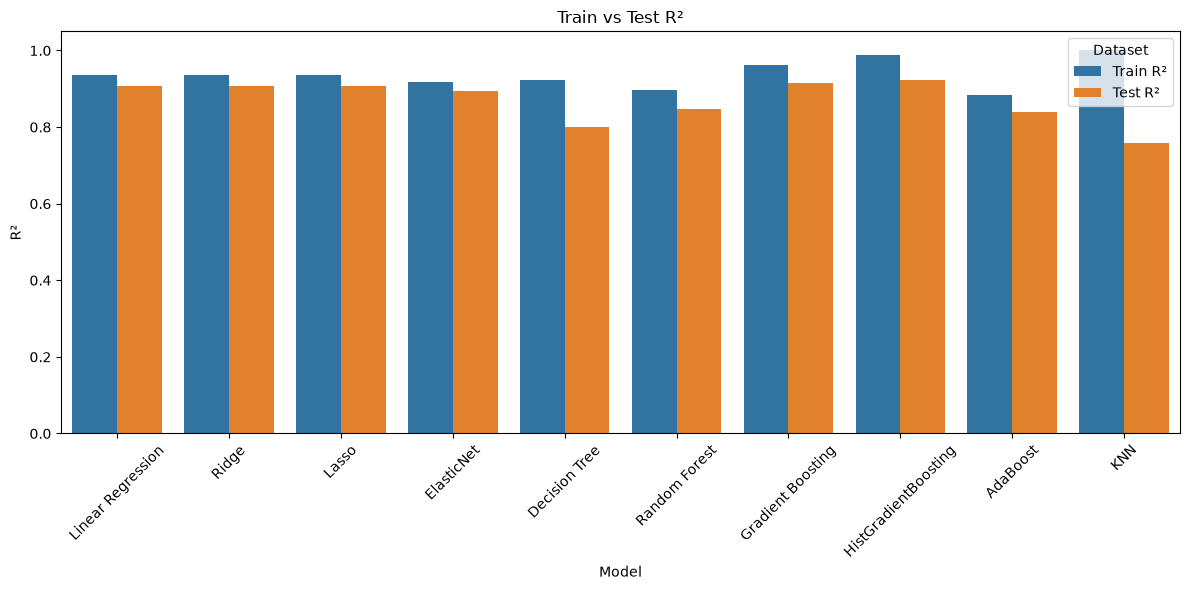

In [1139]:
r2_plot = comparison_df.melt(
    id_vars='Model',
    value_vars=['Train R²', 'Test R²'],
    var_name='Dataset',
    value_name='R²'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=r2_plot,
    x='Model',
    y='R²',
    hue='Dataset'
)

plt.title('Train vs Test R²')
plt.xlabel('Model')
plt.ylabel('R²')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

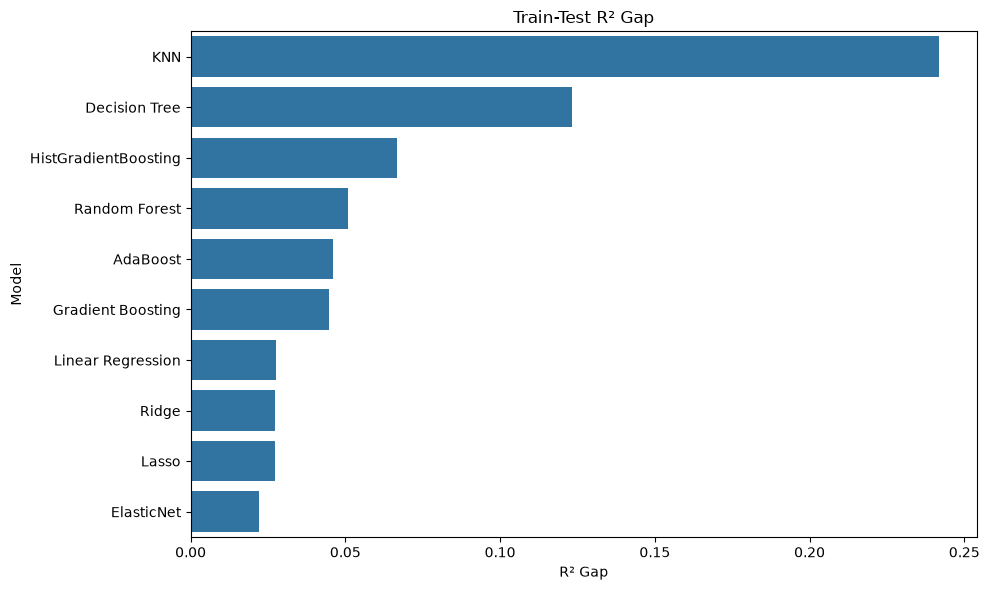

In [1140]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_df.sort_values('R² Gap', ascending=False),
    x='R² Gap',
    y='Model'
)

plt.title('Train-Test R² Gap')
plt.xlabel('R² Gap')
plt.ylabel('Model')

plt.tight_layout()
plt.show()

## Baseline Model Comparison

The regression models were compared using **MAE, RMSE, and R²** on both the training and test sets. The Train-Test gaps were also analyzed to evaluate model generalization and identify potential overfitting.

### Best Test Performance

**HistGradientBoosting** achieved the best overall test performance:

* **Test MAE:** 11,310.53
* **Test RMSE:** 15,603.58
* **Test R²:** 0.9217

**Gradient Boosting** achieved the second-best test performance:

* **Test MAE:** 11,539.38
* **Test RMSE:** 16,130.52
* **Test R²:** 0.9163

These results indicate that boosting-based models are particularly effective for predicting `Sale_Price`.

### Best Generalization

When considering the **R² Gap** between training and test sets, **ElasticNet** showed the smallest gap among the evaluated models:

* **ElasticNet R² Gap:** 0.0222
* **Lasso R² Gap:** 0.0274

The relatively small gaps indicate that these models generalize more consistently between the training and test data.

However, lower overfitting alone does not necessarily mean better predictive performance. ElasticNet and Lasso achieved lower test R² values than the boosting models.

### Models Selected for Further Evaluation

Based on both predictive performance and generalization, four models were selected as candidates for the next stage:

* **HistGradientBoosting** — Best overall test performance
* **Gradient Boosting** — Second-best test performance
* **ElasticNet** — Smallest R² gap
* **Lasso** — Strong performance with a small R² gap

This selection provides a balance between **high predictive performance** and **good generalization**.

### Conclusion

The baseline experiments show that **HistGradientBoosting is currently the strongest model**, while **Gradient Boosting** provides very similar performance with a smaller Train-Test gap.

On the other hand, **ElasticNet and Lasso demonstrate more stable generalization**, although their predictive performance is lower than the boosting models.

Therefore, these four models will be carried forward to the next stage, where **Cross-Validation and Hyperparameter Tuning** will be performed to determine whether their performance and generalization can be further improved.


----------------------

# **GridSearchCV & Cross validation**

---

## **Cross validation**

In [1141]:
from sklearn.model_selection import KFold, cross_validate
import pandas as pd


def compare_models_cv(models, X, y, cv=5):

    kfold = KFold(
        n_splits=cv,
        shuffle=True,
        random_state=42
    )

    results = []

    for name, model in models:

        scores = cross_validate(
            model,
            X,
            y,
            cv=kfold,
            scoring={
                'MAE': 'neg_mean_absolute_error',
                'RMSE': 'neg_root_mean_squared_error',
                'R2': 'r2'
            },
            return_train_score=True
        )

        results.append({
            'Model': name,

            'Train MAE': -scores['train_MAE'].mean(),
            'Test MAE': -scores['test_MAE'].mean(),

            'Train RMSE': -scores['train_RMSE'].mean(),
            'Test RMSE': -scores['test_RMSE'].mean(),

            'Train R²': scores['train_R2'].mean(),
            'Test R²': scores['test_R2'].mean(),

            'R² Gap': (
                scores['train_R2'].mean()
                - scores['test_R2'].mean()
            )
        })

    results_df = pd.DataFrame(results)

    return results_df.sort_values(
        by='Test R²',
        ascending=False
    ).reset_index(drop=True)

In [1142]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('ElasticNet', ElasticNet()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42)),
    ('HistGradientBoosting', HistGradientBoostingRegressor(random_state=42)),
    ('AdaBoost', AdaBoostRegressor(random_state=42)),
    ('KNN', KNeighborsRegressor())
]

In [1143]:
cv_results = compare_models_cv(
    models,
    X_train_scaled,
    y_train
)

C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.922e+09, tolerance: 5.102e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.001e+10, tolerance: 4.909e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

In [1144]:
cv_results

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²,R² Gap
0,HistGradientBoosting,3887.739756,11775.961831,5771.672113,17133.334278,0.990501,0.915547,0.074954
1,Gradient Boosting,8401.938963,11955.785664,11121.418119,17402.359490,0.964785,0.913080,0.051705
2,Ridge,10838.404388,13116.626964,14818.795727,18318.237308,0.937488,0.903146,0.034342
3,Lasso,10838.351893,13119.378318,14818.492005,18319.583756,0.937491,0.903132,0.034358
4,Linear Regression,10837.737174,13129.021279,14818.364874,18340.638747,0.937492,0.902902,0.034590
5,ElasticNet,11979.453045,13172.864550,16910.243744,18876.345419,0.918589,0.897474,0.021114
6,Random Forest,4919.120936,12954.199861,7228.289758,18973.394793,0.985118,0.896345,0.088773
7,AdaBoost,15734.466887,17094.775631,19874.385584,23083.049142,0.887562,0.846509,0.041053
8,KNN,16246.119180,19779.753548,23228.163015,28187.446723,0.846450,0.772453,0.073997
9,Decision Tree,-0.000000,20208.861538,-0.000000,28428.284672,1.000000,0.767966,0.232034


## Cross-Validation Results

Five-fold cross-validation was performed to evaluate the generalization performance of the regression models using multiple validation folds.

The models were compared using **MAE, RMSE, and R²**. The difference between training and validation R² was also examined to identify potential overfitting.

### Best Validation Performance

`HistGradientBoosting` achieved the highest mean validation performance:

* **Test MAE:** 11,775.96
* **Test RMSE:** 17,133.33
* **Test R²:** 0.9155
* **R² Gap:** 0.0750

`Gradient Boosting` achieved a very similar validation performance:

* **Test MAE:** 11,955.79
* **Test RMSE:** 17,402.36
* **Test R²:** 0.9131
* **R² Gap:** 0.0517

### Generalization

`ElasticNet` showed the smallest Train-Test R² gap:

* **R² Gap:** 0.0211

This indicates more consistent generalization across the training and validation folds, although its predictive performance was lower than the two boosting models.

`Decision Tree` showed the largest R² gap of **0.2320**, indicating substantial overfitting.

### Conclusion

The cross-validation results confirm that the boosting-based models provide the strongest predictive performance, while the regularized linear models show more stable generalization.

Based on the validation results, the following models will be considered for further optimization:

* **HistGradientBoosting**
* **Gradient Boosting**
* **ElasticNet**
* **Lasso**
* **Ridge**

The next stage will focus on **hyperparameter optimization using GridSearchCV** to determine whether the selected models can achieve improved performance and generalization.


----

## **GridSearchCV**

### linear

In [1145]:
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid={
    'fit_intercept': [True, False],
    'positive': [True, False]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1146]:
grid_lr.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'fit_intercept': [True, False], 'positive': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold a

In [1147]:
print(grid_lr.best_score_)
print(grid_lr.best_estimator_)
print(grid_lr.best_params_)
print(grid_lr.best_index_)

0.9045952717224933
LinearRegression()
{'fit_intercept': True, 'positive': False}
1


### ridge

In [1148]:
grid_rd = GridSearchCV(
    estimator=rd,
    param_grid={
    'alpha': [0.01, 0.1, 1.0, 10, 100],
    'fit_intercept': [True, False]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1149]:
grid_rd.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge(alpha=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...], 'fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and c

In [1150]:
print(grid_rd.best_score_)
print(grid_rd.best_estimator_)
print(grid_rd.best_params_)
print(grid_rd.best_index_)

0.9064433367238115
Ridge(alpha=100)
{'alpha': 100, 'fit_intercept': True}
8


### Lasso

In [1151]:
grid_ls = GridSearchCV(
    estimator=ls,
    param_grid={
    'alpha': [0.001, 0.01, 0.1, 1.0, 10],
    'fit_intercept': [True, False],
    'max_iter': [5000, 10000]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1152]:
grid_ls.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso(alpha=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'fit_intercept': [True, False], 'max_iter': [5000, 10000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also di

In [1153]:
print(grid_ls.best_score_)
print(grid_ls.best_estimator_)
print(grid_ls.best_params_)
print(grid_ls.best_index_)

0.9057250676460342
Lasso(alpha=10, max_iter=5000)
{'alpha': 10, 'fit_intercept': True, 'max_iter': 5000}
16


### ElasticNet

In [1154]:
grid_en = GridSearchCV(
    estimator=en,
    param_grid={
    'alpha': [0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8],
    'max_iter': [5000, 10000]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1155]:
grid_en.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet(alpha=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'l1_ratio': [0.2, 0.5, ...], 'max_iter': [5000, 10000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

In [1156]:
print(grid_en.best_score_)
print(grid_en.best_estimator_)
print(grid_en.best_params_)
print(grid_en.best_index_)

0.906489957198577
ElasticNet(alpha=0.1, max_iter=5000)
{'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 5000}
14


### Decision Tree

In [1157]:
grid_tree = GridSearchCV(
    estimator=tree,
    param_grid={
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1158]:
grid_tree.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...r(max_depth=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [1159]:
print(grid_tree.best_score_)
print(grid_tree.best_estimator_)
print(grid_tree.best_params_)
print(grid_tree.best_index_)

0.7865929796735489
DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10)
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
62


### Random Forest

In [1160]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid={
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 1.0]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1161]:
grid_rf.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR... n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 1.0], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [1162]:
print(grid_rf.best_score_)
print(grid_rf.best_estimator_)
print(grid_rf.best_params_)
print(grid_rf.best_index_)

0.8926992378490217
RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, n_jobs=-1)
{'max_depth': 20, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
47


### Gradient Boosting

In [1163]:
grid_gb = GridSearchCV(
    estimator=gb,
    param_grid={
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1164]:
grid_gb.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3], 'min_samples_leaf': [1, 2], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [1165]:
print(grid_gb.best_score_)
print(grid_gb.best_estimator_)
print(grid_gb.best_params_)
print(grid_gb.best_index_)

0.9176187892514529
GradientBoostingRegressor(n_estimators=200, random_state=42, subsample=0.8)
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 200, 'subsample': 0.8}
26


### HistGradientBoosting

In [1166]:
grid_hgb = GridSearchCV(
    estimator=hgb,
    param_grid={
    'max_iter': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_leaf_nodes': [15, 31],
    'max_depth': [None, 10],
    'l2_regularization': [0, 1]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1167]:
grid_hgb.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'l2_regularization': [0, 1], 'learning_rate': [0.05, 0.1], 'max_depth': [None, 10], 'max_iter': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [1168]:
print(grid_hgb.best_score_)
print(grid_hgb.best_estimator_)
print(grid_hgb.best_params_)
print(grid_hgb.best_index_)

0.9171733907606425
HistGradientBoostingRegressor(l2_regularization=0, learning_rate=0.05,
                              max_depth=10, max_iter=200, max_leaf_nodes=15,
                              random_state=42)
{'l2_regularization': 0, 'learning_rate': 0.05, 'max_depth': 10, 'max_iter': 200, 'max_leaf_nodes': 15}
6


### AdaBoost

In [1169]:
grid_ada = GridSearchCV(
    estimator=ada,
    param_grid={
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1170]:
grid_ada.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [1171]:
print(grid_ada.best_score_)
print(grid_ada.best_estimator_)
print(grid_ada.best_params_)
print(grid_ada.best_index_)

0.8533509562557086
AdaBoostRegressor(learning_rate=0.5, n_estimators=200, random_state=42)
{'learning_rate': 0.5, 'n_estimators': 200}
11


### KNN

In [1172]:
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid={
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [1173]:
grid_knn.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsReg...ts='distance')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [1174]:
print(grid_knn.best_score_)
print(grid_knn.best_estimator_)
print(grid_knn.best_params_)
print(grid_knn.best_index_)

0.8278621538173541
KNeighborsRegressor(p=1, weights='distance')
{'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
5


-------------

In [1175]:
def gridsearch_results(grids):

    results = []

    for name, grid in grids:

        results.append({
            'Model': name,
            'Best CV R²': grid.best_score_
        })

    return pd.DataFrame(results).sort_values(
        by='Best CV R²'
    ).reset_index(drop=True)

In [1176]:
grids = [
    ('Linear Regression', grid_lr),
    ('Ridge', grid_rd),
    ('Lasso', grid_ls),
    ('ElasticNet', grid_en),
    ('Decision Tree', grid_tree),
    ('Random Forest', grid_rf),
    ('Gradient Boosting', grid_gb),
    ('HistGradientBoosting', grid_hgb),
    ('AdaBoost', grid_ada),
    ('KNN', grid_knn)
]

grid_results = gridsearch_results(grids)

grid_results.sort_values('Best CV R²', ascending=False)

,Model,Best CV R²
9,Gradient Boosting,0.917619
8,HistGradientBoosting,0.917173
7,ElasticNet,0.906490
6,Ridge,0.906443
5,Lasso,0.905725
4,Linear Regression,0.904595
3,Random Forest,0.892699
2,AdaBoost,0.853351
1,KNN,0.827862
0,Decision Tree,0.786593


In [1177]:
best_models = [
    ('Linear Regression', grid_lr.best_estimator_),
    ('Ridge', grid_rd.best_estimator_),
    ('Lasso', grid_ls.best_estimator_),
    ('ElasticNet', grid_en.best_estimator_),
    ('Decision Tree', grid_tree.best_estimator_),
    ('Random Forest', grid_rf.best_estimator_),
    ('Gradient Boosting', grid_gb.best_estimator_),
    ('HistGradientBoosting', grid_hgb.best_estimator_),
    ('AdaBoost', grid_ada.best_estimator_),
    ('KNN', grid_knn.best_estimator_)
]

In [1178]:
test_results = []

for name, model in best_models:
    metrics = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    train_rmse = metrics["Train"]["RMSE"]
    test_rmse = metrics["Test"]["RMSE"]

    train_r2 = metrics["Train"]["R²"]
    test_r2 = metrics["Test"]["R²"]

    test_results.append({
        "Model": name,
        "Train MAE": metrics["Train"]["MAE"],
        "Test MAE": metrics["Test"]["MAE"],
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "RMSE Gap": test_rmse - train_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "R² Gap": train_r2 - test_r2
    })

test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.sort_values(
    by="Test RMSE",
    ascending=True
).reset_index(drop=True)

Train Metrics
MAE:  11,005.55
MSE:  228,222,469.92
RMSE: 15,107.03
R²:   0.9351

Test Metrics
MAE:  12,409.07
MSE:  287,407,820.06
RMSE: 16,953.11
R²:   0.9076
Train Metrics
MAE:  11,119.18
MSE:  234,303,572.77
RMSE: 15,306.98
R²:   0.9333

Test Metrics
MAE:  12,246.68
MSE:  286,151,666.22
RMSE: 16,916.02
R²:   0.9080
Train Metrics
MAE:  11,011.30
MSE:  228,356,136.91
RMSE: 15,111.46
R²:   0.9350

Test Metrics
MAE:  12,363.12
MSE:  285,905,333.09
RMSE: 16,908.74
R²:   0.9081
Train Metrics
MAE:  11,104.34
MSE:  233,505,263.80
RMSE: 15,280.88
R²:   0.9336

Test Metrics
MAE:  12,252.09
MSE:  285,763,761.43
RMSE: 16,904.55
R²:   0.9081
Train Metrics
MAE:  9,729.00
MSE:  186,742,925.82
RMSE: 13,665.39
R²:   0.9469

Test Metrics
MAE:  18,479.67
MSE:  648,393,495.10
RMSE: 25,463.57
R²:   0.7915
Train Metrics
MAE:  5,575.13
MSE:  76,492,991.05
RMSE: 8,746.03
R²:   0.9782

Test Metrics
MAE:  13,220.32
MSE:  335,873,951.03
RMSE: 18,326.86
R²:   0.8920
Train Metrics
MAE:  7,216.05
MSE:  86,903,71

In [1179]:
test_results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,RMSE Gap,Train R²,Test R²,R² Gap
0,Gradient Boosting,7216.049545,11302.608343,9322.216388,15652.862906,6330.646518,0.975277,0.921220,0.054057
1,HistGradientBoosting,6675.759117,11165.714215,9230.534620,15717.697829,6487.163209,0.975761,0.920566,0.055195
2,ElasticNet,11104.338058,12252.092959,15280.879026,16904.548543,1623.669517,0.933571,0.908117,0.025454
3,Lasso,11011.298146,12363.122042,15111.457140,16908.735408,1797.278267,0.935036,0.908072,0.026964
4,Ridge,11119.179715,12246.680824,15306.977911,16916.018037,1609.040126,0.933344,0.907992,0.025351
5,Linear Regression,11005.554857,12409.074670,15107.033789,16953.106502,1846.072712,0.935074,0.907589,0.027485
6,Random Forest,5575.132467,13220.315337,8746.027158,18326.864190,9580.837032,0.978239,0.892005,0.086234
7,AdaBoost,15704.091801,17365.349726,19918.776188,22482.758738,2563.982550,0.887127,0.837473,0.049655
8,KNN,0.000000,16304.958099,0.000000,23850.262038,23850.262038,1.000000,0.817100,0.182900
9,Decision Tree,9728.996468,18479.673733,13665.391536,25463.571923,11798.180388,0.946874,0.791519,0.155355


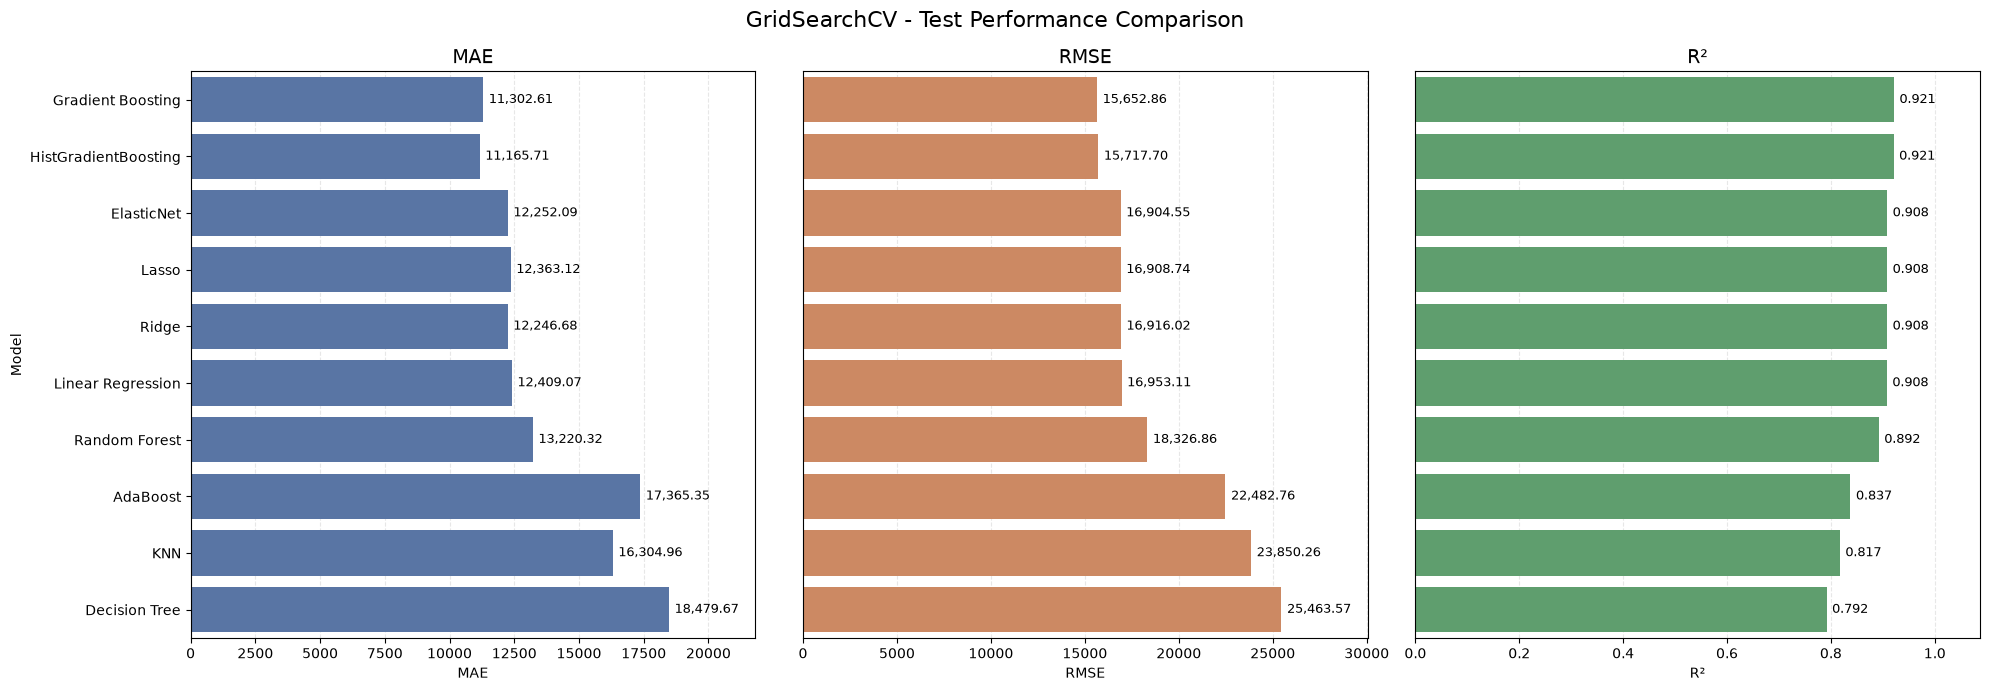

In [1180]:
fig, ax = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

metrics = [
    ('Test MAE', 'MAE'),
    ('Test RMSE', 'RMSE'),
    ('Test R²', 'R²')
]

for i, (column, title) in enumerate(metrics):
    sns.barplot(
        data=test_results_df,
        x=column,
        y='Model',
        ax=ax[i],
        color=sns.color_palette('deep')[i]
    )

    ax[i].set_title(title, fontsize=14)
    ax[i].set_xlabel(title)
    ax[i].set_ylabel('Model' if i == 0 else '')
    ax[i].grid(axis='x', linestyle='--', alpha=0.3)
    ax[i].set_axisbelow(True)

    for container in ax[i].containers:
        labels = []

        for bar in container:
            value = bar.get_width()

            if column == 'Test R²':
                labels.append(f'{value:.3f}')
            else:
                labels.append(f'{value:,.2f}')

        ax[i].bar_label(
            container,
            labels=labels,
            padding=4,
            fontsize=9
        )

    ax[i].margins(x=0.18)

    if i > 0:
        ax[i].tick_params(axis='y', left=False, labelleft=False)

plt.suptitle(
    'GridSearchCV - Test Performance Comparison',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [1181]:
best_models = {
    'Gradient Boosting': grid_gb.best_estimator_,
    'HistGradientBoosting': grid_hgb.best_estimator_,
    'ElasticNet': grid_en.best_estimator_
}

# ***show plot of test data***

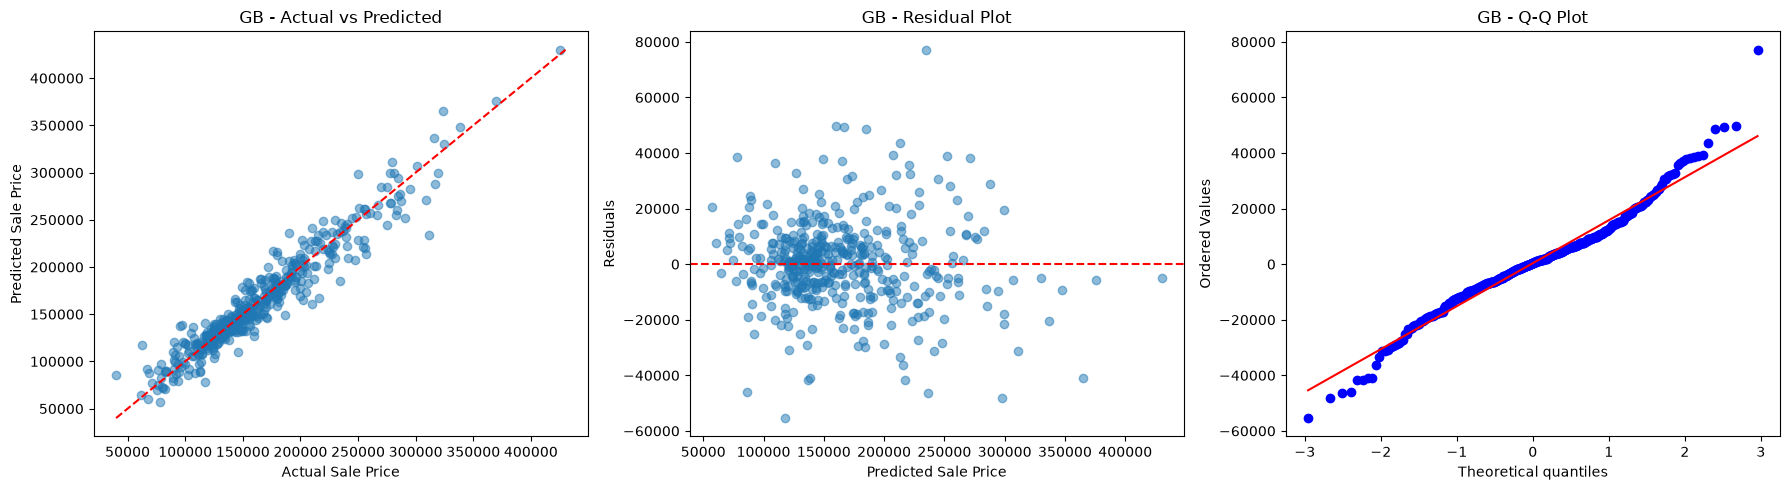

In [1182]:
import scipy.stats as stats

model = grid_gb.best_estimator_

X = X_test_scaled
y = y_test
y_pred = model.predict(X)
residuals = y - y_pred

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax[0].scatter(y, y_pred, alpha=0.5)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax[0].plot([min_val, max_val], [min_val, max_val], 'r--')
ax[0].set_title('GB - Actual vs Predicted')
ax[0].set_xlabel('Actual Sale Price')
ax[0].set_ylabel('Predicted Sale Price')

# Residual Plot
ax[1].scatter(y_pred, residuals, alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('GB - Residual Plot')
ax[1].set_xlabel('Predicted Sale Price')
ax[1].set_ylabel('Residuals')

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=ax[2])
ax[2].set_title('GB - Q-Q Plot')

plt.tight_layout()
plt.show()

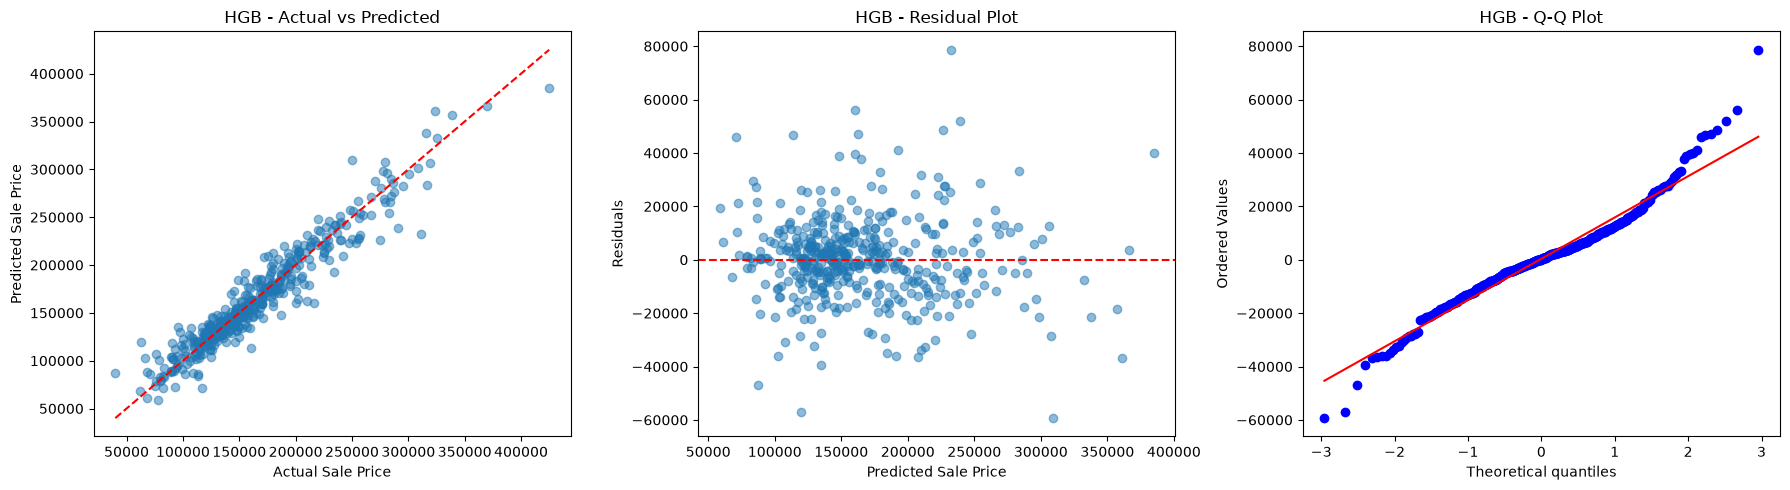

In [1183]:
model = grid_hgb.best_estimator_

X = X_test_scaled
y = y_test
y_pred = model.predict(X)
residuals = y - y_pred

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax[0].scatter(y, y_pred, alpha=0.5)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax[0].plot([min_val, max_val], [min_val, max_val], 'r--')
ax[0].set_title('HGB - Actual vs Predicted')
ax[0].set_xlabel('Actual Sale Price')
ax[0].set_ylabel('Predicted Sale Price')

# Residual Plot
ax[1].scatter(y_pred, residuals, alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('HGB - Residual Plot')
ax[1].set_xlabel('Predicted Sale Price')
ax[1].set_ylabel('Residuals')

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=ax[2])
ax[2].set_title('HGB - Q-Q Plot')

plt.tight_layout()
plt.show()

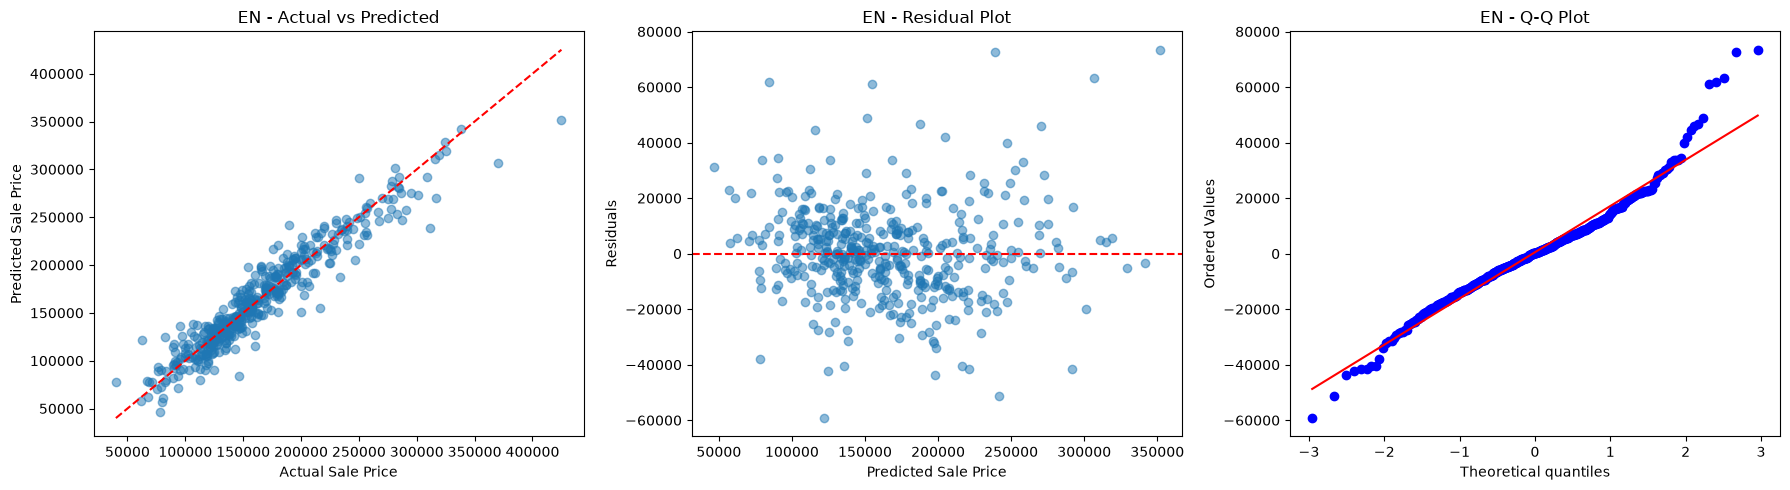

In [1184]:
model = grid_en.best_estimator_

X = X_test_scaled
y = y_test
y_pred = model.predict(X)
residuals = y - y_pred

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax[0].scatter(y, y_pred, alpha=0.5)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax[0].plot([min_val, max_val], [min_val, max_val], 'r--')
ax[0].set_title('EN - Actual vs Predicted')
ax[0].set_xlabel('Actual Sale Price')
ax[0].set_ylabel('Predicted Sale Price')

# Residual Plot
ax[1].scatter(y_pred, residuals, alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('EN - Residual Plot')
ax[1].set_xlabel('Predicted Sale Price')
ax[1].set_ylabel('Residuals')

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=ax[2])
ax[2].set_title('EN - Q-Q Plot')

plt.tight_layout()
plt.show()

# ***show plot of train data***

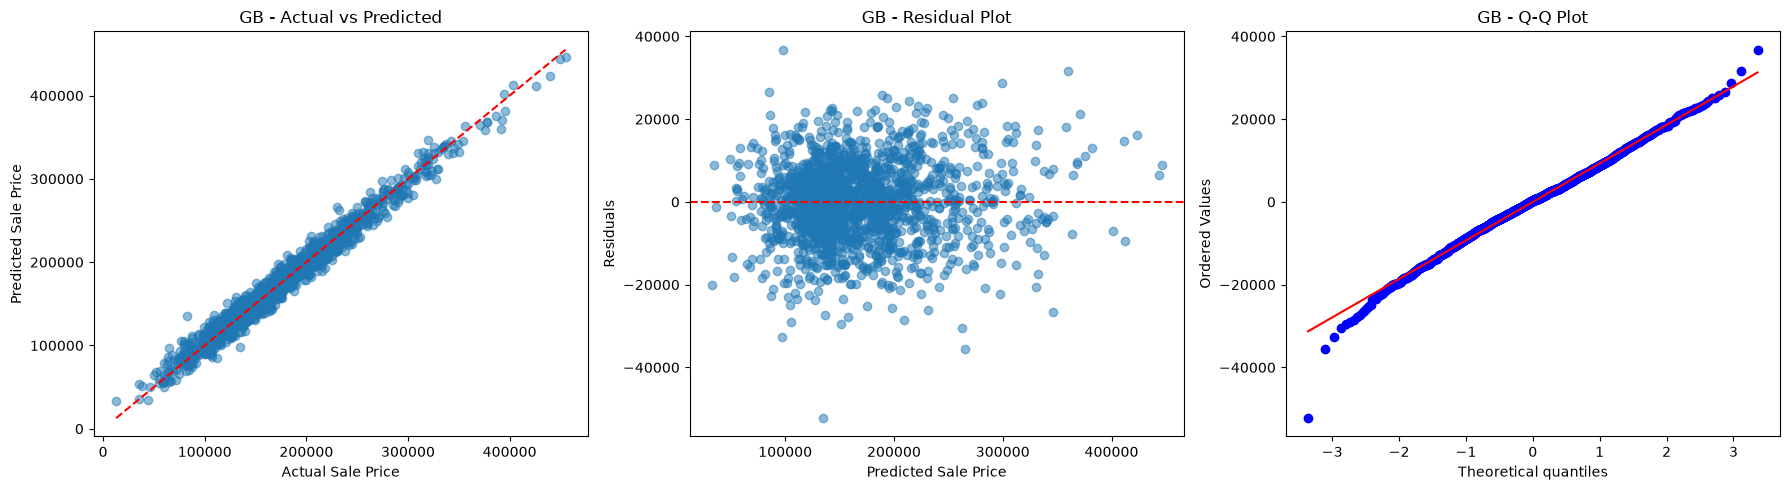

In [1185]:
import scipy.stats as stats

model = grid_gb.best_estimator_

X = X_train_scaled
y = y_train
y_pred = model.predict(X)
residuals = y - y_pred

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax[0].scatter(y, y_pred, alpha=0.5)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax[0].plot([min_val, max_val], [min_val, max_val], 'r--')
ax[0].set_title('GB - Actual vs Predicted')
ax[0].set_xlabel('Actual Sale Price')
ax[0].set_ylabel('Predicted Sale Price')

# Residual Plot
ax[1].scatter(y_pred, residuals, alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('GB - Residual Plot')
ax[1].set_xlabel('Predicted Sale Price')
ax[1].set_ylabel('Residuals')

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=ax[2])
ax[2].set_title('GB - Q-Q Plot')

plt.tight_layout()
plt.show()

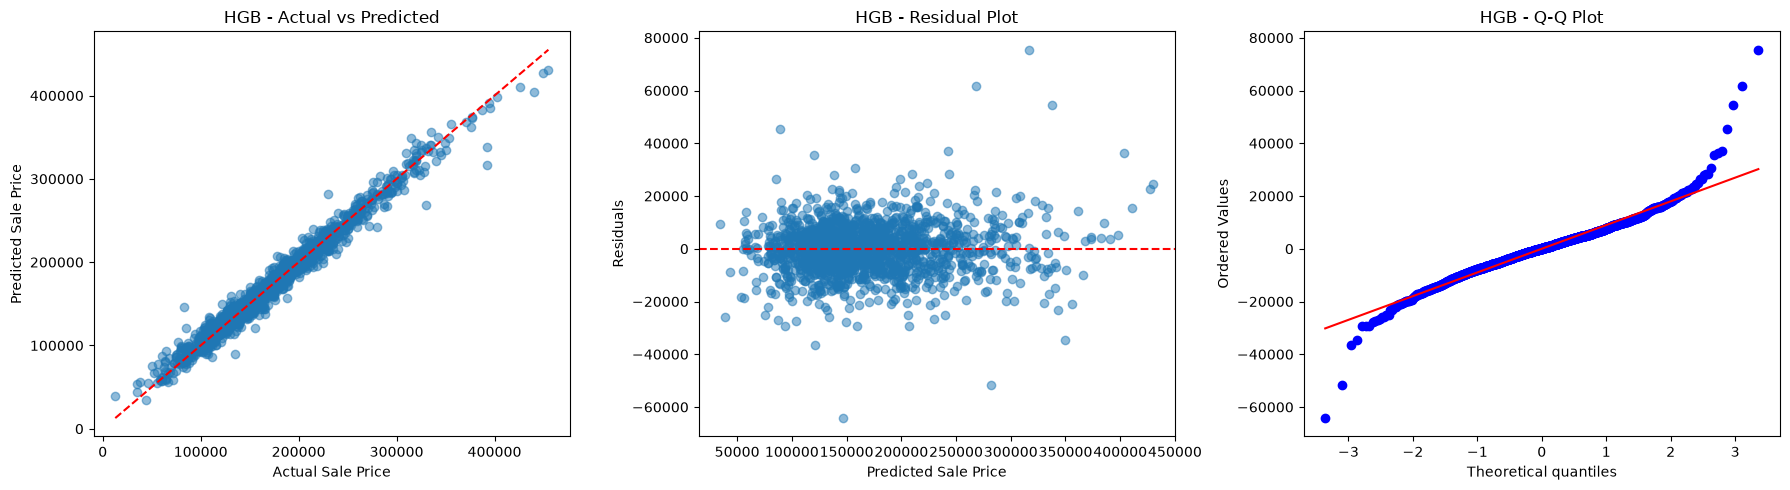

In [1186]:
model = grid_hgb.best_estimator_

X = X_train_scaled
y = y_train
y_pred = model.predict(X)
residuals = y - y_pred

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax[0].scatter(y, y_pred, alpha=0.5)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax[0].plot([min_val, max_val], [min_val, max_val], 'r--')
ax[0].set_title('HGB - Actual vs Predicted')
ax[0].set_xlabel('Actual Sale Price')
ax[0].set_ylabel('Predicted Sale Price')

# Residual Plot
ax[1].scatter(y_pred, residuals, alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('HGB - Residual Plot')
ax[1].set_xlabel('Predicted Sale Price')
ax[1].set_ylabel('Residuals')

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=ax[2])
ax[2].set_title('HGB - Q-Q Plot')

plt.tight_layout()
plt.show()

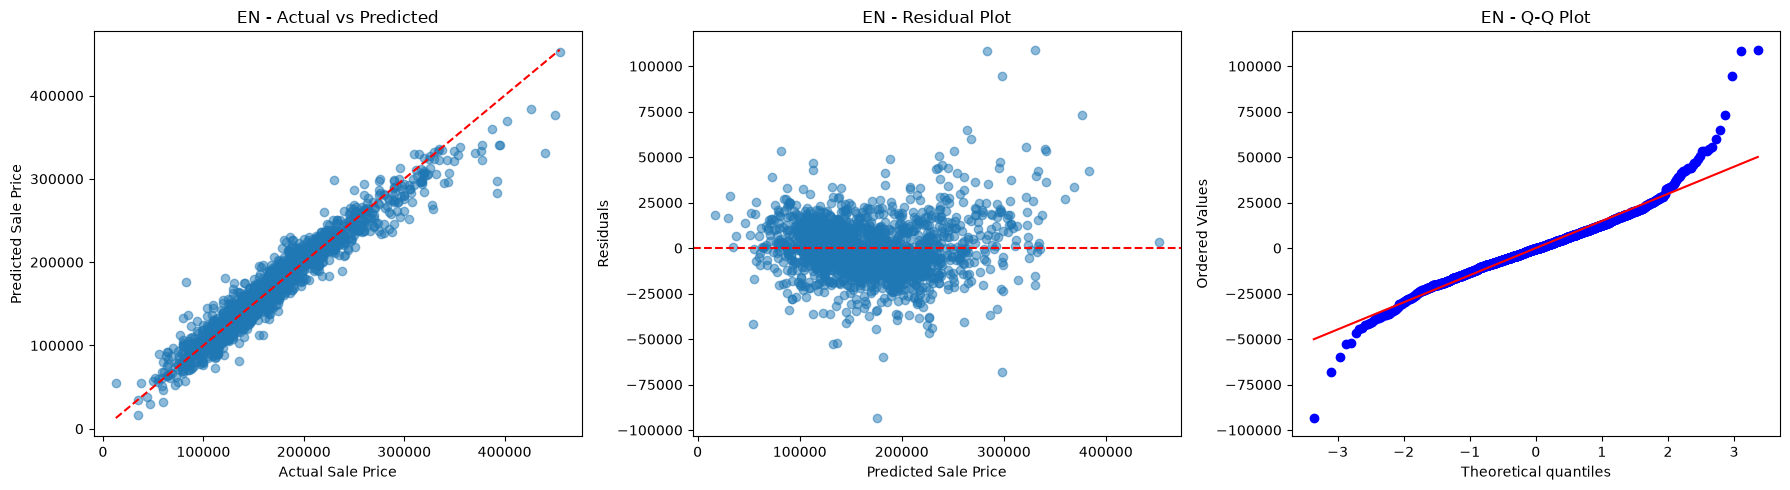

In [1187]:
model = grid_en.best_estimator_

X = X_train_scaled
y = y_train
y_pred = model.predict(X)
residuals = y - y_pred

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax[0].scatter(y, y_pred, alpha=0.5)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax[0].plot([min_val, max_val], [min_val, max_val], 'r--')
ax[0].set_title('EN - Actual vs Predicted')
ax[0].set_xlabel('Actual Sale Price')
ax[0].set_ylabel('Predicted Sale Price')

# Residual Plot
ax[1].scatter(y_pred, residuals, alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('EN - Residual Plot')
ax[1].set_xlabel('Predicted Sale Price')
ax[1].set_ylabel('Residuals')

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=ax[2])
ax[2].set_title('EN - Q-Q Plot')

plt.tight_layout()
plt.show()

------------

# plot for best model without pca

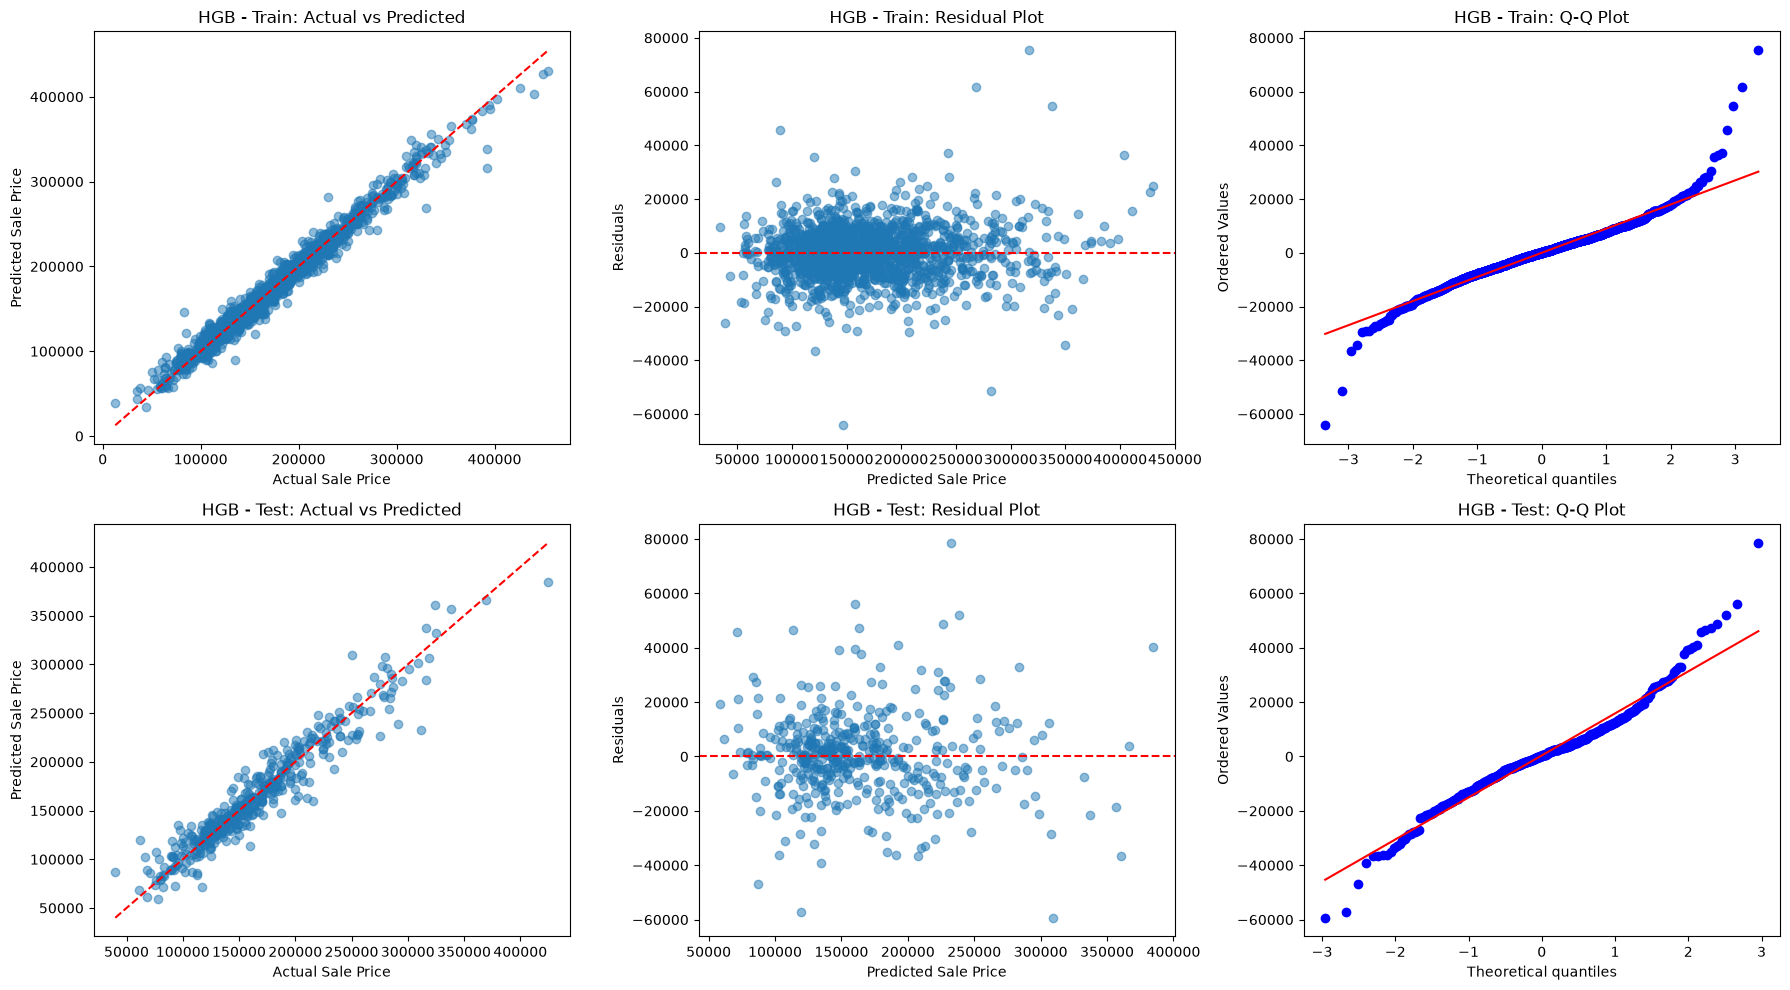

In [1188]:
model = grid_hgb.best_estimator_

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# 1. Actual vs Predicted - Train
ax[0, 0].scatter(y_train, y_train_pred, alpha=0.5)
low = min(y_train.min(), y_train_pred.min())
high = max(y_train.max(), y_train_pred.max())
ax[0, 0].plot([low, high], [low, high], 'r--')
ax[0, 0].set_title('HGB - Train: Actual vs Predicted')
ax[0, 0].set_xlabel('Actual Sale Price')
ax[0, 0].set_ylabel('Predicted Sale Price')

# 2. Residual Plot - Train
ax[0, 1].scatter(y_train_pred, train_residuals, alpha=0.5)
ax[0, 1].axhline(0, color='red', linestyle='--')
ax[0, 1].set_title('HGB - Train: Residual Plot')
ax[0, 1].set_xlabel('Predicted Sale Price')
ax[0, 1].set_ylabel('Residuals')

# 3. Q-Q Plot - Train
stats.probplot(train_residuals, dist='norm', plot=ax[0, 2])
ax[0, 2].set_title('HGB - Train: Q-Q Plot')

# 4. Actual vs Predicted - Test
ax[1, 0].scatter(y_test, y_test_pred, alpha=0.5)
low = min(y_test.min(), y_test_pred.min())
high = max(y_test.max(), y_test_pred.max())
ax[1, 0].plot([low, high], [low, high], 'r--')
ax[1, 0].set_title('HGB - Test: Actual vs Predicted')
ax[1, 0].set_xlabel('Actual Sale Price')
ax[1, 0].set_ylabel('Predicted Sale Price')

# 5. Residual Plot - Test
ax[1, 1].scatter(y_test_pred, test_residuals, alpha=0.5)
ax[1, 1].axhline(0, color='red', linestyle='--')
ax[1, 1].set_title('HGB - Test: Residual Plot')
ax[1, 1].set_xlabel('Predicted Sale Price')
ax[1, 1].set_ylabel('Residuals')

# 6. Q-Q Plot - Test
stats.probplot(test_residuals, dist='norm', plot=ax[1, 2])
ax[1, 2].set_title('HGB - Test: Q-Q Plot')

plt.tight_layout()
plt.show()

## GridSearchCV and Model Performance Comparison

### Hyperparameter Optimization

`GridSearchCV` was used to optimize the hyperparameters of the regression models through cross-validation. The best estimator for each model was selected based on its cross-validation score.

### Evaluation on Training and Test Sets

The best estimators were evaluated on both the training and test sets using the following metrics:

* **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted sale prices.
* **RMSE (Root Mean Squared Error):** Measures prediction error while penalizing larger errors more heavily.
* **R² (Coefficient of Determination):** Measures how well the model explains the variation in sale prices.

The results were collected in `test_results_df` and sorted by **Test RMSE** to facilitate model comparison.

### Visualization

Seaborn was used to create three horizontal bar plots comparing the optimized models based on:

* **Test MAE**
* **Test RMSE**
* **Test R²**

The model names are displayed only on the leftmost plot to improve readability. Numerical values are displayed beside the bars to make the comparison more informative.

### Conclusion

The visual comparison provides an overview of the predictive performance of all optimized regression models on the test set.

Lower MAE and RMSE values indicate smaller prediction errors, while a higher R² indicates better explanatory performance.

The results will be used to identify promising models for further analysis, including residual diagnostics and comparison with the PCA-based modeling approach.


-----------------------------

In [1189]:
test_results_df.to_csv(
    "../results_without_pca.csv",
    index=False
)